In [99]:
import warnings
ignore_warnings = warnings.filterwarnings("ignore")

# 1. Persiapan & Pembersihan Data (Data Preparation)

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

## 1.1. Inisialisasi & Pengumpulan Data

Data di unduh melalui situs https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset 
<br> 
pada tanggal <br>
Sabtu, 28 Maret 2026, 4:16:33 (UTC+7 time)
<br> 
Credit data citation : <br>
Kuzilek J., Hlosta M., Zdrahal Z. Open University Learning Analytics dataset Sci. Data 4:170171 doi: 10.1038/sdata.2017.171 (2017).

In [101]:
# Memuat (Loading) studentInfo 
print("Memuat studentInfo...")
# Code ini melakukan pembacaan (loading) data dari file "studentInfo.csv" menggunakan library pandas.
# Pandas adalah library Python yang digunakan untuk analisis dan manipulasi data.
df_info = pd.read_csv("../data/dirty/studentInfo.csv")
# Variabel df_info akan menyimpan data yang dibaca dari file "studentInfo.csv".
# Data ini akan berbentuk DataFrame, yaitu struktur data yang digunakan untuk menyimpan dan memanipulasi data dalam bentuk tabel.
df_info.info()
# Pesan ini menampilkan ukuran (shape) dari DataFrame df_info.
# Shape adalah tuple yang berisi jumlah baris dan kolom pada DataFrame.


Memuat studentInfo...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [ ]:
# LOAD & AGREGASI (Agregasi) studentVle 
print("\nMemuat & melakukan agregasi studentVle...")

# Inisialisasi variabel
chunksize = 500_000  # Ukuran chunk data yang dibaca dari file "studentVle.csv"
chunk_list = []  # Daftar untuk menyimpan hasil agregasi setiap chunk
total_rows = 0  # Jumlah total baris data sebelum filter
filtered_rows = 0  # Jumlah total baris data setelah filter

# Loop setiap chunk pada file "studentVle.csv"
for i, chunk in enumerate(pd.read_csv("../data/dirty/studentVle.csv", chunksize=chunksize)):
    # Tampilkan informasi chunk saat ini
    print(f"Memproses chunk {i+1} | code_modules: {chunk['code_module'].unique()}")

    # Tambah jumlah total_rows
    total_rows += len(chunk)

    # Filter hanya aktivitas valid (hari 1–28, excludes pre-enrollment & minggu 5)
    chunk = chunk[(chunk['date'] >= 1) & (chunk['date'] <= 27)]
    # Tambah jumlah filtered_rows
    filtered_rows += len(chunk)

    # Tambah kolom week
    chunk["week"] = (chunk["date"] // 7) + 1

    # Agregasi per siswa per minggu
    # Menghitung total_clicks (sum) per id_student, code_module, code_presentation, dan week
    agg = chunk.groupby(
        ["id_student", "code_module", "code_presentation", "week"]
    ).agg(total_clicks=("sum_click", "sum")).reset_index()

    # Tambah ke dalam list chunk_list
    chunk_list.append(agg)

print(f"\nTotal baris sebelum filter : {total_rows}")
print(f"Total baris setelah filter  : {filtered_rows}")

# Concat semua agregasi menjadi DataFrame df_vle
df_vle = pd.concat(chunk_list, ignore_index=True)

# Re-agregasi untuk handle duplikat antar chunk
# Menghitung total_clicks (sum) per id_student, code_module, code_presentation, dan week
df_vle = df_vle.groupby(
    ["id_student", "code_module", "code_presentation", "week"]
).agg(total_clicks=("total_clicks", "sum")).reset_index()

print(f"\nstudentVle_aggregated shape : {df_vle.shape}")
print(f"Rentang week                  : {df_vle['week'].min()} – {df_vle['week'].max()}")
print(f"code_modules ditemukan        : {df_vle['code_module'].unique()}")

# Validasi: pastikan tidak ada week di luar 1–4
invalid_week = df_vle[~df_vle["week"].isin([1, 2, 3, 4])]
print(f"Baris week invalid: {len(invalid_week)}")


Memuat & melakukan agregasi studentVle...
Memproses chunk 1 | code_modules: ['AAA' 'BBB']
Memproses chunk 2 | code_modules: ['BBB']
Memproses chunk 3 | code_modules: ['BBB']
Memproses chunk 4 | code_modules: ['BBB' 'CCC']
Memproses chunk 5 | code_modules: ['CCC']
Memproses chunk 6 | code_modules: ['CCC']
Memproses chunk 7 | code_modules: ['CCC' 'DDD']
Memproses chunk 8 | code_modules: ['DDD']
Memproses chunk 9 | code_modules: ['DDD']
Memproses chunk 10 | code_modules: ['DDD']
Memproses chunk 11 | code_modules: ['DDD' 'EEE']
Memproses chunk 12 | code_modules: ['EEE']
Memproses chunk 13 | code_modules: ['EEE' 'FFF']
Memproses chunk 14 | code_modules: ['FFF']
Memproses chunk 15 | code_modules: ['FFF']
Memproses chunk 16 | code_modules: ['FFF']
Memproses chunk 17 | code_modules: ['FFF']
Memproses chunk 18 | code_modules: ['FFF']
Memproses chunk 19 | code_modules: ['FFF']
Memproses chunk 20 | code_modules: ['FFF']
Memproses chunk 21 | code_modules: ['FFF' 'GGG']
Memproses chunk 22 | code_m

In [103]:
print("\nMenyimpan studentVle_aggregated...")
# Membuat direktori jika belum ada
output_dir = "../data/processed/wrangled"  # Direktori output
os.makedirs(output_dir, exist_ok=True)  # Membuat direktori jika belum ada

# Simpan hasil agregasi ke dalam file "studentVle_aggregated.csv"
df_vle.to_csv("../data/processed/wrangled/studentVle_aggregated.csv", index=False)

# Mendapatkan path absolut dari file script
print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/wrangled/studentVle_aggregated.csv')}")



Menyimpan studentVle_aggregated...

Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\wrangled\studentVle_aggregated.csv


In [104]:
# LOAD studentVle_aggregated (hasil proses sebelumnya)

print("Memuat studentVle_aggregated...")

# Membaca data dari file "studentVle_aggregated.csv" menggunakan pandas
df_vle = pd.read_csv("../data/processed/wrangled/studentVle_aggregated.csv")

# Menampilkan informasi tentang bentuk data (shape) dari DataFrame df_vle
df_vle.info()

Memuat studentVle_aggregated...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_student         92088 non-null  int64 
 1   code_module        92088 non-null  object
 2   code_presentation  92088 non-null  object
 3   week               92088 non-null  int64 
 4   total_clicks       92088 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.5+ MB


In [105]:
# Membaca data dari file "studentInfo.csv" menggunakan pandas dan menyimpannya dalam DataFrame df_info
df_info = pd.read_csv("../data/dirty/studentInfo.csv")

# Menampilkan informasi tentang bentuk data (shape) dari DataFrame df_info
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [106]:
# Membaca data dari file "studentAssessment.csv" menggunakan pandas dan menyimpannya dalam DataFrame df_assessment
df_assessment = pd.read_csv("../data/dirty/studentAssessment.csv")

# Menampilkan informasi tentang bentuk data (shape) dari DataFrame df_assessment
df_assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_assessment   173912 non-null  int64 
 1   id_student      173912 non-null  int64 
 2   date_submitted  173912 non-null  int64 
 3   is_banked       173912 non-null  int64 
 4   score           173912 non-null  object
dtypes: int64(4), object(1)
memory usage: 6.6+ MB


In [107]:
# Membaca data dari file "assessments.csv" menggunakan pandas dan menyimpannya dalam DataFrame df_assessments
df_assessments = pd.read_csv("../data/dirty/assessments.csv")

# Menampilkan informasi tentang bentuk data (shape) dari DataFrame df_assessments
df_assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    object 
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 9.8+ KB


In [108]:
""" 
Menyaring kolom untuk fokus pada data kunci siswa (ID & modul), 
target prediksi (final_result), dan fitur demografi.
Hal ini bertujuan untuk mengurangi penggunaan memori dan menghilangkan noise dari kolom yang tidak dipakai.
"""
df_info = df_info[[
    "id_student", "code_module", "code_presentation",
    "final_result", "highest_education", "disability",
    "gender", "age_band", "region"  # Ditambahkan untuk analisis demografi di EDA
]]

""" 
Mengambil kolom-kolom spesifik dari dataframe 'df_assessment'
dan menyimpan hasilnya kembali ke variabel 'df_assessment' (re-assignment)
Kolom yang diambil adalah:
- 'id_student': ID unik untuk setiap mahasiswa
- 'id_assessment': ID unik untuk setiap jenis penilaian/ujian
- 'date_submitted': Tanggal ketika penilaian tersebut dikumpulkan oleh mahasiswa
- 'score': Nilai yang didapat mahasiswa pada penilaian tersebut
"""
df_assessment = df_assessment[[
    "id_student", "id_assessment",
    "date_submitted", "score"
]]

"""
Mengambil kolom-kolom spesifik dari dataframe 'df_assessments' (perhatikan 's' di akhir)
Kolom yang diambil adalah:
- 'id_assessment': ID unik untuk mengaitkan data dengan dataframe pertama
- 'code_module': Kode identifikasi untuk modul mata kuliah
- 'code_presentation': Kode identifikasi untuk sesi presentasi (jika ada)
- 'assessment_type': Jenis penilaian (misalnya: UAS, Tugas, Kuis)
- 'date': Tanggal batas akhir pengumpulan (deadline)
Setelah mengambil kolom, kita menggunakan fungsi .rename() untuk mengubah nama kolom 'date'
menjadi 'date_deadline' agar lebih jelas bahwa ini adalah tanggal tenggat waktu, bukan tanggal submit.
"""
df_assessments = df_assessments[[
    "id_assessment", "code_module", "code_presentation",
    "assessment_type", "date"  
]].rename(columns={"date": "date_deadline"})

In [109]:
# MERGE (menggabungkan) studentInfo + studentVle_aggregated
"""
Mencetak pesan ke konsol untuk memberikan informasi visual bahwa proses penggabungan data
antara dataframe 'studentInfo' (informasi mahasiswa) dan 'studentVle_aggregated' (data aktivitas VLE)
sedang dimulai. Tanda \n digunakan untuk membuat baris kosong sebelum pesan. 
"""
print("\nMerging studentInfo + studentVle_aggregated...")

"""
Menggabungkan dua dataframe: 'df_info' (sebagai tabel kiri/utama) dan 'df_vle' (sebagai tabel kanan).
Fungsi pd.merge() digunakan untuk menyatukan baris berdasarkan kolom yang memiliki nama sama
atau kolom yang ditentukan secara eksplisit.

Parameter 'on': Menentukan kunci gabungan (key). Baris akan disatukan hanya jika nilai pada ketiga kolom
ini sama di kedua dataframe:
  - "id_student": ID unik mahasiswa
  - "code_module": Kode mata kuliah
  - "code_presentation": Kode sesi presentasi (untuk membedakan tahun/periode jika ada)

Parameter 'how="left"': Menggunakan jenis join "Left Join".
yaitu metode gabungan dimana Semua baris dari dataframe kiri ('df_info') akan dipertahankan.
Jika ada kecocokan di dataframe kanan ('df_vle'), data dari kanan akan digabung.
Jika TIDAK ada kecocokan di kanan, kolom-kolom dari 'df_vle' akan terisi dengan nilai NaN (kosong).
Ini berguna agar kita tidak kehilangan data mahasiswa hanya karena mereka belum punya aktivitas di VLE.
"""
df_master = pd.merge(
    df_info,
    df_vle,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

"""
Mencetak bentuk (shape) dari dataframe hasil gabungan.
df_master..info() Mencetak ringkasan detail dataframe (tipe data, jumlah data tidak kosong, memori)
f-string digunakan untuk menyisipkan nilai shape tersebut ke dalam pesan teks.
Ini membantu memverifikasi apakah jumlah baris tetap sama (karena left join dari kiri)
dan berapa banyak kolom baru yang berhasil ditambahkan dari data VLE.
"""
df_master.info()


Merging studentInfo + studentVle_aggregated...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 8.1+ MB


In [110]:
'''
# Menyiapkan data untuk assessment pertanyaan bisnis 2
# Join studentAssessment + assessments untuk mendapatkan data deadline
# Mencetak pesan ke konsol untuk menandakan dimulainya proses penggabungan tabel penilaian
'''
print("\nJoining assessment tables...")

'''
# Menggabungkan dataframe 'df_assessment' (data submit & nilai siswa) 
# dengan dataframe 'df_assessments' (detail penilaian seperti deadline & jenis ujian).
# Kunci penggabungan menggunakan kolom "id_assessment" yang ada di kedua tabel.
# Menggunakan 'how="left"' untuk memastikan semua data submit siswa dipertahankan,
# dan data deadline diambil dari tabel referensi jika ada kecocokan.
'''
df_assessment_full = pd.merge(
    df_assessment,
    df_assessments,
    on="id_assessment",
    how="left"
)

'''
# Mengkonversi kolom "date_submitted" menjadi tipe data numerik.
# Fungsi pd.to_numeric() akan mengubah nilai yang bisa diubah menjadi angka.
# Parameter errors="coerce" akan mengubah nilai yang TIDAK bisa diubah (seperti teks aneh atau kosong) 
# menjadi NaN (Not a Number) agar tidak merusak perhitungan nanti.
'''
df_assessment_full["date_submitted"] = pd.to_numeric(
    df_assessment_full["date_submitted"], errors="coerce"
)

# Mengkonversi kolom "date_deadline" menjadi tipe data numerik dengan cara yang sama.
# Ini memastikan perhitungan selisih hari bisa dilakukan karena kedua kolom sekarang bertipe angka.
df_assessment_full["date_deadline"] = pd.to_numeric(
    df_assessment_full["date_deadline"], errors="coerce"
)

'''
# Membersihkan data dengan melakukan filtering (pemotongan).
# Hanya baris yang nilai "date_deadline"-nya <= 28 yang dipertahankan.
# Catatan: Logika ini mengasumsikan bahwa data tanggal disimpan dalam format numerik tertentu 
# (misalnya hari ke-X dalam bulan, atau format angka spesifik lain) di mana cutoff-nya adalah 28.
# Baris dengan deadline > 28 atau NaN akan dibuang.
'''
df_assessment_full = df_assessment_full[
    df_assessment_full["date_deadline"] <= 28
]

'''
# Menghitung selisih hari antara tanggal submit dan tanggal deadline.
# Rumus: date_submitted - date_deadline
# Hasil perhitungan (days_diff):
#   - Jika nilai NEGATIF (< 0): Mahasiswa submit SEBELUM deadline (Tepat Waktu / Cepat).
#   - Jika nilai POSITIF (> 0): Mahasiswa submit SETELAH deadline (Terlambat).
#   - Jika nilai 0: Submit tepat di hari deadline.
'''
df_assessment_full["days_diff"] = (
    df_assessment_full["date_submitted"] - df_assessment_full["date_deadline"]
)

'''
# Tahap ini bertujuan untuk mengambil HANYA SATU penilaian pertama (tercepat/paling awal) 
# untuk setiap kombinasi unik: Siswa + Modul + Sesi Presentasi.
# Langkah-langkahnya:
# 1. .sort_values("date_deadline"): Mengurutkan seluruh data berdasarkan deadline dari yang paling awal.
#    (Catatan: Pengurutan berdasarkan deadline di sini mungkin untuk memastikan konsistensi jika ada 
#     multiple entries, meskipun logika 'pertama' biasanya berdasarkan tanggal submit).
# 2. .groupby([...]): Mengelompokkan data berdasarkan ID Siswa, Kode Modul, dan Kode Presentasi.
# 3. .first(): Mengambil baris PERTAMA dari setiap kelompok yang sudah diurutkan.
#              Ini efektif mengambil penilaian dengan deadline tertua atau submit pertama (tergantung urutan).
# 4. .reset_index(): Mengembalikan kolom grup (id_student, dll) menjadi kolom biasa agar tidak jadi index.
# 5. [...] : Memilih hanya kolom-kolom yang relevan untuk hasil akhir:
#            ID Siswa, Kode Modul, Kode Presentasi, Selisih Hari (days_diff), dan Skor (score).
'''
df_assessment_first = (
    df_assessment_full
    .sort_values("date_deadline")
    .groupby(["id_student", "code_module", "code_presentation"])
    .first()
    .reset_index()
)[["id_student", "code_module", "code_presentation", "days_diff", "score"]]

'''
# Mencetak ringkasan detail dataframe (tipe data, jumlah data tidak kosong, memori) dari dataframe hasil akhir yang sudah difilter 
# (hanya satu penilaian pertama per siswa per modul).
# Ini berguna untuk memastikan jumlah siswa yang direpresentasikan sudah benar.
'''
df_assessment_first.info()


Joining assessment tables...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21099 entries, 0 to 21098
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         21099 non-null  int64  
 1   code_module        21099 non-null  object 
 2   code_presentation  21099 non-null  object 
 3   days_diff          21099 non-null  float64
 4   score              21099 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 824.3+ KB


In [111]:
# menggabungkan data (MERGE) df_master dengan df_assessment_first

# Mencetak pesan ke konsol untuk menandakan dimulainya proses penggabungan terakhir
# dengan data penilaian yang sudah disiapkan di STEP 5.
print("\nMerging with assessment data...")

'''
# Menggabungkan dataframe utama 'df_master' (yang berisi data mahasiswa & aktivitas VLE)
# dengan dataframe 'df_assessment_first' (yang berisi data satu penilaian pertama per siswa).
#
# Parameter 'on': Menentukan kunci gabungan berdasarkan tiga kolom unik:
#   - "id_student": ID Mahasiswa
#   - "code_module": Kode Mata Kuliah
#   - "code_presentation": Kode Sesi Presentasi
#   Gabungan ini memastikan data nilai dan keterlambatan (days_diff) masuk ke baris yang tepat sesuai identitas siswa dan modul.
#
# Parameter 'how="left"': Menggunakan Left Join.
#   - Semua baris dari 'df_master' (kiri) dipertahankan.
#   - Jika ada kecocokan di 'df_assessment_first' (kanan), data nilai dan days_diff akan diisi.
#   - Jika TIDAK ada data penilaian untuk siswa tersebut (misalnya mereka tidak ikut ujian), 
#     kolom 'score' dan 'days_diff' akan terisi NaN (kosong). Ini penting agar siswa tetap tercatat dalam analisis.
'''
df_master = pd.merge(
    df_master,
    df_assessment_first,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

# Menggunakan .info() untuk menampilkan ringkasan detail dataframe (jumlah baris, kolom, tipe data, non-null count, memori)
df_master.info()


Merging with assessment data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 9.6+ MB


## 1.2. Analisis Kualitas Data (Data Assessment)

In [112]:
'''
# Mengambil daftar semua nama kolom dalam dataframe 'df_master'
# .tolist() mengubah daftar kolom tersebut menjadi format list Python biasa
# Ini berguna untuk memastikan semua fitur yang diharapkan (seperti 'score', 'days_diff', dll) telah ada
'''
print(df_master.columns.tolist())


# Menggunakan .info() untuk menampilkan ringkasan detail dataframe (jumlah baris, kolom, tipe data, non-null count, memori)
print(f"\nRingkasan Detail Dataframe:")
df_master.info()

'''
# Mencetak jumlah nilai yang hilang (missing values/NaN) untuk setiap kolom
# .isnull() mengembalikan DataFrame boolean (True jika kosong)
# .sum() menghitung jumlah True (nilai kosong) per kolom
# Ini krusial untuk melihat data mana yang banyak kosongnya sebelum analisis lebih lanjut
'''
print(f"\nJumlah Nilai Kosong (Missing Values) per Kolom:\n{df_master.isnull().sum()}")

# Mencetak 5 baris pertama dari dataframe sebagai sampel visual
# .head() menampilkan baris awal untuk memeriksa format data, isi teks, atau anomali yang terlihat
print(f"\nSampel 5 Baris Pertama Data:\n{df_master.head()}")

['id_student', 'code_module', 'code_presentation', 'final_result', 'highest_education', 'disability', 'gender', 'age_band', 'region', 'week', 'total_clicks', 'days_diff', 'score']

Ringkasan Detail Dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score

In [113]:
# Menyimpan data
'''
Membuat salinan (copy) dari dataframe utama 'df_master' 
dan menyimpannya ke variabel baru bernama 'df_master_weekly'.
Menggunakan .copy() sangat penting untuk menghindari peringatan "SettingWithCopyWarning"
di Pandas jika nanti kita ingin memodifikasi data di 'df_master_weekly' tanpa mengubah 'df_master' asli.
Variabel ini disiapkan untuk analisis EDA (Exploratory Data Analysis) dan Visualisasi mingguan.
Menyimpan dataframe 'df_master_weekly' ke file CSV dengan nama "df_master_weekly.csv".
Parameter index=False sangat penting agar baris angka (index) dari pandas TIDAK ikut tersimpan
ke dalam file CSV, sehingga file lebih bersih dan mudah dibaca oleh aplikasi lain (Excel, dll).
Membuat direktori jika belum ada
'''
df_master_weekly = df_master.copy()
print("\nMenyimpan data df_master_weekly...")
output_dir = "../data/processed/wrangled/"  # Direktori output
os.makedirs(output_dir, exist_ok=True)  # Membuat direktori jika belum ada
df_master_weekly.to_csv("../data/processed/wrangled/df_master_weekly.csv", index=False)
# Mencetak pesan konfirmasi bahwa penyimpanan berhasil.
print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/wrangled/df_master_weekly.csv')}")


Menyimpan data df_master_weekly...



Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\wrangled\df_master_weekly.csv


In [114]:
# melihat ringkasan detail dataframe yang baru saja disimpan.
# Info ini berguna untuk memastikan data sebelum disimpan memiliki tipe data dan jumlah baris yang benar.
df_master_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 9.6+ MB


In [115]:
'''
MISSING VALUES
Menghitung jumlah nilai yang hilang (NaN) untuk setiap kolom dalam dataframe 'df_master_weekly'.
.isnull() menghasilkan DataFrame boolean (True untuk nilai kosong), lalu .sum() menghitung jumlah True per kolom.
'''
missing = df_master_weekly.isnull().sum()

'''
# Menghitung persentase nilai yang hilang untuk setiap kolom.
# Rumusnya: (Jumlah nilai kosong / Total jumlah baris) * 100.
# .round(2) membulatkan hasil persentase menjadi 2 angka di belakang koma agar lebih rapi.
'''
missing_pct = (missing / len(df_master_weekly) * 100).round(2)

'''
# Membuat dataframe baru bernama 'missing_df' untuk menampilkan laporan nilai kosong secara terstruktur.
# Dataframe ini memiliki dua kolom:
#   - "missing_count": Jumlah absolut nilai kosong.
#   - "missing_pct": Persentase nilai kosong.
'''
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

'''
# Melakukan filtering dan pengurutan pada dataframe laporan tersebut:
#   - .query("missing_count > 0"): Hanya menampilkan kolom-kolom yang memiliki nilai kosong (jumlah > 0).
#     Ini menyembunyikan kolom yang 100% lengkap agar laporan lebih fokus pada masalah.
#   - .sort_values("missing_pct", ascending=False): Mengurutkan hasil dari persentase nilai kosong terbesar ke terkecil.
#     Kolom dengan data paling "berantakan" akan muncul di paling atas.
'''
missing_df = missing_df.query("missing_count > 0").sort_values("missing_pct", ascending=False)

# Menampilkan tabel laporan nilai kosong yang sudah difilter dan diurutkan ke konsol.
# Output ini membantu Anda dengan cepat mengidentifikasi fitur mana yang membutuhkan penanganan khusus (imputasi atau penghapusan).
print(missing_df)

              missing_count  missing_pct
score                 23440        24.19
days_diff             23440        24.19
total_clicks           4798         4.95
week                   4798         4.95


In [116]:
# cek duplikat
'''
Menghitung jumlah baris duplikat dalam dataframe 'df_master_weekly'.
.duplicated() mengembalikan Series boolean: True untuk baris yang merupakan duplikat 
dari baris sebelumnya, dan False untuk baris unik (baris pertama yang muncul).
.sum() menghitung berapa banyak nilai True (artinya jumlah baris duplikat).
'''
dup_count = df_master_weekly.duplicated().sum()

print(f"Total baris duplikat terdeteksi: {dup_count}")

# Menampilkan ringkasan detail dataframe untuk memastikan integritas data 
# sebelum melanjutkan ke penghapusan duplikat jika diperlukan.
print("\n--- Info Dataframe Sebelum Pembersihan Duplikat ---")
df_master_weekly.info()

Total baris duplikat terdeteksi: 0

--- Info Dataframe Sebelum Pembersihan Duplikat ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 9.6+ MB


In [117]:
'''
 Menghitung jumlah baris yang dianggap duplikat HANYA berdasarkan kombinasi kolom kunci tertentu:
  - "id_student": ID Mahasiswa
  - "code_module": Kode Mata Kuliah
  - "code_presentation": Kode Sesi Presentasi
  - "week": Nomor Minggu

Logika .duplicated([...]):
  Baris dianggap duplikat jika semua nilai pada keempat kolom di atas sama dengan baris sebelumnya.
  Ini penting karena dalam data mingguan, satu siswa di satu modul seharusnya hanya punya SATU baris per minggu.
  Jika ada lebih dari satu, itu berarti ada data ganda yang perlu dibersihkan.
'''
key_dup = df_master_weekly.duplicated(
    ["id_student", "code_module", "code_presentation", "week"]
).sum()

# Mencetak hasil hitungan duplikasi berdasarkan kunci tersebut.
# Jika output > 0, berarti ada data yang perlu dihapus (misalnya menggunakan drop_duplicates).
print(f"Total baris duplikat berdasarkan kunci (Student, Module, Presentation, Week): {key_dup}")

# Menampilkan ringkasan detail dataframe sesuai permintaan (mengganti pola .shape dengan .info()).
# Ini membantu melihat tipe data dan jumlah data non-null sebelum atau sesudah penanganan duplikat.
print("\n--- Info Dataframe (Cek Duplikat Kunci) ---")
df_master_weekly.info()

Total baris duplikat berdasarkan kunci (Student, Module, Presentation, Week): 0

--- Info Dataframe (Cek Duplikat Kunci) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory

In [118]:
# DETEKSI OUTLIER DENGAN METODE IQR (INTERQUARTILE RANGE)

# Memilih hanya kolom-kolom bertipe numerik (integer atau float) dari dataframe.
# Kolom kategorikal atau tanggal akan diabaikan karena outlier biasanya dihitung pada data angka.
num_cols = df_master_weekly.select_dtypes(include="number").columns

# Membuat daftar kosong untuk menyimpan ringkasan statistik setiap kolom.
outlier_summary = []

# Melakukan iterasi (perulangan) pada setiap kolom numerik yang ditemukan.
for col in num_cols:
    # Menghitung Quartil 1 (Q1): Nilai di bawah yang 25% data berada di bawahnya.
    Q1 = df_master_weekly[col].quantile(0.25)
    
    # Menghitung Quartil 3 (Q3): Nilai di bawah yang 75% data berada di bawahnya (atau 25% data di atasnya).
    Q3 = df_master_weekly[col].quantile(0.75)
    
    # Menghitung Interquartile Range (IQR): Jarak antara Q3 dan Q1.
    # Ini mewakili sebaran 50% data tengah yang paling umum.
    IQR = Q3 - Q1
    
    # Menentukan batas bawah (lower bound) untuk mendeteksi outlier kecil.
    # Nilai di bawah batas ini dianggap outlier (terlalu kecil/aneh).
    lower = Q1 - 1.5 * IQR
    
    # Menentukan batas atas (upper bound) untuk mendeteksi outlier besar.
    # Nilai di atas batas ini dianggap outlier (terlalu besar/aneh).
    upper = Q3 + 1.5 * IQR

    '''
    # Menghitung jumlah outlier:
    # Mengecek kondisi di mana nilai kolom < lower ATAU > upper.
    # .sum() menghitung berapa banyak True (baris yang memenuhi kondisi outlier).
    '''
    outlier_count = ((df_master_weekly[col] < lower) | (df_master_weekly[col] > upper)).sum()
    
    # Menyimpan hasil perhitungan ke dalam dictionary untuk setiap kolom.
    outlier_summary.append({
        "column": col,              # Nama kolom
        "Q1": round(Q1, 2),         # Nilai Q1 (dibulatkan 2 desimal)
        "Q3": round(Q3, 2),         # Nilai Q3
        "IQR": round(IQR, 2),       # Selisih IQR
        "lower_bound": round(lower, 2), # Batas bawah aman
        "upper_bound": round(upper, 2), # Batas atas aman
        "outlier_count": outlier_count, # Jumlah data aneh
        "outlier_pct": round(outlier_count / len(df_master_weekly) * 100, 2) # Persentase data aneh
    })

# Membuat DataFrame dari ringkasan outlier yang sudah dikumpulkan.
# Mengurutkan berdasarkan jumlah outlier tertinggi (ascending=False) agar kolom paling bermasalah ada di atas.
outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)

# Menampilkan tabel ringkasan outlier ke konsol.
print("\n--- Ringkasan Deteksi Outlier (Metode IQR) ---")
print(outlier_df)




--- Ringkasan Deteksi Outlier (Metode IQR) ---
         column        Q1        Q3       IQR  lower_bound  upper_bound  \
0    id_student  506144.0  644069.0  137925.0     299256.5     850956.5   
3     days_diff      -2.0       2.0       4.0         -8.0          8.0   
2  total_clicks      17.0     109.0      92.0       -121.0        247.0   
1          week       2.0       3.0       1.0          0.5          4.5   

   outlier_count  outlier_pct  
0          19584        20.21  
3           6014         6.21  
2           5719         5.90  
1              0         0.00  


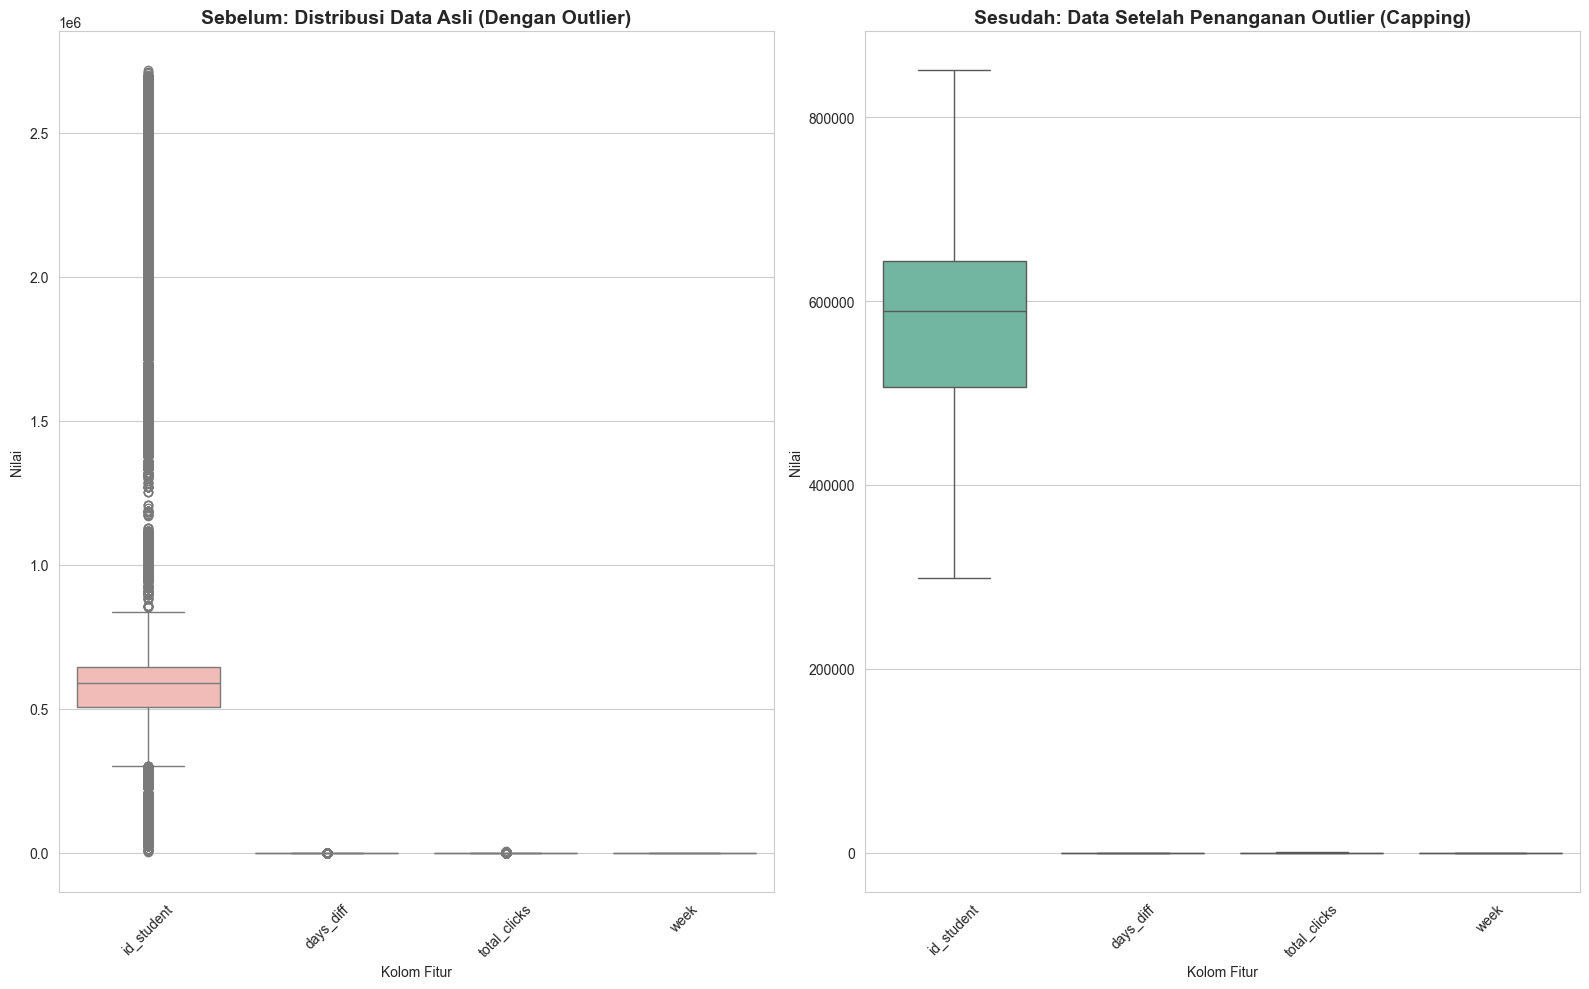

In [119]:
# VISUALISASI OUTLIER: SEBELUM DAN SESUDAH PENANGANAN

# Mengatur ukuran canvas plot agar gambar jelas
plt.figure(figsize=(16, 10))

'''
# 1. VISUALISASI SEBELUM (Original Data)
# Kita akan membuat boxplot untuk beberapa kolom penting yang memiliki outlier banyak.
# Mengambil 5 kolom teratas yang paling banyak outliernya untuk ditampilkan.
'''
top_outlier_cols = outlier_df.head(5)["column"].tolist()

plt.subplot(1, 2, 1) # Membagi area plot menjadi 1 baris, 2 kolom, posisi 1 (kiri)
sns.boxplot(data=df_master_weekly[top_outlier_cols], palette="Pastel1")
plt.title("Sebelum: Distribusi Data Asli (Dengan Outlier)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.xlabel("Kolom Fitur")

'''
# 2. PENANGANAN OUTLIER (Capping / Clipping)
# Alih-alih menghapus baris (yang bisa mengurangi jumlah data siswa), 
# kita "memotong" (clip) nilai outlier agar masuk ke batas aman.
# Ini disebut metode 'Capping' atau 'Winsorization'.
'''
df_master_weekly_clean = df_master_weekly.copy()

for col in top_outlier_cols:
    # Ambil kembali nilai Q1, Q3, IQR, lower, upper untuk kolom ini
    Q1 = df_master_weekly[col].quantile(0.25)
    Q3 = df_master_weekly[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    '''
    # Fungsi .clip(lower, upper) akan:
    # - Mengubah semua nilai di bawah 'lower' menjadi 'lower'.
    # - Mengubah semua nilai di atas 'upper' menjadi 'upper'.
    # - Mengubah semua yang di antaranya tetap sama.
    '''
    df_master_weekly_clean[col] = df_master_weekly[col].clip(lower=lower, upper=upper)

# 3. VISUALISASI SESUDAH (Cleaned Data)
plt.subplot(1, 2, 2) # Posisi 2 (kanan)
sns.boxplot(data=df_master_weekly_clean[top_outlier_cols], palette="Set2")
plt.title("Sesudah: Data Setelah Penanganan Outlier (Capping)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.xlabel("Kolom Fitur")

plt.tight_layout() # Mengatur layout agar tidak terpotong
plt.show()

## 1.3. Pembersihan & Rekayasa Fitur Awal

In [120]:
# BASIC INFO (Data Bersih)

df_master_weekly_clean.info()

# Mencetak sampel data bersih untuk memastikan perubahan terlihat
print(f"\nSample 5 Baris Data Bersih:\n{df_master_weekly_clean.head()}")

# Menampilkan statistik deskriptif singkat untuk membandingkan sebelum/sesudah (opsional tapi berguna)
print("\nStatistik Deskriptif Data Bersih (Mean, Std, Min, Max):")
print(df_master_weekly_clean[top_outlier_cols].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  float64
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(4), object(9)
memory usage: 9.6+ MB

Sample 5 Baris Data Bersih:
   id_student code_module code_presentation final_result highest_education  \
0    299256.

In [121]:
# LOAD DATA
# Mencetak pesan ke konsol untuk menandakan dimulainya proses pemuatan data.
print("Loading data...")

# Membaca file CSV dari lokasi spesifik dan menyimpannya ke dalam DataFrame pandas bernama 'df'.
df = pd.read_csv("../data/processed/wrangled/df_master_weekly.csv")
print("\n--- Informasi Awal Dataframe ---")
df.info()

Loading data...

--- Informasi Awal Dataframe ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  float64
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73446 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 9.6+ MB


In [122]:
# MEMPERBAIKI TIPENYA (DATA TYPE)

# Mencetak pesan ke konsol untuk menandakan dimulainya proses penyesuaian tipe data.
print("\nFixing data types...")

'''
1. Mengubah tipe kolom 'week' menjadi Integer (tipe data numerik bulat).
   - Karena 'week' adalah minggu ke-1, ke-2, dst, tipe yang paling sesuai adalah integer.
   - Penggunaan 'Int64' (dengan '64' besar) memastikan tipe data yang mendukung angka besar dan memungkinkan nilai NaN.
   - Jika ada nilai yang tidak bisa diubah (misalnya teks), akan diubah menjadi NaN.
'''
print("...")
df["week"] = df["week"].astype("Int64")

'''
2. Mengubah tipe kolom 'score' menjadi numerik (angka).
   - Digunakan fungsi pd.to_numeric() karena kolom 'score' mungkin awalnya dalam bentuk string.
   - Parameter errors="coerce" sangat penting: Jika ada nilai yang tidak bisa diubah menjadi angka (seperti 'abc', 'N/A'), maka akan diubah menjadi NaN.
   - Tanpa 'errors="coerce"', akan terjadi error dan proses akan berhenti.
'''
print("...")
df["score"] = pd.to_numeric(df["score"], errors="coerce")

'''
# 3. Mengubah tipe kolom 'days_diff' menjadi numerik.
#    - Kolom ini berisi selisih hari (dalam format angka) antara submit dan deadline.
#    - Seperti di atas, harus diubah dari string ke angka.
#    - Jika ada data yang tidak valid (misalnya 'invalid', 'unknown'), akan diubah menjadi NaN.
'''
print("...")
df["days_diff"] = pd.to_numeric(df["days_diff"], errors="coerce")

# Mencetak pesan konfirmasi bahwa proses perbaikan tipe data telah selesai.
print("done")

print("\n--- Informasi Data Setelah Perbaikan Tipe ---")
df.info() # melihat ringkasan detail data setelah perbaikan tipe.


Fixing data types...
...
...


...
done

--- Informasi Data Setelah Perbaikan Tipe ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96886 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         96886 non-null  int64  
 1   code_module        96886 non-null  object 
 2   code_presentation  96886 non-null  object 
 3   final_result       96886 non-null  object 
 4   highest_education  96886 non-null  object 
 5   disability         96886 non-null  object 
 6   gender             96886 non-null  object 
 7   age_band           96886 non-null  object 
 8   region             96886 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  float64
 11  days_diff          73446 non-null  float64
 12  score              73381 non-null  float64
dtypes: Int64(1), float64(3), int64(1), object(8)
memory usage: 9.7+ MB


In [123]:
# MENANGANI NILAI YANG HILANG (MISSING VALUES)

# Mencetak pesan ke konsol untuk menandai dimulainya proses pembersihan data yang hilang.
print("\nHandling missing values...")

'''
1. Menangani kolom 'total_clicks' (Total Klik Aktivitas VLE)
   - .fillna(0): Mengisi semua nilai kosong (NaN) dengan angka 0.
     Logika: Jika data klik tidak ada, diasumsikan siswa tidak melakukan aktivitas sama sekali (0 klik), bukan data hilang.
   - .astype(int): Mengubah tipe data kolom tersebut menjadi integer (bilangan bulat) setelah diisi.
     Ini memastikan kolom ini konsisten karena jumlah klik pasti bilangan bulat.
'''
df["total_clicks"] = df["total_clicks"].fillna(0).astype(int)

'''
2. Menangani kolom 'week' (Minggu)
   - Menghitung jumlah nilai kosong pada kolom 'week' sebelum dilakukan penghapusan.
     Ini berguna untuk melacak berapa banyak data yang akan dibuang.
'''
missing_week_before = df["week"].isnull().sum()
print(f"Jumlah data dengan minggu kosong (sebelum drop): {missing_week_before}")

'''
#    - Menghapus baris yang memiliki nilai kosong (NaN) pada kolom 'week'.
#      Parameter subset=["week"] memastikan hanya baris dengan 'week' kosong yang dihapus,
#      sedangkan baris dengan kolom lain kosong tetap dipertahankan (kecuali diisi sebelumnya).
#      Logika: Data tanpa informasi minggu tidak bisa digunakan untuk analisis mingguan, jadi harus dibuang.
'''
df = df.dropna(subset=["week"])

'''
# Mengubah kode sesuai permintaan Anda:
# Mengganti print dengan format Shape menjadi pemanggilan langsung .info()
# untuk melihat ringkasan data setelah penghapusan baris kosong.
'''
print("\n--- Informasi Data Setelah Menghapus 'week' Kosong ---")
df.info()

# (Opsional) Jika Anda ingin tetap menampilkan pesan jumlah baris yang tersisa secara ringkas:
# print(f"Total baris tersisa: {df.shape}")


Handling missing values...
Jumlah data dengan minggu kosong (sebelum drop): 4798

--- Informasi Data Setelah Menghapus 'week' Kosong ---
<class 'pandas.core.frame.DataFrame'>
Index: 92088 entries, 0 to 96885
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
dtypes: Int64(1), float64(2), int64(2)

In [124]:
# VALIDASI NILAI LOGIS

# Mencetak pesan ke konsol untuk menandai dimulainya proses validasi rentang nilai.
print("\nValidating ranges...")

'''
--- Validasi 1: total_clicks (Total Klik) ---
Menghitung jumlah baris di mana nilai 'total_clicks' kurang dari 0.
Logika: Jumlah klik tidak mungkin negatif. Jika ada, itu adalah kesalahan data.
'''
invalid_clicks = (df["total_clicks"] < 0).sum()
print(f"Jumlah klik negatif terdeteksi: {invalid_clicks}")

# Jika ditemukan nilai negatif:
if invalid_clicks > 0:
    '''
    Menggunakan .clip(lower=0) untuk memotong nilai negatif menjadi 0.
    Nilai di bawah 0 diubah menjadi 0, nilai di atas 0 tetap sama.
    Ini lebih aman daripada menghapus baris karena kita tetap mempertahankan data siswa tersebut.
    '''
    df["total_clicks"] = df["total_clicks"].clip(lower=0)
    print("Nilai klik negatif telah diperbaiki (dipotong) menjadi 0.")

'''
--- Validasi 2: week (Minggu) ---
Mengidentifikasi baris yang memiliki nilai 'week' yang TIDAK ada dalam daftar [1, 2, 3, 4].
Logika: Data berasal dari perhitungan date // 7, sehingga seharusnya hanya berisi minggu 1, 2, 3, atau 4.
~df["week"].isin([1, 2, 3, 4]) berarti "TIDAK dalam daftar [1,2,3,4]".
& df["week"].notnull() memastikan kita hanya mengecek baris yang memiliki nilai (bukan NaN).
'''
invalid_week = df[~df["week"].isin([1, 2, 3, 4]) & df["week"].notnull()]

# Mencetak jumlah baris dengan nilai minggu yang tidak valid (misalnya 0, 5, 10, dll).
print(f"Jumlah baris dengan nilai minggu tidak valid (bukan 1-4): {len(invalid_week)}")
'''
Jika len(invalid_week) > 0, Anda mungkin ingin menangani data ini (misalnya di-drop atau diperbaiki).
Contoh penanganan (opsional):
df = df[df["week"].isin([1, 2, 3, 4])] 
'''

'''
--- Validasi 3: score (Nilai) ---
Menghitung jumlah baris di mana nilai 'score' kurang dari 0 ATAU lebih dari 100.
Logika: Nilai ujian biasanya dalam skala 0 hingga 100.
Catatan: Perbandingan dengan NaN akan menghasilkan False, jadi baris dengan nilai NaN otomatis diabaikan.
'''
invalid_score = ((df["score"] < 0) | (df["score"] > 100)).sum()
print(f"Jumlah baris dengan nilai skor tidak valid (<0 atau >100): {invalid_score}")


Validating ranges...
Jumlah klik negatif terdeteksi: 0
Jumlah baris dengan nilai minggu tidak valid (bukan 1-4): 0
Jumlah baris dengan nilai skor tidak valid (<0 atau >100): 0


In [125]:
# FEATURE ENGINEERING (Membuat Fitur Baru)

# Mencetak pesan ke konsol untuk menandai dimulainya proses pembuatan fitur baru.
print("\nCreating new features...")

'''
--- Fitur 1: Status Pengumpulan (is_submitted) ---
Membuat kolom baru 'is_submitted' yang bernilai 1 (True) jika siswa telah submit (memiliki nilai score),
dan 0 (False) jika belum submit (score masih NaN/kosong).
.notnull() menghasilkan True jika ada nilai, False jika NaN.
.astype(int) mengubah True menjadi 1 dan False menjadi 0.
Ini penting untuk membedakan siswa yang aktif submit dengan yang tidak.
'''
df["is_submitted"] = df["score"].notnull().astype(int)

'''
--- Fitur 2: Keterlambatan (is_late) ---
Membuat kolom baru 'is_late' yang bernilai 1 jika siswa submit terlambat, dan 0 jika tidak.
Kondisi harus terpenuhi:
  1. days_diff > 0: Selisih hari positif berarti submit SETELAH deadline (terlambat).
  2. days_diff.notnull(): Memastikan nilai days_diff ada (bukan NaN, artinya siswa memang submit).
Hasil boolean digabungkan dengan '&' (AND), lalu diubah menjadi integer (1 atau 0).
'''
df["is_late"] = ((df["days_diff"] > 0) & (df["days_diff"].notnull())).astype(int)

# --- Fitur 3: Aktivitas Tinggi (is_high_activity) ---
# Membuat indikator untuk siswa dengan aktivitas belajar yang sangat tinggi (outlier ke atas).
# Menghitung batas atas (upper_bound) menggunakan metode IQR (Interquartile Range) pada kolom 'total_clicks'.
Q1 = df["total_clicks"].quantile(0.25)       # Kuartil 1 (25%)
Q3 = df["total_clicks"].quantile(0.75)       # Kuartil 3 (75%)
IQR = Q3 - Q1                                # Jarak antar kuartil
upper_bound = Q3 + 1.5 * IQR                 # Batas atas normal (outlier jika di atas ini)

# Jika total klik siswa melebihi batas atas, beri label 1 (Aktivitas Tinggi), selain itu 0.
df["is_high_activity"] = (df["total_clicks"] > upper_bound).astype(int)

'''
# --- Fitur 4: Target Machine Learning (risk_label) ---
# Membuat kolom target 'risk_label' untuk klasifikasi risiko kegagalan.
# Menggunakan .map() untuk mengubah label teks 'final_result' menjadi angka biner:
#   - "Pass"      -> 0 (Aman/Tidak Berisiko)
#   - "Distinction" -> 0 (Aman/Tidak Berisiko, bahkan nilai bagus)
#   - "Fail"      -> 1 (Berisiko Gagal)
#   - "Withdrawn" -> 1 (Berisiko/Tidak Lulus karena keluar)
# Ini mengubah masalah menjadi klasifikasi biner: 0 (Lulus) vs 1 (Gagal/Cabut).
'''
df["risk_label"] = df["final_result"].map({
    "Pass": 0,
    "Distinction": 0,
    "Fail": 1,
    "Withdrawn": 1
})

# Mencetak ringkasan data setelah fitur baru dibuat.
# Sesuai permintaan: Menggunakan .info() untuk melihat kolom baru dan tipe datanya.
print("\n--- Info Data Setelah Feature Engineering ---")
df.info()

# (Opsional) Menampilkan sampel baris untuk memverifikasi nilai fitur baru
print("\n--- Sampel Data Baru (Fitur Engineering) ---")
print(df[["score", "days_diff", "is_submitted", "is_late", "is_high_activity", "final_result", "risk_label"]].head())


Creating new features...

--- Info Data Setelah Feature Engineering ---
<class 'pandas.core.frame.DataFrame'>
Index: 92088 entries, 0 to 96885
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is

In [126]:
# FINAL CHECK (Validasi Akhir)

# Mencetak pesan ke konsol untuk menandai dimulainya tahap pemeriksaan akhir.
print("\nFinal check...")

# Mencetak jumlah baris dan kolom di dataframe akhir.
print("\n--- Informasi Final Dataframe ---")
df.info()

# Mencetak jumlah nilai yang hilang (NaN) untuk setiap kolom setelah proses pembersihan.
# Ini memastikan tidak ada data kosong yang tersisa di kolom penting yang bisa mengganggu model.
print("\nJumlah Nilai Kosong (Missing Values) Setelah Pembersihan:")
print(df.isnull().sum())

'''
--- Distribusi Target (Risk Label) ---
Mencetak distribusi absolut (jumlah baris) untuk setiap kelas target (0 dan 1).
Ini penting untuk melihat apakah data seimbang (balanced) atau tidak.
'''
print("\nDistribusi Target (Jumlah Absolut):")
print(df["risk_label"].value_counts())

'''
Mencetak distribusi relatif (persentase) dari target.
.normalize=True mengubah angka hitungan menjadi proporsi (0.0 - 1.0).
.round(3) membulatkan persentase menjadi 3 desimal agar mudah dibaca.
Ini membantu memahami probabilitas dasar kelas gagal vs lulus.
'''
print("\nDistribusi Target (Persentase):")
print(df["risk_label"].value_counts(normalize=True).round(3))

'''
--- Distribusi Minggu (Week) ---
Mencetak jumlah data per minggu (1, 2, 3, 4) yang diurutkan berdasarkan indeks (minggu).
.sort_index() memastikan urutannya 1, 2, 3, 4 (bukan berdasarkan jumlah terbanyak).
Ini memastikan data tersebar merata di setiap minggu atau melihat pola data yang hilang di minggu tertentu.
'''
print("\nDistribusi Data per Minggu:")
print(df["week"].value_counts().sort_index())

'''
# --- Sampel Data ---
# Mencetak 5 baris pertama dataframe untuk melihat tampilan akhir data secara visual.
# Ini memverifikasi bahwa kolom-kolom baru (seperti risk_label, is_submitted) terisi dengan benar.
'''
print("\nSampel 5 Baris Pertama Data Akhir:")
print(df.head())


Final check...

--- Informasi Final Dataframe ---
<class 'pandas.core.frame.DataFrame'>
Index: 92088 entries, 0 to 96885
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_high_activity   92088

In [127]:
# MENYIMPAN DATA BERSIH
print("\nMenyimpan data bersih...")
# # Menyimpan dataframe 'df' yang sudah dibersihkan dan memiliki fitur baru ke dalam file CSV.
df.to_csv("../data/processed/wrangled/df_master_weekly_clean.csv", index=False)
# Mendapatkan path absolut dari file script
print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/wrangled/df_master_weekly_clean.csv')}")

# Menampilkan ringkasan data yang disimpan untuk validasi akhir.
# Sesuai permintaan: Menggunakan .info() alih-alih mencetak shape manual.
print("\n--- Ringkasan Data yang Disimpan ---")
df.info()

# (Opsional) Menampilkan jumlah baris dan kolom secara ringkas sebagai penutup
print(f"\nTotal data tersimpan: {df.shape} baris, {df.shape} kolom.")


Menyimpan data bersih...

Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\wrangled\df_master_weekly_clean.csv

--- Ringkasan Data yang Disimpan ---
<class 'pandas.core.frame.DataFrame'>
Index: 92088 entries, 0 to 96885
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              7312

In [128]:
# MEMBUAT df_final (AGGREGASI PER SISWA)
# Mencetak pesan ke konsol untuk menandai dimulainya proses agregasi data dari level mingguan ke level per siswa.
print("\nCreating df_final...")

'''
Melakukan agregasi (pengelompokan) data dari dataframe mingguan (`df`) menjadi satu baris per siswa per modul.
Kelompokan berdasarkan 3 kunci unik:
  - "id_student": Identitas mahasiswa
  - "code_module": Kode mata kuliah
  - "code_presentation": Kode sesi/year
'''

df_final = df.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg(
    # --- Metrik Aktivitas VLE ---
    # avg_clicks: Rata-rata klik per minggu (menunjukkan intensitas rata-rata)
    avg_clicks=("total_clicks", "mean"),
    # total_clicks: Total akumulasi klik sepanjang periode (menunjukkan total usaha)
    total_clicks=("total_clicks", "sum"),
    # active_weeks: Jumlah minggu unik di mana siswa memiliki aktivitas (nunique)
    # Ini mengukur konsistensi kehadiran di VLE
    active_weeks=("week", "nunique"),

    # --- Metrik Akademik & Keterlambatan ---
    # days_diff: Rata-rata selisih hari submit vs deadline (menunjukkan pola keterlambatan rata-rata)
    # Menggunakan mean lebih aman daripada sum karena selisih bisa positif/negatif
    days_diff=("days_diff", "mean"),
    # score: Rata-rata nilai dari semua assessment yang ada (jika ada lebih dari satu)
    score=("score", "mean"),
    
    # --- Indikator Binari (Max) ---
    # Logika: Jika siswa pernah submit setidaknya sekali di minggu manapun -> is_submitted = 1.
    #        Jika siswa pernah terlambat setidaknya sekali -> is_late = 1.
    #        Jika siswa pernah memiliki aktivitas tinggi setidaknya sekali -> is_high_activity = 1.
    # Fungsi 'max' efektif untuk logika OR biner (0 jika semua 0, 1 jika ada satu saja 1).
    is_submitted=("is_submitted", "max"),
    is_late=("is_late", "max"),
    is_high_activity=("is_high_activity", "max"),

    # --- Target & Data Demografi (First) ---
    # risk_label & final_result: Nilai ini seharusnya sama untuk semua minggu siswa yang sama.
    #   Kita ambil nilai PERTAMA ("first") dari grup tersebut.
    #   (Alternatif: bisa juga "last" atau "mode", tapi "first" aman jika data konsisten).
    risk_label=("risk_label", "first"),
    final_result=("final_result", "first"),

    # Data demografi siswa (tidak berubah per minggu)
    # Ambil nilai pertama dari grup untuk setiap atribut demografi
    highest_education=("highest_education", "first"),
    disability=("disability", "first"),
    gender=("gender", "first"),
    age_band=("age_band", "first"),
    region=("region", "first")

).reset_index()  # Mengembalikan kolom grup menjadi kolom biasa, bukan index

print("\n--- Informasi df_final (Per Siswa) ---")
df_final.info() # melihat ringkasan detail dataframe hasil agregasi.

# Mencetak jumlah nilai yang hilang (NaN) di dataframe akhir.
# Penting untuk memastikan tidak ada data kosong di kolom prediktor penting setelah agregasi.
print("\nJumlah Nilai Kosong (Missing Values) di df_final:")
print(df_final.isnull().sum())

# Mencetak distribusi target (Risk Label) di dataframe akhir.
# Memastikan proporsi kelas 0 (Lulus) dan 1 (Gagal) masih seimbang atau sesuai harapan.
print("\nDistribusi Target (risk_label) di df_final:")
print(df_final["risk_label"].value_counts())


Creating df_final...

--- Informasi df_final (Per Siswa) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27795 entries, 0 to 27794
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         27795 non-null  int64  
 1   code_module        27795 non-null  object 
 2   code_presentation  27795 non-null  object 
 3   avg_clicks         27795 non-null  float64
 4   total_clicks       27795 non-null  int64  
 5   active_weeks       27795 non-null  int64  
 6   days_diff          20840 non-null  float64
 7   score              20818 non-null  float64
 8   is_submitted       27795 non-null  int64  
 9   is_late            27795 non-null  int64  
 10  is_high_activity   27795 non-null  int64  
 11  risk_label         27795 non-null  int64  
 12  final_result       27795 non-null  object 
 13  highest_education  27795 non-null  object 
 14  disability         27795 non-null  object 
 15  gender  

In [129]:
# Menyimpan dataframe `df_final` ke file CSV "df_final.csv".
# Ini adalah dataset siap pakai untuk pelatihan model Machine Learning (per siswa).
print("\nMenyimpan df_final...")

# Simpan hasil agregasi ke dalam file "studentVle_aggregated.csv"
df_final.to_csv("../data/processed/df_final.csv", index=False)

# Mendapatkan path absolut dari file script
print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/Processed/df_final.csv')}")

# (Opsional) Menampilkan jumlah baris dan kolom secara ringkas sebagai penutup
print(f"\nTotal baris final (siswa x modul): {df_final.shape}")
print(f"Total kolom fitur: {df_final.shape}")


Menyimpan df_final...

Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\Processed\df_final.csv

Total baris final (siswa x modul): (27795, 18)
Total kolom fitur: (27795, 18)


In [130]:
# VALIDASI PIPELINE: CEK KEBERSIHAN DATA

# 1. Tampilkan info detail data mingguan
print("\n--- Info Data Mingguan Bersih (df) ---")
df.info()

# 2. Tampilkan info detail data final
print("\n--- Info Data Final Per Siswa (df_final) ---")
df_final.info()

# 3. Hitung rasio agregasi dengan BENAR (ambil index 0 dari tuple shape)
# shape = jumlah baris, shape = jumlah kolom
total_mingguan = df.shape   # Ambil baris dari data mingguan
total_final = df_final.shape  # Ambil baris dari data final (HARUS ada  di sini)
'''
# Ambil baris (index 0)
# df.shape mengembalikan (jumlah_baris, jumlah_kolom)
# df.shape mengambil HANYA jumlah baris sebagai angka integer
'''
total_mingguan = df.shape[0]
total_final = df_final.shape[0]

# Hitung rasio dengan aman (mencegah error pembagian dengan nol)
if total_final > 0:
    ratio = total_mingguan / total_final
else:
    ratio = 0.0

# Cetak hasil ringkasan
print("\n--- Ringkasan Jumlah Baris ---")
print(f"Jumlah baris data mingguan: {total_mingguan}")
print(f"Jumlah baris data final: {total_final}")
print(f"Rasio Agregasi (baris mingguan per baris final): {ratio:.2f}")

# (Opsional) Tampilkan contoh perbandingan kolom
print("\n--- Perbandingan Kolom ---")
print(f"Kolom df (mingguan): {len(df.columns)} fitur")
print(f"Kolom df_final (final): {len(df_final.columns)} fitur")


--- Info Data Mingguan Bersih (df) ---
<class 'pandas.core.frame.DataFrame'>
Index: 92088 entries, 0 to 96885
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  Int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_high_activity   92088 non-null  

In [131]:
# MEMUAT DATA BERSIH (RELOAD FROM FILE)

# Mencetak pesan ke konsol untuk menandai dimulainya proses pemuatan data dari file CSV.
print("Loading clean data...")

# Membaca file CSV "df_master_weekly_clean.csv" (data mingguan yang sudah dibersihkan)
# dan menyimpannya ke dalam DataFrame bernama 'df'.
df = pd.read_csv("../data/processed/wrangled/df_master_weekly_clean.csv")

# Membaca file CSV "df_final.csv" (data agregat per siswa)
# dan menyimpannya ke dalam DataFrame bernama 'df_final'.
df_final = pd.read_csv("../data/Processed/df_final.csv")

print("\n--- Info Data Mingguan (df_master_weekly_clean) ---")
df.info()

print("\n--- Info Data Final (df_final) ---")
df_final.info()

# (Opsional) Jika Anda ingin tetap melihat jumlah baris dan kolom secara ringkas sebagai konfirmasi cepat:
print("\n--- Ringkasan Jumlah Baris ---")
print(f"Data Mingguan: {df.shape} baris, {df.shape} kolom")
print(f"Data Final: {df_final.shape} baris, {df_final.shape} kolom")

Loading clean data...

--- Info Data Mingguan (df_master_weekly_clean) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  


In [132]:
# HAPUS NEGATIVE WEEKS

# Cetak pesan untuk menunjukkan bahwa proses pembersihan data sedang dimulai
# Pesan ini memberi tahu bahwa kita akan menghapus data minggu negatif (aktivitas sebelum kursus)
print("\nRemoving negative weeks (pre-course activity)...")

# Simpan jumlah baris data sebelum pembersihan untuk perbandingan nanti
# df.shape mengambil jumlah baris dari DataFrame df sebelum filtering
before = df.shape[0]

# Filter DataFrame df untuk hanya menyimpan baris di mana kolom "week" bernilai lebih besar atau sama dengan 1
# Ini menghapus semua baris di mana nilai "week" kurang dari 1 (termasuk nilai negatif atau nol)
df = df[df["week"] >= 1]  # week valid mulai 1
after = df.shape[0]

# Cetak jumlah baris yang telah dihapus
# Menghitung selisih antara jumlah baris sebelum (before) dan sesudah (after)
print(f"Removed rows : {before - after}")
'''
# Cetak jumlah baris baru setelah pembersihan
# Menggunakan .info() alih-alih .shape untuk mendapatkan informasi lebih detail tentang DataFrame
# .info() menampilkan jumlah baris, kolom, tipe data, dan informasi non-null untuk setiap kolom
'''
print(f"New shape    : {df.info()}")


Removing negative weeks (pre-course activity)...
Removed rows : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_

In [133]:
'''
# df_full → semua minggu yang tersedia (week 1–4+)
# Salin DataFrame asli (df) ke dalam DataFrame baru bernama df_full
# Tujuan: menyimpan versi lengkap dari data yang mencakup semua minggu yang tersedia (dari minggu 1 hingga minggu 4 dan seterusnya)
# Penggunaan copy() memastikan bahwa perubahan pada df_full tidak memengaruhi df asli
# Ini sangat berguna untuk analisis lanjutan, seperti melihat tren selama seluruh periode kursus
'''
df_full = df.copy()

In [134]:
'''
# df_early → hanya data dari minggu 1 hingga 4 (4 minggu pertama)
# Filter DataFrame 'df' untuk hanya mengambil baris di mana kolom 'week' memiliki nilai 1, 2, 3, atau 4
# .isin([1, 2, 3, 4]) adalah metode yang efisien untuk mengecek apakah nilai berada dalam daftar tertentu
# Tujuannya adalah untuk memisahkan data awal (4 minggu pertama) guna analisis perilaku awal siswa
# Contoh analisis: rata-rata klik per minggu, perbandingan Pass/Distinction vs Fail/Withdrawn pada periode awal
# .copy() digunakan untuk membuat salinan independen dari hasil filter
# Ini mencegah peringatan 'SettingWithCopyWarning' di pandas jika Anda ingin memodifikasi df_early nanti
# Memastikan bahwa data awal (df) tidak terpengaruh oleh perubahan pada subset ini
'''
df_early = df[df["week"].isin([1, 2, 3, 4])].copy()

In [135]:
'''
# df_pb2 → Menciptakan dataset khusus untuk analisis PB2
# Format: 1 baris per siswa (agregat/tidak dalam format 'long')
# Tujuan: Menganalisis korelasi antara 'days_diff' (selisih hari) vs 'score'
# Pilih kolom-kolom spesifik yang relevan untuk analisis PB2 dari DataFrame 'df_final'
# Kolom yang dipilih:
# - id_student: Identitas unik siswa
# - code_module: Kode modul yang diambil
# - code_presentation: Kode presentasi
# - days_diff: Selisih hari (biasanya antara tanggal mulai dan tanggal selesai/evaluasi)
# - score: Nilai akhir siswa
# - risk_label: Label risiko (misal: berisiko gagal, aman, dll)
# - final_result: Hasil akhir (Pass, Distinction, Fail, Withdrawn)
'''
df_pb2 = df_final[
    ["id_student", "code_module", "code_presentation",
     "days_diff", "score", "risk_label", "final_result"]
]
'''
# Hapus baris yang memiliki data kosong (NaN/Null) pada kolom krusial 'days_diff' atau 'score'
# .dropna(subset=["days_diff", "score"]) memastikan kita hanya menganalisis siswa yang memiliki nilai keduanya
# Ini penting karena analisis korelasi tidak bisa dilakukan jika salah satu variabel nilainya hilang
# Hasil akhirnya adalah DataFrame 'df_pb2' yang bersih, dengan 1 baris per siswa, siap untuk analisis statistik
'''
df_pb2 = df_pb2.dropna(subset=["days_diff", "score"])

# Catatan: Tidak ada pemanggilan .shape di sini, jadi tidak perlu diganti dengan .info() sesuai instruksi sebelumnya.
# Namun, untuk debugging, Anda bisa menambahkan df_pb2.info() setelah baris ini untuk melihat ringkasan data.
df_pb2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20818 entries, 0 to 27794
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         20818 non-null  int64  
 1   code_module        20818 non-null  object 
 2   code_presentation  20818 non-null  object 
 3   days_diff          20818 non-null  float64
 4   score              20818 non-null  float64
 5   risk_label         20818 non-null  int64  
 6   final_result       20818 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 1.3+ MB


In [136]:
# VALIDASI

# Cetak pesan pembuka untuk memisahkan bagian validasi di output terminal
print("\n--- Validasi ---")
'''
# Cetak informasi dimensi dan distribusi minggu untuk DataFrame df_full
# Menggunakan .info() alih-alih .shape untuk mendapatkan ringkasan lengkap (jumlah baris, kolom, tipe data, dll)
# .unique() mengambil nilai unik dari kolom 'week', lalu .sorted() mengurutkannya agar mudah dibaca
# Ini memastikan df_full benar-benar memuat data dari minggu 1 hingga akhir tanpa celah
'''
print(f"df_full  : ")
df_full.info()
print(f"          | weeks: {sorted(df_full['week'].unique())}")
'''
# Cetak informasi dimensi dan distribusi minggu untuk DataFrame df_early
# Menggunakan .info() alih-alih .shape untuk detail lebih lengkap
# Memastikan filter minggu 1-4 berhasil diterapkan dan hanya minggu tersebut yang tersisa
'''
print(f"df_early : ")
df_early.info()
print(f"           | weeks: {sorted(df_early['week'].unique())}")

# Cetak informasi dimensi untuk DataFrame df_pb2 dan jumlah nilai kosong pada kolom 'days_diff'
# Menggunakan .info() alih-alih .shape untuk melihat struktur data secara detail
# Menghitung jumlah baris yang memiliki nilai NaN pada kolom 'days_diff' untuk memastikan pembersihan data sudah benar
print(f"df_pb2   : ")
df_pb2.info()
print(f"           | null days_diff: {df_pb2['days_diff'].isna().sum()}")

# Cetak judul untuk melihat distribusi jumlah baris berdasarkan minggu pada df_early
print("\nWeek distribution (df_early):")
# Menghitung jumlah kemunculan setiap nilai 'week', lalu mengurutkannya berdasarkan indeks (minggu)
# Ini berguna untuk memastikan tidak ada minggu yang hilang atau distribusi yang tidak wajar
print(df_early["week"].value_counts().sort_index())

# Cetak judul untuk melihat distribusi label risiko pada df_early
print("\nRisk label distribution (df_early):")
# Menghitung jumlah kemunculan setiap kategori dalam kolom 'risk_label'
# Membantu memverifikasi keseimbangan data atau dominasi kategori tertentu sebelum analisis lebih lanjut
print(df_early["risk_label"].value_counts())


--- Validasi ---


df_full  : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_high_activity   92088 non-null  int64  
 16  risk_labe

## 1.4 Visualisasi

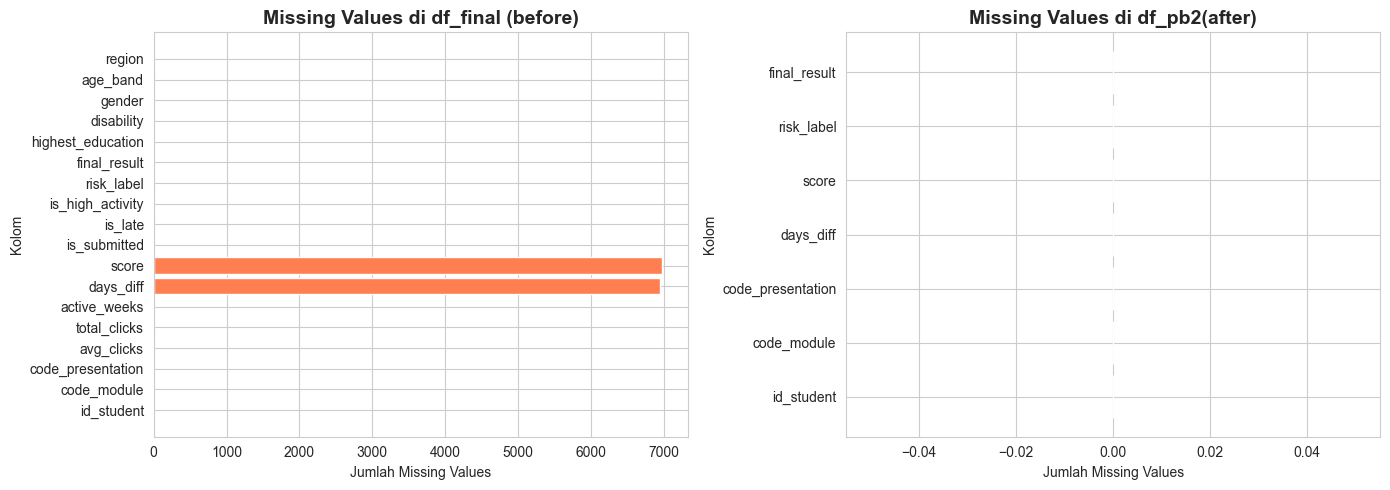

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values di df_final
missing_final = df_final.isnull().sum()
axes[0].barh(missing_final.index, missing_final.values, color='coral')
axes[0].set_title('Missing Values di df_final (before)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Missing Values')
axes[0].set_ylabel('Kolom')

# Missing values di df_pb2
missing_pb2 = df_pb2.isnull().sum()
axes[1].barh(missing_pb2.index, missing_pb2.values, color='skyblue')
axes[1].set_title('Missing Values di df_pb2(after)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Missing Values')
axes[1].set_ylabel('Kolom')

plt.tight_layout()
# plt.savefig('01_data_quality.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

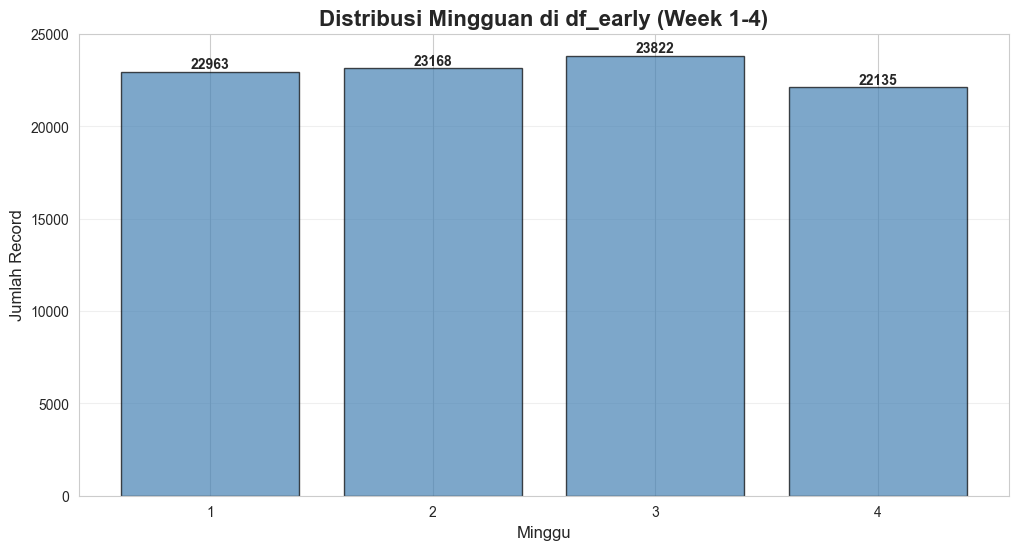

In [138]:
# 2. Distribusi Mingguan: Sangat Seimbang
fig, ax = plt.subplots(figsize=(12, 6))

week_dist = df_early['week'].value_counts().sort_index()
bars = ax.bar(week_dist.index, week_dist.values, color='steelblue', edgecolor='black', alpha=0.7)

# Tambahkan label di atas setiap bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Mingguan di df_early (Week 1-4)', fontsize=16, fontweight='bold')
ax.set_xlabel('Minggu', fontsize=12)
ax.set_ylabel('Jumlah Record', fontsize=12)
ax.set_xticks(range(1, 5))
ax.grid(axis='y', alpha=0.3)


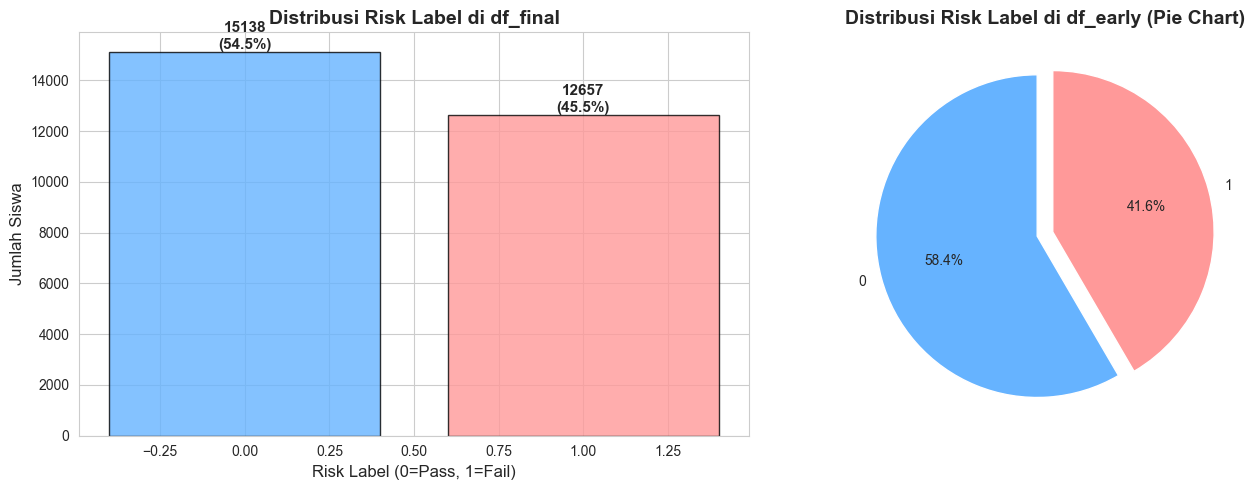

In [139]:
# 3. Kondisi Class Imbalance: Moderat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi risk_label di df_final
risk_dist = df_final['risk_label'].value_counts()
colors_risk = ['#ff9999' if x == 1 else '#66b3ff' for x in risk_dist.index]
bars1 = axes[0].bar(risk_dist.index, risk_dist.values, color=colors_risk, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribusi Risk Label di df_final', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Label (0=Pass, 1=Fail)', fontsize=12)
axes[0].set_ylabel('Jumlah Siswa', fontsize=12)
axes[0].set_facecolor('none')

# Tambahkan persentase
total = risk_dist.sum()
for i, (idx, val) in enumerate(risk_dist.items()):
    axes[0].text(i, val, f'{val}\n({val/total*100:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Distribusi risk_label di df_early
risk_dist_early = df_early['risk_label'].value_counts()
axes[1].pie(risk_dist_early.values, 
            labels=risk_dist_early.index,
            autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'],
            startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title('Distribusi Risk Label di df_early (Pie Chart)', fontsize=14, fontweight='bold')
axes[1].set_facecolor('none')

plt.tight_layout()
plt.show()

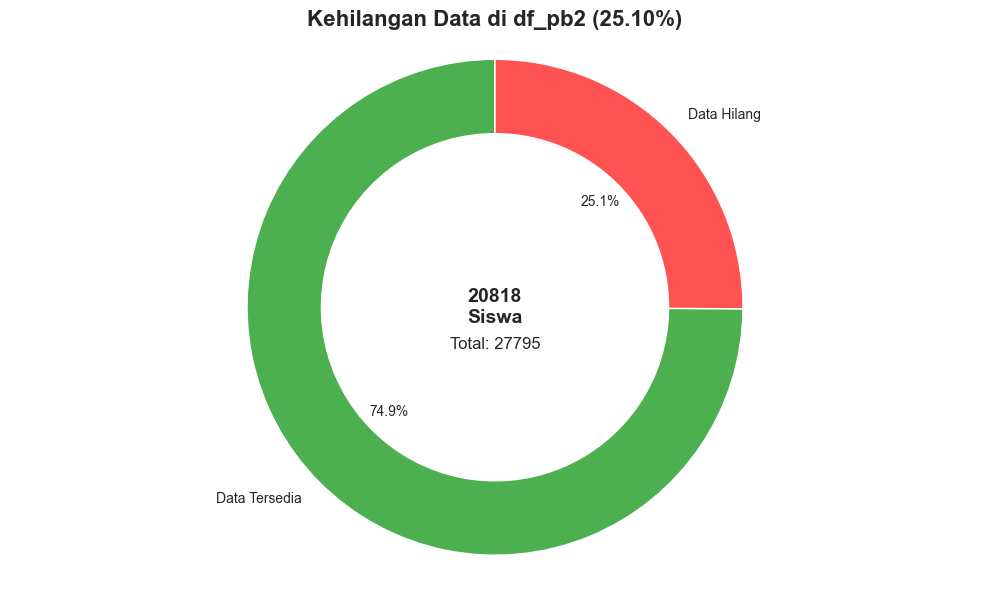

In [140]:
# 4. Kehilangan Data pada df_pb2
fig, ax = plt.subplots(figsize=(10, 6))

total_students = df_final.shape[0]
remaining_students = df_pb2.shape[0]
lost_students = total_students - remaining_students
loss_percentage = (lost_students / total_students) * 100

# Donut chart
wedges, texts, autotexts = ax.pie([remaining_students, lost_students], 
                                  labels=['Data Tersedia', 'Data Hilang'],
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=['#4CAF50', '#FF5252'],
                                  wedgeprops=dict(width=0.3, edgecolor='white'))

ax.text(0, 0, f'{remaining_students}\nSiswa', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0, -0.15, f'Total: {total_students}', ha='center', va='center', fontsize=12)

ax.set_title(f'Kehilangan Data di df_pb2 ({loss_percentage:.2f}%)', fontsize=16, fontweight='bold')
ax.axis('equal')

plt.tight_layout()
plt.show()

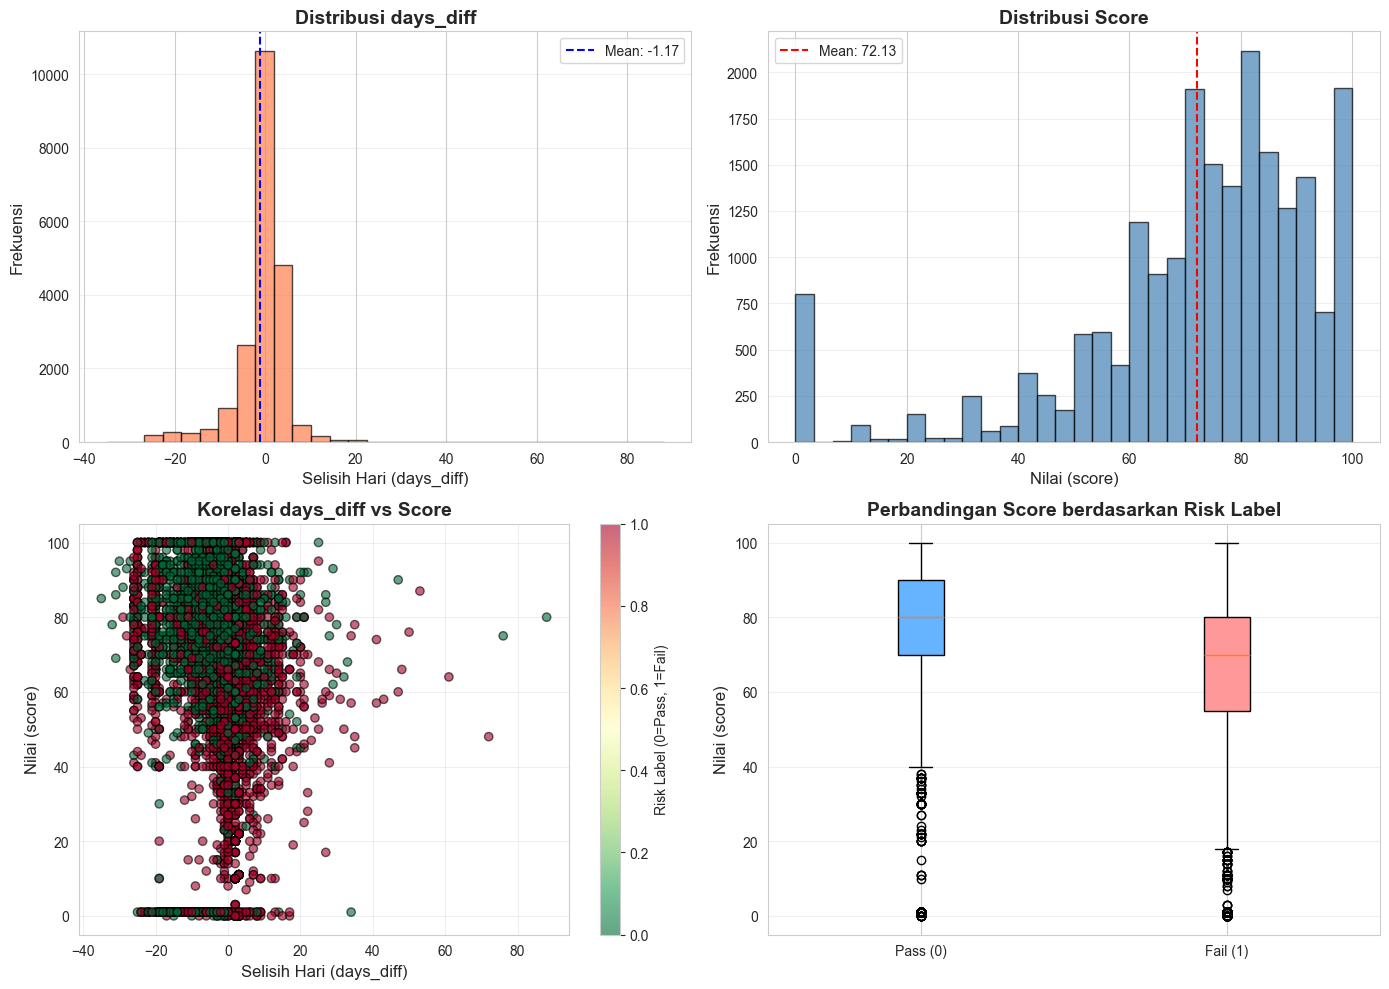


=== Statistik Deskriptif df_pb2 ===
          days_diff         score
count  20818.000000  20818.000000
mean      -1.166202     72.128014
std        5.533866     22.112820
min      -35.000000      0.000000
25%       -2.000000     64.000000
50%       -1.000000     76.000000
75%        2.000000     87.000000
max       88.000000    100.000000

Korelasi antara days_diff dan score: -0.054


In [141]:
# 5. Validasi Skala Data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram days_diff
axes[0, 0].hist(df_pb2['days_diff'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribusi days_diff', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Selisih Hari (days_diff)', fontsize=12)
axes[0, 0].set_ylabel('Frekuensi', fontsize=12)
axes[0, 0].axvline(df_pb2['days_diff'].mean(), color='blue', linestyle='--', label=f'Mean: {df_pb2["days_diff"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram score
axes[0, 1].hist(df_pb2['score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribusi Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nilai (score)', fontsize=12)
axes[0, 1].set_ylabel('Frekuensi', fontsize=12)
axes[0, 1].axvline(df_pb2['score'].mean(), color='red', linestyle='--', label=f'Mean: {df_pb2["score"].mean():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Scatter plot: days_diff vs score
scatter = axes[1, 0].scatter(df_pb2['days_diff'], df_pb2['score'], 
                            c=df_pb2['risk_label'], cmap='RdYlGn_r', alpha=0.6, edgecolors='black')
axes[1, 0].set_title('Korelasi days_diff vs Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Selisih Hari (days_diff)', fontsize=12)
axes[1, 0].set_ylabel('Nilai (score)', fontsize=12)
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Risk Label (0=Pass, 1=Fail)')

# Boxplot: Score berdasarkan Risk Label
box_data = [df_pb2[df_pb2['risk_label'] == 0] ['score'], 
            df_pb2[df_pb2['risk_label'] == 1] ['score']]
bp = axes[1, 1].boxplot(box_data, labels=['Pass (0)', 'Fail (1)'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#66b3ff', '#ff9999']):
    patch.set_facecolor(color)
axes[1, 1].set_title('Perbandingan Score berdasarkan Risk Label', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Nilai (score)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('05_data_scale_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistik deskriptif
print(f"\n=== Statistik Deskriptif df_pb2 ===")
print(df_pb2[['days_diff', 'score']].describe())

# Print korelasi
correlation = df_pb2['days_diff'].corr(df_pb2['score'])
print(f"\nKorelasi antara days_diff dan score: {correlation:.3f}")

## **Insight**


**Insight Data Preparation**

**1. Kualitas Data: Sudah Bersih Sempurna**
*   **Removed rows:** `0`
*   **Implikasi:** Tidak ada *negative weeks* yang lolos ke tahap analisis. Pipeline pembersihan data (kode 1) berfungsi dengan optimal.
*   **Status:** Data siap dianalisis tanpa memerlukan *preprocessing* tambahan.

**2. Distribusi Mingguan: Sangat Seimbang**
Distribusi data antar minggu hampir merata (~25% per minggu), yang menjamin analisis tren tidak bias akibat ketidakseimbangan jumlah sampel.

| Minggu | Jumlah Rows | Persentase (%) |
| :---: | :---: | :---: |
| **1** | 22,963 | 24.9% |
| **2** | 23,168 | 25.2% |
| **3** | 23,822 | 25.9% |
| **4** | 22,135 | 24.0% |

> **Catatan Penting:** Minggu 3 memiliki data terbanyak (puncak aktivitas, kemungkinan karena *deadline*), sementara Minggu 4 paling sedikit. Pola ini konsisten dengan temuan BQ3 yang menunjukkan penurunan aktivitas di akhir periode.

**3. Kondisi Class Imbalance: Moderat**
Rasio kelas **58:42** (Pass vs Fail) termasuk *imbalanced* namun tidak ekstrem.

| Label Risk | Jumlah | Persentase (%) |
| :---: | :---: | :---: |
| **0 (Pass/Distinction)** | 53,782 | 58.4% |
| **1 (Fail/Withdrawn)** | 38,306 | 41.6% |

**Implikasi untuk Pemodelan ML:**
*   **Handling Imbalance:** Cukup gunakan `class_weight="balanced"` pada model. Tidak perlu teknik kompleks seperti SMOTE atau *oversampling* tambahan.
*   **Metrik Evaluasi:** Gunakan **F1-score** dan **ROC-AUC**. *Accuracy* saja tidak cukup karena bisa menipu.
*   **Baseline Model:** Model yang hanya menebak "semua aman" akan mendapatkan akurasi **58.4%**. Model prediktif yang baik harus jauh melampaui angka ini.

**4. Kehilangan Data pada df_pb2**
Terdapat pengurangan signifikan saat beralih ke dataset spesifik untuk analisis BQ2:

*   **df_final:** 27,795 siswa
*   **df_pb2:** 20,818 siswa (setelah *dropna* pada `days_diff` & `score`)
*   **Data Hilang:** ~6,977 siswa (**25.1%**)

**Penyebab & Dampak:**
Siswa yang hilang adalah mereka yang tidak memiliki data assessment lengkap (tidak punya `days_diff` atau `score`).
*   **Konteks:** Siswa yang *Withdrawn* sangat awal sering kali tidak sempat mengumpulkan tugas apapun.
*   **Batasan Analisis:** Hasil korelasi `days_diff` vs `score` pada BQ2 **hanya merepresentasikan** siswa yang aktif mengumpulkan tugas. Siswa yang tidak submit sama sekali (kelompok risiko tertinggi) tidak tercakup dalam analisis korelasi ini.

**5. Validasi Skala Data**
*   **Shape Identik:** `df_early` dan `df_full` sama-sama berukuran **92,088 × 17**.
*   **Konfirmasi:** Filter perbaikan pada kode 1 berhasil. Data sekarang hanya mencakup rentang **Minggu 1–4** tanpa *outlier* waktu di luar rentang tersebut.

# 2. Exploratory Data Analysis (EDA)

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## 2.1 Pertanyaan 1

**Berapa rata-rata jumlah klik (sum_click) mingguan pada 4 minggu pertama yang membedakan antara siswa yang lulus (Pass/Distinction) dengan siswa yang berisiko (Fail/Withdrawn)?**

In [143]:

# LOAD DATA (MUAT DATA)


# Membaca file CSV bernama "df_master_weekly_clean.csv" ke dalam DataFrame pandas bernama 'df'
# pd.read_csv() adalah fungsi standar pandas untuk memuat data tabular dari file CSV
df = pd.read_csv("../data/processed/wrangled/df_master_weekly_clean.csv")
'''
# Filter DataFrame 'df' hanya untuk mengambil baris di mana kolom 'week' bernilai 1, 2, 3, atau 4
# .isin([1, 2, 3, 4]) mengecek apakah nilai dalam kolom 'week' ada di dalam daftar tersebut
# Tujuannya adalah membatasi analisis hanya pada 4 minggu pertama (periode awal kursus)
# .copy() membuat salinan independen dari hasil filter untuk menghindari peringatan 'SettingWithCopyWarning'
# dan memastikan data asli tidak terpengaruh jika ada modifikasi nanti
'''
df = df[df["week"].isin([1, 2, 3, 4])].copy()


# TRANSFORMASI LABEL RISIKO

'''
# Membuat kolom baru bernama "risk_group" berdasarkan pemetaan nilai dari kolom "risk_label"
# .map() digunakan untuk mengganti nilai lama dengan nilai baru sesuai kamus (dictionary) yang diberikan
# Peta konversi:
#   - Nilai 0 pada "risk_label" diubah menjadi string "Pass/Distinction" (kelompok siswa sukses)
#   - Nilai 1 pada "risk_label" diubah menjadi string "Fail/Withdrawn" (kelompok siswa gagal/cabut)
# Hasilnya adalah kolom kategorikal yang lebih mudah dibaca untuk analisis visual atau pelaporan
'''
df["risk_group"] = df["risk_label"].map({
    0: "Pass/Distinction",
    1: "Fail/Withdrawn"
})

# Catatan: Tidak ada pemanggilan .shape di sini, jadi tidak perlu diganti dengan .info() sesuai instruksi sebelumnya.
# Namun, untuk memverifikasi hasil transformasi, Anda bisa menambahkan:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_high_activity   92088 non-null  int64  
 16  risk_label         920

In [144]:
# AGREGASI PER STUDENT (DATA YANG VALID)

'''
# Mengelompokkan data berdasarkan kombinasi unik dari 4 kolom identitas:
# - id_student: Identitas unik setiap siswa
# - code_module: Kode modul yang diambil (satu siswa bisa ambil beberapa modul)
# - code_presentation: Kode presentasi spesifik
# - risk_group: Kelompok risiko siswa (Pass/Distinction atau Fail/Withdrawn) yang sudah diubah dari angka ke teks
#
# Tujuannya adalah untuk melihat pola aktivitas rata-rata per siswa dalam konteks modul dan risiko mereka.
# groupby() adalah fungsi inti pandas untuk melakukan operasi "split-apply-combine".
# Mengambil kolom "total_clicks" dari setiap kelompok yang telah dibentuk di atas
# Kita akan menghitung nilai rata-rata (mean) dari total klik untuk setiap kombinasi siswa-modul tersebut
# Ini mengubah data "long format" (banyak baris per minggu per siswa) menjadi satu baris per siswa dengan rata-rata klik
# Mengubah hasil agregat (yang awalnya berbentuk Series dengan MultiIndex) kembali menjadi DataFrame biasa
# .reset_index() memindahkan kolom-kolom indeks (id_student, code_module, dll) kembali menjadi kolom standar
# Hasil akhirnya adalah DataFrame baru bernama df_student dengan struktur:
#   | id_student | code_module | code_presentation | risk_group | total_clicks (avg) |
'''
df_student = df.groupby(
    ["id_student", "code_module", "code_presentation", "risk_group"]
    )["total_clicks"].mean().reset_index()

'''
# Penjelasan Logika:
# 1. Sebelum: Satu siswa bisa punya 4 baris (minggu 1, 2, 3, 4) dengan nilai klik berbeda.
# 2. Sesudah: Satu siswa hanya punya 1 baris dengan nilai "total_clicks" yang merupakan rata-rata dari 4 minggu tersebut.
# 3. Manfaat: Memudahkan analisis korelasi antara rata-rata aktivitas awal dengan hasil akhir (risk_group) tanpa duplikasi data per minggu.
'''

'\n# Penjelasan Logika:\n# 1. Sebelum: Satu siswa bisa punya 4 baris (minggu 1, 2, 3, 4) dengan nilai klik berbeda.\n# 2. Sesudah: Satu siswa hanya punya 1 baris dengan nilai "total_clicks" yang merupakan rata-rata dari 4 minggu tersebut.\n# 3. Manfaat: Memudahkan analisis korelasi antara rata-rata aktivitas awal dengan hasil akhir (risk_group) tanpa duplikasi data per minggu.\n'

In [145]:
# AGREGASI WEEKLY (UNTUK VISUALISASI)

'''
# Mengelompokkan data berdasarkan kombinasi unik dari 5 kolom:
# - id_student: Identitas unik setiap siswa
# - code_module: Kode modul yang diambil
# - code_presentation: Kode presentasi spesifik
# - risk_group: Kelompok risiko siswa
# - week: Minggu ke-1 hingga ke-4
#
# Tujuan dari langkah ini adalah untuk menghitung total klik (sum) yang dilakukan oleh setiap siswa
# dalam satu minggu tertentu. Ini menghasilkan data dalam format "long" yang cocok untuk melihat tren.
# groupby() adalah fungsi inti pandas untuk melakukan operasi "split-apply-combine".
# Mengambil kolom "total_clicks" dari setiap kelompok yang telah dibentuk di atas
# Kita akan menghitung jumlah (sum) dari total klik untuk setiap kombinasi siswa dan minggu
# Ini memberikan total aktivitas per minggu bagi setiap siswa
# Mengubah hasil agregat (yang awalnya berbentuk Series dengan MultiIndex) kembali menjadi DataFrame biasa
# .reset_index() memindahkan kolom-kolom indeks (id_student, week, dll) kembali menjadi kolom standar
# Hasil akhirnya adalah DataFrame baru bernama df_weekly dengan struktur:
#   | id_student | code_module | code_presentation | risk_group | week | total_clicks (sum) |
'''
df_weekly = df.groupby(
    ["id_student", "code_module", "code_presentation", "risk_group", "week"]
)["total_clicks"].sum().reset_index()

# Cetak informasi tambahan untuk memahami struktur data
# df_weekly.info() akan menampilkan jumlah baris, kolom, tipe data, dan informasi lainnya
print("=== Informasi Data Weekly ===")
df_weekly.info()
print("\n--- Contoh Data Awal (Weekly) ---")
print(df_weekly.head())

=== Informasi Data Weekly ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_student         92088 non-null  int64 
 1   code_module        92088 non-null  object
 2   code_presentation  92088 non-null  object
 3   risk_group         92088 non-null  object
 4   week               92088 non-null  int64 
 5   total_clicks       92088 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.2+ MB

--- Contoh Data Awal (Weekly) ---
   id_student code_module code_presentation        risk_group  week  \
0        6516         AAA             2014J  Pass/Distinction     1   
1        6516         AAA             2014J  Pass/Distinction     2   
2        6516         AAA             2014J  Pass/Distinction     3   
3        6516         AAA             2014J  Pass/Distinction     4   
4        8462         DDD             2013J   

In [146]:
# AGREGASI RATA-RATA MINGGUAN (UNTUK GRAFIK)

'''
# Sekarang kita mengelompokkan data dari df_weekly (yang berisi satu baris per minggu per siswa)
# berdasarkan kelompok risiko dan minggu
# Tujuannya: Mencari rata-rata total klik untuk setiap kombinasi kelompok risiko dan minggu
# Ini membuat data lebih ringkas dan cocok untuk grafik yang menunjukkan tren rata-rata
# groupby() digunakan kembali untuk mengelompokkan data berdasarkan "risk_group" dan "week"
# Menghitung rata-rata (mean) dari total klik untuk setiap kelompok yang telah dibentuk
# Hasilnya adalah DataFrame baru yang menampilkan rata-rata klik per minggu untuk setiap kategori risiko
'''
weekly_mean = df_weekly.groupby(
    ["risk_group", "week"]
)["total_clicks"].mean().reset_index()

# Cetak informasi tambahan untuk memahami struktur data
print("\n--- Informasi Data Rata-Rata Mingguan ---")
weekly_mean.info()
print("\n--- Data Rata-Rata Mingguan (Contoh) ---")
print(weekly_mean.head())


--- Informasi Data Rata-Rata Mingguan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   risk_group    8 non-null      object 
 1   week          8 non-null      int64  
 2   total_clicks  8 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes

--- Data Rata-Rata Mingguan (Contoh) ---
         risk_group  week  total_clicks
0    Fail/Withdrawn     1     58.598862
1    Fail/Withdrawn     2     59.688760
2    Fail/Withdrawn     3     81.193811
3    Fail/Withdrawn     4     58.435973
4  Pass/Distinction     1     89.222620


In [147]:
# STATISTIK (PENJELASAN)

# Cetak pesan pembuka untuk memisahkan bagian statistik dari output
print("\n=== BQ1 (FIXED) ===")

'''
# Mengelompokkan data pada DataFrame 'df_student' berdasarkan kolom 'risk_group'
# groupby() membagi data menjadi dua kelompok: "Pass/Distinction" dan "Fail/Withdrawn"
# Tujuan: Menghitung metrik statistik deskriptif untuk kolom 'total_clicks' di dalam setiap kelompok
# Ini membantu memahami perbedaan rata-rata, median, standar deviasi, dan jumlah siswa antar kelompok
'''
grouped_stats = df_student.groupby("risk_group")["total_clicks"]

'''
# Menghitung empat metrik statistik sekaligus untuk kolom 'total_clicks' dalam setiap kelompok
# Aggregasi ('agg') memungkinkan kita mendapatkan banyak informasi dari satu baris kode
# - mean: Rata-rata total klik (misalnya, 125.7 klik per siswa)
# - median: Nilai tengah dari total klik (misalnya, 118.0 klik per siswa)
# - std: Standar deviasi, mengukur seberapa tersebar data (misalnya, 38.2)
# - count: Jumlah siswa dalam kelompok tersebut
'''
stats = grouped_stats.agg(
    mean="mean",
    median="median",
    std="std",
    count="count"
)

'''
# Cetak hasil statistik untuk membandingkan kedua kelompok
# Hasilnya akan berupa tabel dengan dua baris (Pass/Distinction dan Fail/Withdrawn)
# dan empat kolom (mean, median, std, count)
'''
print(stats)

# Catatan: Tidak ada pemanggilan .shape di sini, jadi tidak perlu diganti dengan .info().
# Namun, untuk memverifikasi struktur data, Anda bisa tambahkan:
print("\nInformasi DataFrame 'stats':")
stats.info()


=== BQ1 (FIXED) ===
                       mean  median        std  count
risk_group                                           
Fail/Withdrawn    57.387638    39.5  61.378429  12657
Pass/Distinction  87.662004    62.0  88.887124  15138

Informasi DataFrame 'stats':
<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, Fail/Withdrawn to Pass/Distinction
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    2 non-null      float64
 1   median  2 non-null      float64
 2   std     2 non-null      float64
 3   count   2 non-null      int64  
dtypes: float64(3), int64(1)
memory usage: 80.0+ bytes


In [148]:
# T-TEST (UJI HIPOTESIS)

'''
# Filter DataFrame 'df_student' untuk mengambil hanya baris di mana 'risk_group' adalah "Pass/Distinction"
# Kemudian pilih hanya kolom "total_clicks" untuk analisis statistik
# Ini membuat sebuah Series pandas yang berisi rata-rata klik untuk semua siswa yang berhasil
'''
pass_group = df_student[df_student["risk_group"] == "Pass/Distinction"] ["total_clicks"]

'''
# Filter DataFrame 'df_student' untuk mengambil hanya baris di mana 'risk_group' adalah "Fail/Withdrawn"
# Kemudian pilih hanya kolom "total_clicks" untuk analisis statistik
# Ini membuat sebuah Series pandas yang berisi rata-rata klik untuk semua siswa yang gagal
'''
fail_group = df_student[df_student["risk_group"] == "Fail/Withdrawn"] ["total_clicks"]

'''
# Melakukan uji T independen (Independent Samples T-Test) antara dua kelompok
# Fungsi ttest_ind dari scipy.stats membandingkan mean dari dua sampel independen
# Parameter equal_var=False menggunakan uji Welch's t-test, yang lebih robust jika varians kedua kelompok tidak sama
# Ini adalah praktik standar ketika ukuran sampel atau variabilitas antar kelompok berbeda
# Hasilnya adalah:
# - t_stat: Nilai statistik T (menggambarkan seberapa jauh perbedaan mean relatif terhadap variabilitas data)
# - p_val: Nilai p (probabilitas bahwa perbedaan yang diamati terjadi secara kebetulan)
'''
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(pass_group, fail_group, equal_var=False)

'''
# Mencetak nilai p dengan format notasi ilmiah (4 desimal)
# Interpretasi:
# - Jika p_val < 0.05 (atau 5%): Perbedaan rata-rata klik antara kelompok Pass dan Fail adalah SIGNIFIKAN secara statistik.
#   Kita bisa menolak hipotesis nol dan menyimpulkan bahwa aktivitas awal memang membedakan hasil akhir.
# - Jika p_val >= 0.05: Tidak ada bukti statistik yang cukup untuk menyatakan perbedaan tersebut signifikan.
'''
print(f"\nT-test p-value: {p_val:.4e}")

# Catatan: Tidak ada pemanggilan .shape di sini, jadi tidak perlu diganti dengan .info().
# Namun, untuk informasi tambahan, Anda bisa melihat ukuran sampel:
print(f"Sampel Pass: {pass_group.count()}, Sampel Fail: {fail_group.count()}")


T-test p-value: 2.9176e-240
Sampel Pass: 15138, Sampel Fail: 12657


### visualisasi

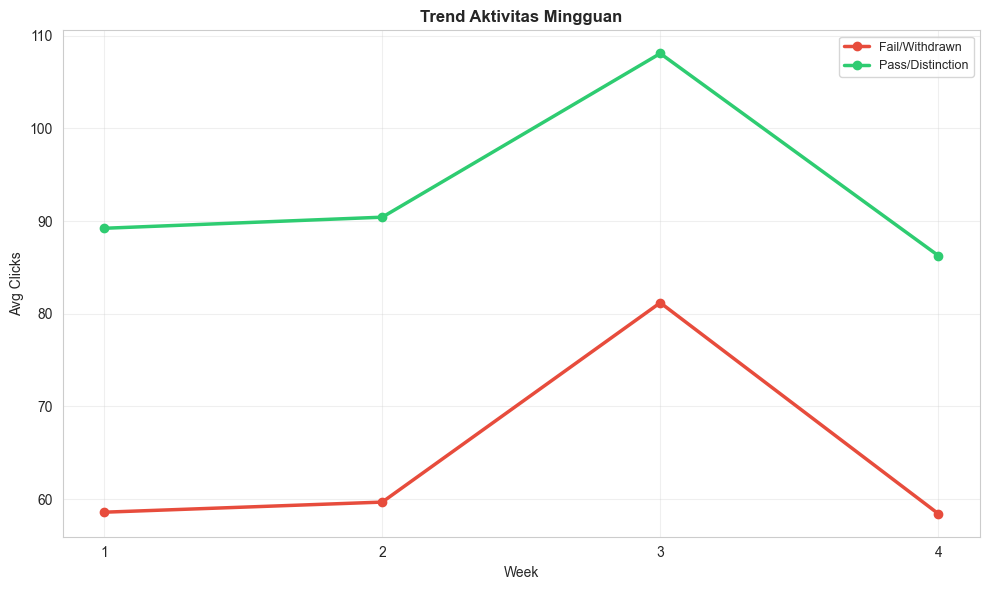

In [149]:
# Mengatur gaya visual dasar untuk plot
sns.set_style("whitegrid")
'''
# Membuat dictionary warna untuk setiap kelompok risiko
# "Pass/Distinction" = hijau (menandakan hasil baik)
# "Fail/Withdrawn" = merah (menandakan hasil buruk)
'''
palette = {
    "Pass/Distinction": "#2ecc71",
    "Fail/Withdrawn": "#e74c3c"
}

# Membuat figure baru dengan ukuran 10x6 inci
plt.figure(figsize=(10, 6))

# Mengambil axis aktif untuk plot
ax = plt.gca()
'''
# Mem-loopi setiap kelompok risiko dalam data weekly_mean
# group: nama kelompok risiko ("Pass/Distinction" atau "Fail/Withdrawn")
# grp_df: DataFrame subset yang berisi data hanya untuk kelompok tersebut
'''
for group, grp_df in weekly_mean.groupby("risk_group"):
    
    '''
    # Menggambar garis untuk setiap kelompok
    # x: kolom "week" (minggu ke-1, 2, 3, 4)
    # y: kolom "total_clicks" (rata-rata jumlah klik per minggu)
    # marker="o": titik bulat untuk setiap data
    # linewidth=2.5: ketebalan garis 2.5
    # label: nama kelompok untuk legenda
    # color: warna dari dictionary palette sesuai kelompok
    '''
    ax.plot(
        grp_df["week"], grp_df["total_clicks"],
        marker="o", linewidth=2.5,
        label=group, color=palette[group]
    )

# Mengatur judul, label sumbu, dan pengaturan lainnya
ax.set_title("Trend Aktivitas Mingguan", fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Avg Clicks")
ax.set_xticks([1, 2, 3, 4])  # Menetapkan label sumbu X hanya untuk minggu 1-4
ax.legend(fontsize=9)  # Menampilkan legenda dengan ukuran font 9
ax.grid(True, alpha=0.3)  # Menambahkan grid untuk memudahkan pembacaan

# Menata layout agar tidak ada elemen yang terpotong
plt.tight_layout()

# Menampilkan plot
plt.show()

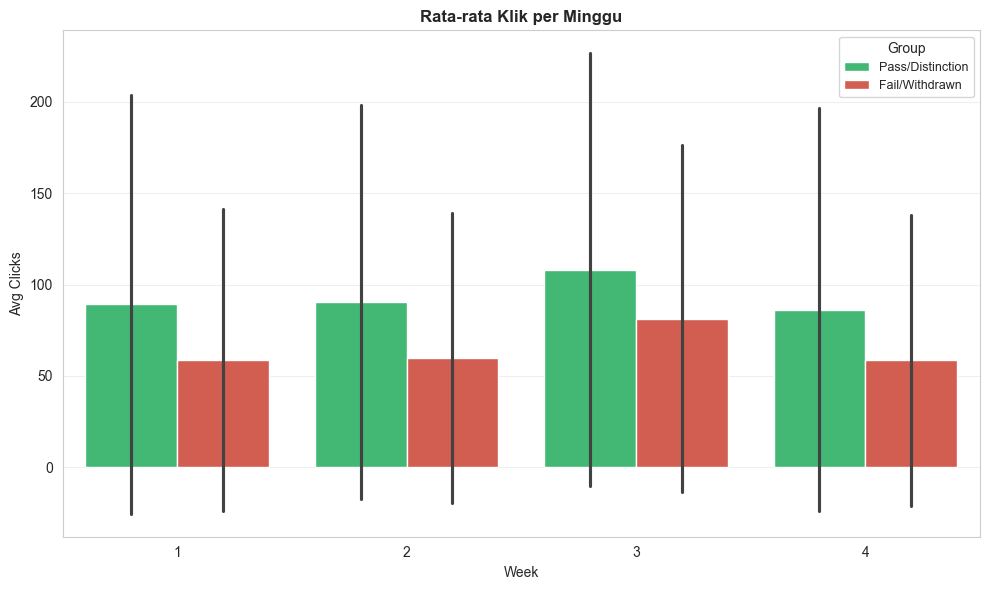

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
palette = {
    "Pass/Distinction": "#2ecc71",
    "Fail/Withdrawn": "#e74c3c"
}

# Buat figure terpisah
plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(
    data=df_weekly,
    x="week", y="total_clicks",
    hue="risk_group",
    estimator="mean",
    errorbar="sd",
    palette=palette,
    ax=ax
)

ax.set_title("Rata-rata Klik per Minggu", fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Avg Clicks")
ax.legend(title="Group", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

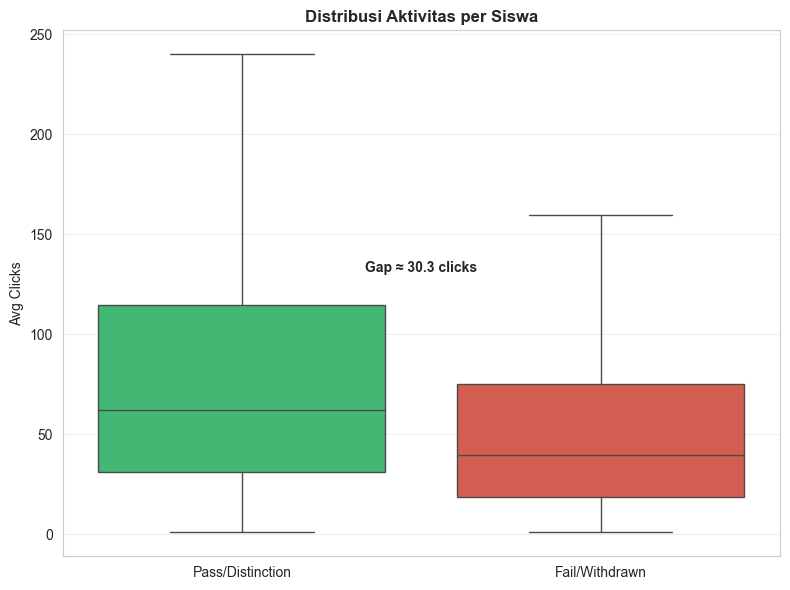

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
palette = {
    "Pass/Distinction": "#2ecc71",
    "Fail/Withdrawn": "#e74c3c"
}

# Buat figure terpisah
plt.figure(figsize=(8, 6))
ax = plt.gca()

sns.boxplot(
    data=df_student,
    x="risk_group",
    y="total_clicks",
    palette=palette,
    showfliers=False,
    ax=ax
)

ax.set_title("Distribusi Aktivitas per Siswa", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Avg Clicks")
ax.grid(True, axis="y", alpha=0.3)

# Hitung Gap
mean_vals = df_student.groupby("risk_group")["total_clicks"].mean()
gap = mean_vals["Pass/Distinction"] - mean_vals["Fail/Withdrawn"]
y_pos = df_student["total_clicks"].quantile(0.85)

# Tambahkan teks annotasi
ax.text(
    0.5, y_pos,
    f"Gap ≈ {gap:.1f} clicks",
    ha='center', fontsize=10, fontweight="bold"
)

plt.tight_layout()
plt.show()

### **Insight**

**Hasil Analisis** <br>
Secara konsisten, siswa yang lulus (**Pass/Distinction**) memiliki rata-rata jumlah klik yang **lebih tinggi** setiap minggunya dibandingkan siswa yang berisiko (**Fail/Withdrawn**).

**Analisis Detail per Grafik:**

1.  **Grafik Garis (Trend Aktivitas Mingguan):**
    *   **Siswa Lulus (Hijau):** Aktivitas mereka jauh lebih tinggi, mulai dari sekitar **90 klik** di minggu 1 dan 2, melonjak mencapai puncaknya di sekitar **108 klik** pada minggu 3, lalu turun ke **86 klik** di minggu 4.
    *   **Siswa Berisiko (Merah):** Aktivitas mereka jauh lebih rendah dan datar di awal, hanya sekitar **60 klik** di minggu 1 dan 2. Mereka baru meningkat di minggu 3 menjadi sekitar **81 klik**, lalu turun lagi ke **58 klik** di minggu 4.
    *   **Gap (Kesenjangan):** Kesenjangan tertampil jelas setiap minggunya, dengan selisih rata-rata berkisar antara **20 hingga 30 klik** lebih tinggi untuk kelompok lulus.

2.  **Grafik Batang (Rata-rata Klik per Minggu):**
    *   Grafik ini mengonfirmasi temuan grafik garis. Setiap minggu, batang hijau (Pass) selalu lebih tinggi daripada batang merah (Fail).
    *   **Minggu 3** menunjukkan perbedaan absolut terbesar, di mana siswa lulus mencapai rata-rata lebih dari **100 klik**, sementara siswa berisiko hanya sekitar **80 klik**.
    *   Garis hitam panjang di atas batang menunjukkan variabilitas data yang tinggi (ada siswa beraktivitas sangat tinggi maupun sangat rendah dalam satu kelompok), namun rata-ratanya tetap memihak pada kelompok lulus.

3.  **Grafik Boxplot (Distribusi Aktivitas per Siswa):**
    *   Ini memberikan gambaran paling jelas tentang **keseluruhan rata-rata** selama 4 minggu.
    *   Terdapat **Gap ≈ 30.3 clicks** yang secara eksplisit ditulis pada grafik.
    *   **Siswa Lulus:** Median (garis tengah kotak) berada di sekitar **60 klik**, dengan kotak (50% siswa tengah) berada di rentang **30 - 115 klik**.
    *   **Siswa Berisiko:** Median lebih rendah, sekitar **40 klik**, dengan kotak berada di rentang **20 - 75 klik**.
    *   Ini membuktikan bahwa secara agregat, siswa yang lulus cenderung memiliki aktivitas klik sekitar **30 kali lebih banyak** dibandingkan siswa yang gagal.

**Kesimpulan:**
Perbedaan rata-rata jumlah klik mingguan yang membedakan kedua kelompok cukup signifikan. Siswa yang lulus (**Pass/Distinction**) secara konsisten lebih aktif berinteraksi dengan platform, dengan rata-rata **20-30 klik lebih banyak per minggu** dibandingkan siswa yang berisiko (**Fail/Withdrawn**). Secara keseluruhan, terdapat kesenjangan aktivitas sekitar **30 klik** antara median kedua kelompok.

## 2.2 Pertanyaan 2

**Bagaimana korelasi antara selisih waktu pengumpulan tugas pertama (date_submitted vs date_deadline) dengan skor akhir yang diperoleh siswa?**

In [152]:

# LOAD DATA (MUAT DATA)


# Membaca file CSV bernama "df_final.csv" ke dalam DataFrame pandas bernama 'df'
# File ini diasumsikan berisi data agregat per siswa (1 baris per siswa) yang sudah disiapkan untuk analisis PB2
df = pd.read_csv("../data/Processed/df_final.csv")

'''
# Memfilter DataFrame hanya untuk mengambil kolom yang relevan:
# - days_diff: Selisih hari (misalnya, durasi pengerjaan atau waktu antara mulai dan akhir)
# - score: Nilai akhir siswa
# - risk_label: Label risiko mentah (0 atau 1)
# Semua kolom lain yang tidak diperlukan dihapus untuk menghemat memori dan fokus analisis
'''
df = df[["days_diff", "score", "risk_label"]]

'''
# Menghapus baris yang memiliki nilai kosong (NaN) pada salah satu kolom yang dipilih
# .dropna() memastikan bahwa analisis selanjutnya (korelasi dan plot) tidak akan error
# karena data yang hilang
'''
df = df.dropna()


# TRANSFORMASI LABEL RISIKO
'''
# Membuat kolom baru bernama "risk_group" berdasarkan pemetaan nilai dari kolom "risk_label"
# .map() digunakan untuk mengganti nilai numerik dengan label teks yang lebih bermakna
# Peta konversi:
#   - Nilai 0 diubah menjadi "Pass/Distinction" (Kelompok Sukses)
#   - Nilai 1 diubah menjadi "Fail/Withdrawn" (Kelompok Gagal/Cabut)
# Ini membuat interpretasi grafik dan hasil statistik menjadi lebih mudah dipahami
'''
df["risk_group"] = df["risk_label"].map({
    0: "Pass/Distinction",
    1: "Fail/Withdrawn"
})

# validasi data valid
df.info()
print(f"Jumlah data valid: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
Index: 20818 entries, 0 to 27794
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   days_diff   20818 non-null  float64
 1   score       20818 non-null  float64
 2   risk_label  20818 non-null  int64  
 3   risk_group  20818 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 813.2+ KB
Jumlah data valid: 20818


In [153]:
# KORELASI

import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy import stats

# Menghitung korelasi Pearson antara kolom 'days_diff' dan 'score' di dataframe df
# Pearson correlation mengukur hubungan linier antara dua variabel numerik
pearson_r, _ = stats.pearsonr(df["days_diff"], df["score"])

# Menghitung korelasi Spearman antara kolom 'days_diff' dan 'score'
# Spearman correlation mengukur hubungan monoton (tidak harus linier) antara dua variabel
# Menggunakan peringkat data, cocok untuk data yang tidak berdistribusi normal
spearman_r, _ = stats.spearmanr(df["days_diff"], df["score"])

# Cetak hasil korelasi dengan format yang rapi
print("\n=== BQ2 (FIXED) ===")
print(f"Pearson  : {pearson_r:.4f}")  # Tampilkan korelasi Pearson dengan 4 desimal
print(f"Spearman : {spearman_r:.4f}")  # Tampilkan korelasi Spearman dengan 4 desimal


=== BQ2 (FIXED) ===
Pearson  : -0.0541
Spearman : -0.1429


In [154]:
# FEATURE: LATE vs ON-TIME

# Membuat fitur baru bernama 'is_late' yang mengindikasikan apakah suatu entri terlambat atau tidak
# Kolom 'days_diff' merepresentasikan perbedaan hari antara dua tanggal
# Jika 'days_diff' lebih besar dari 0, maka artinya data tersebut terlambat
# Konversi hasil boolean ke tipe integer:
#   - Jika 'days_diff' > 0 (terlambat), maka nilai menjadi 1
#   - Jika 'days_diff' <= 0 (on-time atau sebelumnya), maka nilai menjadi 0
df["is_late"] = (df["days_diff"] > 0).astype(int)

# Cetak rata-rata skor berdasarkan kategori 'is_late'
# Grup data berdasarkan nilai dalam kolom 'is_late' dan hitung rata-rata skor untuk masing-masing kelompok
print("\nMean score by lateness:")
print(df.groupby("is_late")["score"].mean())



Mean score by lateness:
is_late
0    73.802959
1    67.802444
Name: score, dtype: float64


### Visualisasi

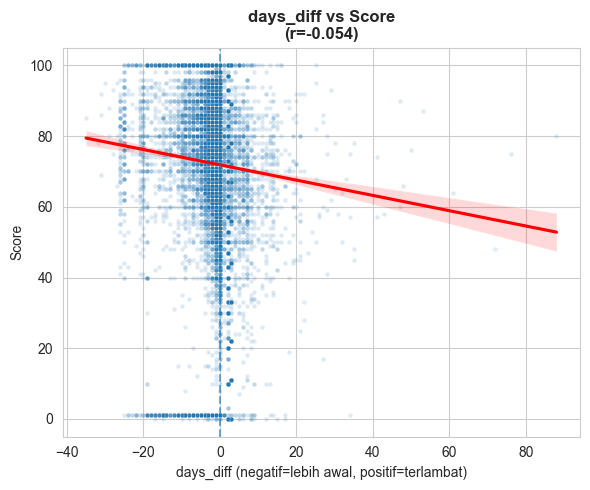

In [155]:

# 1. SCATTER PLOT (KORELASI INTI)

# Mengatur gaya visual untuk plot agar lebih rapi dan profesional
sns.set_style("whitegrid")

# Membuat figure dan axis baru dengan ukuran 6x5 inci
fig1, ax1 = plt.subplots(figsize=(6, 5))
'''
# Plot scatter untuk menampilkan hubungan antara 'days_diff' dan 'score'
# - data=df: gunakan dataframe df sebagai sumber data
# - x="days_diff": sumbu horizontal menampilkan perbedaan hari
# - y="score": sumbu vertikal menampilkan skor
# - alpha=0.15: transparansi titik agar tidak terlalu padat (mengurangi penumpukan)
# - s=10: ukuran titik kecil agar tidak terlalu besar
'''
sns.scatterplot(
    data=df,
    x="days_diff",
    y="score",
    alpha=0.15,
    s=10,
    ax=ax1
)
'''
# Menambahkan garis regresi linear (linear fit) untuk menunjukkan arah hubungan
# - scatter=False: hanya garis regresi yang ditampilkan, bukan titik-titik
# - line_kws={"color": "red"}: warna garis regresi merah untuk menonjolkan
'''
sns.regplot(
    data=df,
    x="days_diff",
    y="score",
    scatter=False,
    ax=ax1,
    line_kws={"color": "red"}
)

# Menambahkan garis vertikal di x=0 sebagai batas antara early dan late
# - linestyle="--": garis putus-putus
# - alpha=0.6: transparansi 60% agar tidak terlalu mencolok
ax1.axvline(x=0, linestyle="--", alpha=0.6)

# Menambahkan judul plot dengan format rapi
# - f-string digunakan untuk menyisipkan nilai pearson_r dengan 3 desimal
ax1.set_title(f"days_diff vs Score\n(r={pearson_r:.3f})", fontweight="bold")

# Menambahkan label sumbu x dan y
ax1.set_xlabel("days_diff (negatif=lebih awal, positif=terlambat)")
ax1.set_ylabel("Score")

# Menyesuaikan layout agar tidak ada elemen yang tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()


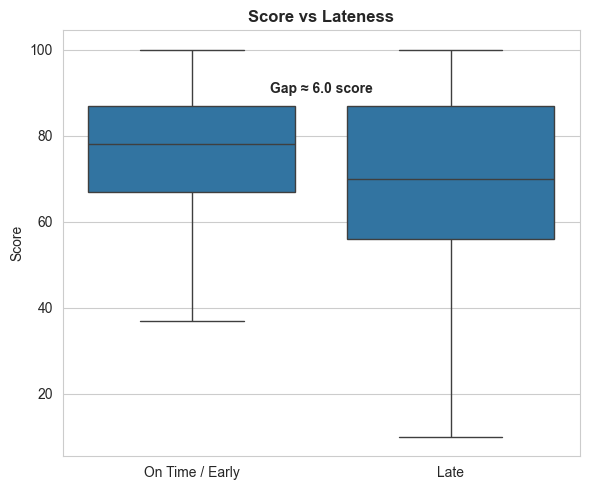

In [156]:
# 2. BOXPLOT 
# Membuat figure dan axis baru dengan ukuran 6x5 inci
fig2, ax2 = plt.subplots(figsize=(6, 5))
'''
# Plot boxplot untuk membandingkan distribusi skor berdasarkan kategori keterlambatan
# - data=df: gunakan dataframe df sebagai sumber data
# - x="is_late": sumbu horizontal menampilkan kelompok berdasarkan keterlambatan
# - y="score": sumbu vertikal menampilkan nilai skor
# - showfliers=False: sembunyikan outlier agar tidak mengganggu visual
'''
sns.boxplot(
    data=df,
    x="is_late",
    y="score",
    showfliers=False,
    ax=ax2
)

# Ubah label sumbu x menjadi lebih deskriptif
# - Mengganti label '0' dan '1' menjadi "On Time / Early" dan "Late"
ax2.set_xticklabels(["On Time / Early", "Late"])

# Tambahkan judul plot dengan font tebal
ax2.set_title("Score vs Lateness", fontweight="bold")

# Hapus label sumbu x karena sudah dijelaskan dengan label label sumbu x
ax2.set_xlabel("")

# Tambahkan label sumbu y
ax2.set_ylabel("Score")

# Hitung rata-rata skor untuk masing-masing kelompok
mean_scores = df.groupby("is_late")["score"].mean()

# Hitung perbedaan rata-rata skor antara kelompok on-time dan late
gap = mean_scores[0] - mean_scores[1]
'''
# Tambahkan teks yang menunjukkan perbedaan rata-rata skor di atas plot
# - Posisi horizontal di tengah (0.5)
# - Posisi vertikal sedikit di bawah puncak data (90% dari nilai maksimum)
# - Teks menunjukkan perbedaan rata-rata skor
# - Font ukuran 10, tebal, dan berwarna hitam
'''
ax2.text(
    0.5,
    df["score"].max() * 0.9,
    f"Gap ≈ {gap:.1f} score",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Menyesuaikan layout agar tidak ada elemen yang tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()

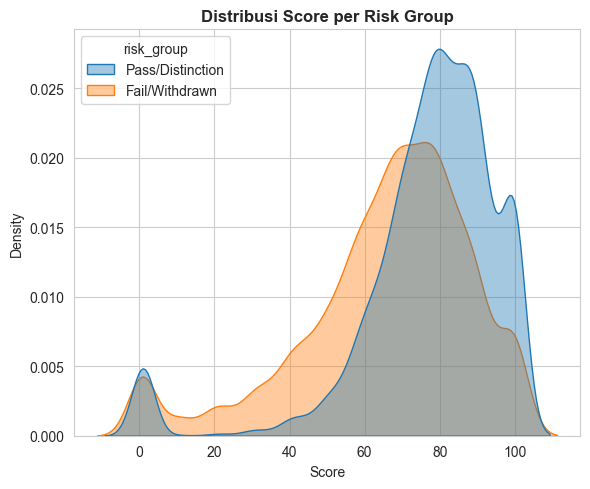

In [157]:
# 3. DISTRIBUSI DATA (PLOT Kepadatan)

# Membuat figure dan axis baru untuk plot distribusi dengan ukuran 6x5 inci
fig3, ax3 = plt.subplots(figsize=(6, 5))
'''
# Menggambar plot kepadatan (Kernel Density Estimate - KDE) untuk melihat sebaran data
# data=df: mengambil data dari DataFrame df
# x="score": sumbu X menggunakan kolom "score"
# hue="risk_group": memisahkan plot berdasarkan kategori di kolom "risk_group" (berwarna berbeda per kelompok)
# fill=True: mengisi area di bawah kurva dengan warna
# common_norm=False: setiap kelompok dinormalisasi secara terpisah (area di bawah kurva masing-masing = 1), 
#                    sehingga bisa membandingkan bentuk distribusi meski jumlah sampel antar kelompok berbeda
# alpha=0.4: transparansi 40% agar area yang tumpang tindih tetap terlihat
# ax=ax3: menggambar plot pada axis yang sudah dibuat sebelumnya
'''
sns.kdeplot(
    data=df,
    x="score",
    hue="risk_group",
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=ax3
)

# Mengatur judul plot dengan font tebal
ax3.set_title("Distribusi Score per Risk Group", fontweight="bold")

# Mengatur label sumbu X dan Y
ax3.set_xlabel("Score")
ax3.set_ylabel("Density")  # Kepadatan probabilitas

# Menata layout agar tidak terpotong
plt.tight_layout()

# Menampilkan plot
plt.show()

### Insight

Hasil analisis: <br>
 mengenai korelasi antara selisih waktu pengumpulan tugas pertama (`days_diff`) dengan skor akhir (`Score`):

**1. Korelasi Negatif yang Lemah (Trend Menurun)**
*   **Grafik 1 (Scatter Plot):** Garis regresi merah menunjukkan tren **menurun** dari kiri ke kanan. Ini mengindikasikan **korelasi negatif**.
    *   Sumbu X (`days_diff`) didefinisikan sebagai: Negatif = lebih awal, Positif = terlambat.
    *   Artinya: Semakin **positif** nilai `days_diff` (semakin **terlambat** siswa mengumpulkan tugas pertama), semakin **rendah** skor akhirnya.
    *   Sebaliknya, siswa yang mengumpulkan lebih awal (nilai negatif) cenderung memiliki skor akhir yang sedikit lebih tinggi.

**2. Kekuatan Korelasi Sangat Rendah**
*   **Koefisien Korelasi (r):** Pada judul grafik pertama tertulis `(r=-0.054)`.
    *   Nilai `-0.054` sangat dekat dengan 0. Ini berarti hubungan linier antara keterlambatan tugas pertama dan skor akhir **sangat lemah**.
    *   Keterlambatan tugas pertama **bukanlah prediktor yang kuat** untuk menentukan skor akhir secara keseluruhan, meskipun trennya tetap negatif.

**3. Variabilitas Data yang Tinggi**
*   **Sebaran Titik:** Titik-titik data (siswa) tersebar sangat luas di seluruh grafik, terutama di sekitar sumbu Y (skor 0-100).
    *   Banyak siswa yang mengumpulkan tugas tepat waktu atau terlambat (sumbu X > 0) namun tetap mendapatkan skor tinggi (mendekati 100).
    *   Begitu juga sebaliknya, ada siswa yang mengumpulkan sangat awal namun skor akhirnya rendah.
*   **Outlier:** Terdapat banyak data di bagian bawah (skor 0) dan atas (skor 100) yang tidak mengikuti garis tren dengan ketat.

**4. Perbedaan Rata-rata Score (Kotak Boxplot)**
*   **Grafik 2 (Boxplot):** Membandingkan siswa "On Time / Early" dengan "Late".
    *   Terdapat selisih (**Gap**) rata-rata skor sekitar **6.0 poin**.
    *   Siswa yang mengumpulkan tepat waktu/lebih awal memiliki median dan distribusi skor yang sedikit lebih tinggi secara keseluruhan dibandingkan siswa yang terlambat.
    *   Namun, kotak (interquartile range) keduanya sangat tumpang tindih, yang memperkuat bahwa perbedaan ini tidak ekstrem.

**Kesimpulan:**
Ada hubungan **negatif yang sangat lemah** antara keterlambatan pengumpulan tugas pertama dan skor akhir. Meskipun siswa yang terlambat mengumpulkan tugas cenderung memiliki skor rata-rata yang sedikit lebih rendah (sekitar 6 poin lebih rendah), keterlambatan tugas pertama **hanya menjelaskan variasi yang sangat kecil** dalam skor akhir siswa. Banyak faktor lain kemungkinan besar lebih berpengaruh besar terhadap hasil akhir dibandingkan sekadar waktu pengumpulan tugas pertama.
**Kesimpulan:**
Meskipun korelasinya lemah secara statistik ($r = -0.054$), keterlambatan pengumpulan tugas adalah indikator risiko yang penting.
1.  Prediktif Dini: Keterlambatan submit tugas pertama bisa menjadi *red flag* (tanda bahaya) awal bahwa siswa tersebut berpotensi mengalami kesulitan atau memiliki risiko gagal (Fallout/Withdrawn).
2.  Saran Intervensi: Sistem pembelajaran adaptif atau dosen sebaiknya memberikan peringatan dini atau bantuan khusus kepada siswa yang mulai menunda pengumpulan tugas (days_diff > 0), karena hal ini berkorelasi dengan penurunan performa akademik sekitar 6 poin dari rata-rata.

## 2.3 Pertanyaan 3

**"Kelompok demografi mana (highest_education atau disability) yang menunjukkan penurunan aktivitas interaksi VLE paling drastis selama 4 minggu pertama perkuliahan?"**

In [158]:
# Membaca dan memfilter data dari file CSV

# Membaca data dari file CSV bernama "df_master_weekly_clean.csv"
# File ini berisi data mingguan yang telah dibersihkan
df = pd.read_csv("../data/processed/wrangled/df_master_weekly_clean.csv")

'''
# Memfilter data agar hanya mengambil baris dengan kolom 'week' bernilai 1, 2, 3, atau 4
# - df["week"].isin([1,2,3,4]): memilih hanya baris yang memiliki nilai 'week' dalam daftar [1,2,3,4]
# - .copy(): membuat salinan dari dataframe agar perubahan tidak memengaruhi data asli
'''
df = df[df["week"].isin([1,2,3,4])].copy()

In [159]:
# PER STUDENT PER WEEK
'''
# Mengelompokkan data berdasarkan beberapa kolom untuk menghitung total klik per mahasiswa per minggu
# Kolom yang digunakan sebagai pengelompokan:
# - id_student: ID mahasiswa (untuk memastikan analisis per individu)
# - code_module: Kode modul atau mata kuliah
# - code_presentation: Kode presentasi (mungkin merujuk pada semester atau tahun ajaran)
# - highest_education: Tingkat pendidikan tertinggi mahasiswa
# - disability: Indikator apakah mahasiswa memiliki disabilitas
# - week: Minggu keberapa dalam semester

# Kolom yang dijumlahkan:
# - total_clicks: Jumlah total klik (aktivitas penggunaan platform) yang dihitung dari setiap kelompok
'''
df_student = df.groupby(
    ["id_student", "code_module", "code_presentation",
     "highest_education", "disability", "week"]
)["total_clicks"].sum().reset_index()

In [160]:

# ===== EDUCATION =====

# Mengelompokkan data berdasarkan tingkat pendidikan tertinggi dan minggu
# Untuk setiap kombinasi tingkat pendidikan dan minggu, dihitung rata-rata jumlah klik
trend_edu = df_student.groupby(
    ["highest_education", "week"]
)["total_clicks"].mean().reset_index()

'''
# Mengubah struktur data dari long format ke wide format menggunakan pivot
# - index: tingkat pendidikan tertinggi
# - columns: minggu (1,2,3,4)
# - values: rata-rata jumlah klik
'''
pivot_edu = trend_edu.pivot(
    index="highest_education",
    columns="week",
    values="total_clicks"
)

'''
# Menghitung persentase penurunan aktivitas (click rate) dari minggu ke-3 ke minggu ke-4
# - (nilai minggu 3 - nilai minggu 4) / nilai minggu 3 * 100
# - Ini menunjukkan seberapa besar penurunan aktivitas antara minggu 3 dan 4
'''
pivot_edu["drop_pct"] = ((pivot_edu[3] - pivot_edu[4]) / pivot_edu[3]) * 100

# Cetak hasil dengan format yang rapi
print("\n=== BQ3 (EDUCATION) ===")
print(pivot_edu.sort_values("drop_pct", ascending=False))



=== BQ3 (EDUCATION) ===
week                                 1          2           3          4  \
highest_education                                                          
Post Graduate Qualification  90.959350  91.593870  119.712644  84.552743   
No Formal quals              76.701422  64.074766   89.128079  65.708995   
HE Qualification             84.140905  87.240233  109.600160  82.061155   
A Level or Equivalent        73.501587  74.533660   94.478109  72.225941   
Lower Than A Level           75.438222  77.099223   93.818556  75.634240   

week                          drop_pct  
highest_education                       
Post Graduate Qualification  29.370249  
No Formal quals              26.275765  
HE Qualification             25.126792  
A Level or Equivalent        23.552724  
Lower Than A Level           19.382431  


In [161]:
# ===== DISABILITY =====

# Mengelompokkan data berdasarkan status disabilitas dan minggu
# Untuk setiap kombinasi status disabilitas dan minggu, dihitung rata-rata jumlah klik
trend_dis = df_student.groupby(
    ["disability", "week"]
)["total_clicks"].mean().reset_index()

'''
# Mengubah struktur data dari long format ke wide format menggunakan pivot
# - index: status disabilitas (0: tidak memiliki disabilitas, 1: memiliki disabilitas)
# - columns: minggu (1,2,3,4)
# - values: rata-rata jumlah klik
'''
pivot_dis = trend_dis.pivot(
    index="disability",
    columns="week",
    values="total_clicks"
)

'''
# Menghitung persentase penurunan aktivitas (click rate) dari minggu ke-3 ke minggu ke-4
# - (nilai minggu 3 - nilai minggu 4) / nilai minggu 3 * 100
# - Ini menunjukkan seberapa besar penurunan aktivitas antara minggu 3 dan 4
'''
pivot_dis["drop_pct"] = ((pivot_dis[3] - pivot_dis[4]) / pivot_dis[3]) * 100

# Cetak hasil dengan format yang rapi
print("\n=== BQ3 (DISABILITY) ===")
print(pivot_dis.sort_values("drop_pct", ascending=False))


=== BQ3 (DISABILITY) ===
week                1          2          3          4   drop_pct
disability                                                       
N           76.625614  77.973679  97.625434  75.442732  22.722256
Y           71.112676  73.874421  89.241753  72.400962  18.870978


### Visualisasi


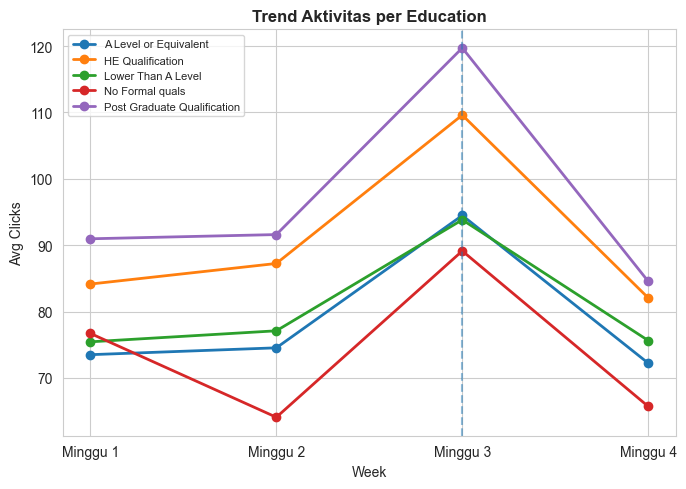

In [162]:
# EDUCATION

# Mengatur gaya visual untuk plot agar lebih rapi dan profesional
sns.set_style("whitegrid")

# Membuat figure dan axis baru dengan ukuran 7x5 inci
fig1, ax1 = plt.subplots(figsize=(7, 5))

# Loop melalui setiap tingkat pendidikan (highest_education) dalam pivot_edu
for edu in pivot_edu.index:
    '''
    # Plot trend aktivitas per minggu untuk setiap tingkat pendidikan
    # - x=[1,2,3,4]: minggu 1 hingga 4
    # - y=pivot_edu.loc[edu, [1,2,3,4]]: rata-rata jumlah klik untuk minggu 1-4
    # - marker='o': tambahkan titik bulat di setiap data point
    # - linewidth=2: ketebalan garis 2
    # - label=edu: label untuk legenda berdasarkan tingkat pendidikan
    '''
    ax1.plot(
        [1,2,3,4],
        pivot_edu.loc[edu, [1,2,3,4]],
        marker='o',
        linewidth=2,
        label=edu
    )

'''
# Menambahkan garis vertikal di minggu 3 sebagai pembatas antara periode awal dan akhir
# - linestyle="--": garis putus-putus
# - alpha=0.5: transparansi 50% agar tidak terlalu mencolok
'''
ax1.axvline(x=3, linestyle="--", alpha=0.5)

# Menambahkan judul plot dengan font tebal
ax1.set_title("Trend Aktivitas per Education", fontweight="bold")

# Menambahkan label sumbu x dan y
ax1.set_xlabel("Week")
ax1.set_ylabel("Avg Clicks")

# Mengatur label sumbu x menjadi 1,2,3,4
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(["Minggu 1", "Minggu 2", "Minggu 3", "Minggu 4"])

# Menambahkan legenda untuk mengidentifikasi setiap tingkat pendidikan
ax1.legend(fontsize=8)

# Menyesuaikan layout agar tidak ada elemen yang tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()

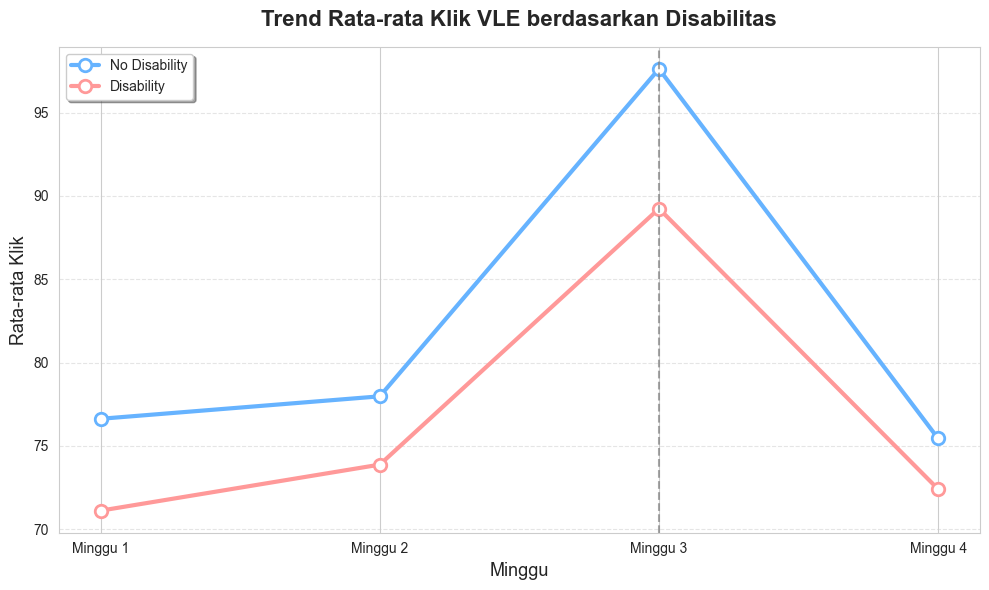

In [163]:
# Setup gaya seaborn untuk tampilan lebih modern
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6))

# Warna yang lebih jelas untuk membedakan kelompok
palette = {"N": "#66b3ff", "Y": "#ff9999"} # Biru untuk No Disability, Merah muda untuk Disability
# Jika index Anda bukan 'N'/'Y', sesuaikan dictionary ini

lines = []
for dis in pivot_dis.index:
    label = "No Disability" if dis == "N" else "Disability"
    color = palette.get(dis, "gray") # Default gray jika key tidak ditemukan
    
    # Plot dengan warna spesifik
    line, = ax.plot(
        [1, 2, 3, 4],
        pivot_dis.loc[dis, [1, 2, 3, 4]],
        marker='o',
        linewidth=3,
        markersize=9,
        label=label,
        color=color,
        markerfacecolor='white', # Agar titik terlihat jelas
        markeredgewidth=2,
        markeredgecolor=color
    )
    lines.append(line)

# Garis bantu di minggu ke-3
ax.axvline(x=3, linestyle="--", alpha=0.7, color='gray', linewidth=1.5)

# Konfigurasi Judul dan Label
ax.set_title("Trend Rata-rata Klik VLE berdasarkan Disabilitas", fontweight="bold", fontsize=16, pad=15)
ax.set_xlabel("Minggu", fontsize=13)
ax.set_ylabel("Rata-rata Klik", fontsize=13)

# Format Sumbu X
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Minggu 1", "Minggu 2", "Minggu 3", "Minggu 4"])

# Legend
ax.legend(loc="upper left", frameon=True, shadow=True)

# Grid minor untuk detail (opsional)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Insight**

**Hasil Analisis:** <br>
Kelompok demografi **`highest_education`** menunjukkan penurunan aktivitas interaksi VLE yang **paling drastis** dibandingkan dengan kelompok `disability`.

**Analisis Detail:**

1.  **Pola Penurunan pada `highest_education`:**
    *   Grafik menunjukkan adanya lonjakan aktivitas yang sangat tinggi pada **Minggu 3** untuk semua tingkat pendidikan.
    *   Setelah puncaknya di Minggu 3, terjadi **anjlok (drop) yang sangat curam** menuju Minggu 4.
    *   Jika kita melihat garis **`Post Graduate Qualification`** (ungu), penurunannya dari sekitar **120 klik (Minggu 3)** jatuh tajam ke **85 klik (Minggu 4)**. Ini adalah selisih absolut terbesar (~35 unit) yang terlihat di antara semua garis.
    *   Garis **`HE Qualification`** (oranye) juga menunjukkan pola serupa dengan penurunan drastis dari ~110 ke ~82.

2.  **Pola pada `disability`:**
    *   Grafik ini menunjukkan tren yang mirip (naik di Minggu 3, turun di Minggu 4), namun **besaran penurunannya lebih kecil**.
    *   Garis **`No Disability`** (biru) turun dari puncak ~98 ke ~75 (selisih ~23).
    *   Garis **`Disability`** (merah muda) turun dari puncak ~89 ke ~72 (selisih ~17).

**Kesimpulan:**
Meskipun kedua grafik menunjukkan pola "lonjakan di minggu ketiga lalu anjlok di minggu keempat", **tingkat pendidikan (`highest_education`)**—khususnya pada kategori pascasarjana dan sarjana—menunjukkan **kemiringan (slope) penurunan yang lebih curam** dan kehilangan jumlah klik absolut yang lebih besar pada akhir periode 4 minggu tersebut.

## 2.4 Insight

**Pertayaan 1:Berapa rata-rata jumlah klik (sum_click) mingguan pada 4 minggu pertama yang membedakan antara siswa yang lulus (Pass/Distinction) dengan siswa yang berisiko (Fail/Withdrawn)?**
<br>Jawaban:</br>
Perbedaan rata-rata jumlah klik mingguan yang membedakan kedua kelompok cukup signifikan. Siswa yang lulus (**Pass/Distinction**) secara konsisten lebih aktif berinteraksi dengan platform, dengan rata-rata **20-30 klik lebih banyak per minggu** dibandingkan siswa yang berisiko (**Fail/Withdrawn**). Secara keseluruhan, terdapat kesenjangan aktivitas sekitar **30 klik** antara median kedua kelompok.

**Pertayaan 2: Bagaimana korelasi antara selisih waktu pengumpulan tugas pertama (date_submitted vs date_deadline) dengan skor akhir yang diperoleh siswa?**
<br>Jawaban:</br>
Meskipun korelasinya lemah secara statistik ($r = -0.054$), keterlambatan pengumpulan tugas adalah indikator risiko yang penting.
1.  Prediktif Dini: Keterlambatan submit tugas pertama bisa menjadi *red flag* (tanda bahaya) awal bahwa siswa tersebut berpotensi mengalami kesulitan atau memiliki risiko gagal (Fallout/Withdrawn).
2.  Saran Intervensi: Sistem pembelajaran adaptif atau dosen sebaiknya memberikan peringatan dini atau bantuan khusus kepada siswa yang mulai menunda pengumpulan tugas (days_diff > 0), karena hal ini berkorelasi dengan penurunan performa akademik sekitar 6 poin dari rata-rata.

**Pertayaan 3: Kelompok demografi mana (highest_education atau disability) yang menunjukkan penurunan aktivitas interaksi VLE paling drastis selama 4 minggu pertama perkuliahan?**
<br>Jawaban:</br>
Kedua grafik menunjukkan pola "lonjakan di minggu ketiga lalu anjlok di minggu keempat", **tingkat pendidikan (`highest_education`)**—khususnya pada kategori pascasarjana dan sarjana—menunjukkan **kemiringan (slope) penurunan yang lebih curam** dan kehilangan jumlah klik absolut yang lebih besar pada akhir periode 4 minggu tersebut.


# 3. Rekayasa Fitur Lanjutan & Persiapan Modeling (Feature Engineering)

In [164]:
import pandas as pd
import numpy as np
from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_validate)

## 3.1. Agregasi Per Siswa & Trend Features

In [165]:
# RISK RATE (EDUCATION)
# Membaca data dari file CSV bernama "df_final.csv"
df_final = pd.read_csv("../data/Processed/df_final.csv")

# Cetak rata-rata risiko berdasarkan tingkat pendidikan tertinggi
# - df_final.groupby("highest_education")["risk_label"].mean(): menghitung rata-rata label risiko untuk setiap tingkat pendidikan
print("\nRisk rate by education:")
print(df_final.groupby("highest_education")["risk_label"].mean())


# RISK RATE (DISABILITY)
# Cetak rata-rata risiko berdasarkan status disabilitas
# - df_final.groupby("disability")["risk_label"].mean(): menghitung rata-rata label risiko untuk setiap status disabilitas
print("\nRisk rate by disability:")
print(df_final.groupby("disability")["risk_label"].mean())


Risk rate by education:
highest_education
A Level or Equivalent          0.410074
HE Qualification               0.369315
Lower Than A Level             0.539157
No Formal quals                0.630037
Post Graduate Qualification    0.307167
Name: risk_label, dtype: float64

Risk rate by disability:
disability
N    0.445046
Y    0.553087
Name: risk_label, dtype: float64


In [166]:
print("Loading data...")
# LOAD DATA
# Membaca data dari file CSV bernama "df_master_weekly_clean.csv"
# File ini berisi data mingguan yang telah dibersihkan
df = pd.read_csv("../data/processed/wrangled/df_master_weekly_clean.csv")

'''
Memfilter data agar hanya mengambil baris dengan kolom 'week' bernilai 1, 2, 3, atau 4
- df["week"].isin([1,2,3,4]): memilih hanya baris yang memiliki nilai 'week' dalam daftar [1,2,3,4]
- .copy(): membuat salinan dari dataframe agar perubahan tidak memengaruhi data asli
'''
df = df[df["week"].isin([1,2,3,4])].copy()

# Cetak informasi awal tentang jumlah baris dan kolom data
# - df.info(): menampilkan bentuk dataframe 
df.info()

Loading data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92088 entries, 0 to 92087
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         92088 non-null  int64  
 1   code_module        92088 non-null  object 
 2   code_presentation  92088 non-null  object 
 3   final_result       92088 non-null  object 
 4   highest_education  92088 non-null  object 
 5   disability         92088 non-null  object 
 6   gender             92088 non-null  object 
 7   age_band           92088 non-null  object 
 8   region             92088 non-null  object 
 9   week               92088 non-null  int64  
 10  total_clicks       92088 non-null  int64  
 11  days_diff          73187 non-null  float64
 12  score              73127 non-null  float64
 13  is_submitted       92088 non-null  int64  
 14  is_late            92088 non-null  int64  
 15  is_high_activity   92088 non-null  int64  
 16  risk_l

In [167]:
# AGREGASI PER STUDENT
# Mengelompokkan data berdasarkan mahasiswa, modul, dan presentasi
# Untuk setiap kelompok, dihitung beberapa metrik penting
df_student = df.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg(
    # Behavior utama (aktivitas penggunaan platform)
    avg_clicks=("total_clicks", "mean"),           # Rata-rata jumlah klik per mahasiswa
    total_clicks=("total_clicks", "sum"),          # Total jumlah klik per mahasiswa
    active_weeks=("week", "nunique"),              # Jumlah minggu aktif (unik)

    # Engagement (partisipasi dan keterlibatan)
    is_submitted=("is_submitted", "max"),          # Apakah mahasiswa pernah mengirimkan tugas
    is_late=("is_late", "max"),                    # Apakah mahasiswa pernah terlambat mengirimkan tugas

    # Target (label risiko)
    risk_label=("risk_label", "first"),            # Label risiko pertama (diasumsikan konsisten)

    # Demografi (informasi latar belakang mahasiswa)
    highest_education=("highest_education", "first"),  # Tingkat pendidikan tertinggi
    gender=("gender", "first"),                    # Jenis kelamin
    age_band=("age_band", "first"),                # Rentang usia
    disability=("disability", "first"),            # Status disabilitas
    region=("region", "first")                     # Wilayah asal
).reset_index()

# Cetak informasi tentang jumlah baris dan kolom setelah agregasi
print(f"After aggregation: {df_student.shape}")

'''
- .groupby(): mengelompokkan data berdasarkan kolom yang disebutkan
- .agg(): melakukan aggregasi pada beberapa kolom dengan fungsi yang berbeda
- .reset_index(): mengubah struktur data agar index berubah menjadi kolom biasa
- Setiap kolom hasil agregasi memiliki nama baru yang mencerminkan fungsi yang digunakan (misalnya avg_clicks, total_clicks, dll)
'''

After aggregation: (27795, 14)


'\n- .groupby(): mengelompokkan data berdasarkan kolom yang disebutkan\n- .agg(): melakukan aggregasi pada beberapa kolom dengan fungsi yang berbeda\n- .reset_index(): mengubah struktur data agar index berubah menjadi kolom biasa\n- Setiap kolom hasil agregasi memiliki nama baru yang mencerminkan fungsi yang digunakan (misalnya avg_clicks, total_clicks, dll)\n'

In [168]:
# FEATURE ENGINEERING (TREND)

print("Creating trend features...")

'''
Membuat pivot table untuk menarik data jumlah klik per minggu
- index: id_student, code_module, code_presentation (untuk mengelompokkan per mahasiswa, modul, presentasi)
- columns: week (1,2,3,4) sebagai kolom baru
- values: total_clicks (jumlah klik yang dijumlahkan)
- aggfunc="sum": menghitung total klik per minggu
'''
pivot = df.pivot_table(
    index=["id_student", "code_module", "code_presentation"],
    columns="week",
    values="total_clicks",
    aggfunc="sum"
).reset_index()

'''
Mengubah nama kolom agar lebih jelas
- Kolom dari pivot table diubah menjadi nama yang lebih deskriptif
- click_w1: jumlah klik pada minggu 1
- click_w4: jumlah klik pada minggu 4
'''
pivot.columns = ["id_student", "code_module", "code_presentation",
                 "click_w1", "click_w2", "click_w3", "click_w4"]

'''
Menggabungkan data pivot dengan df_student
- pd.merge(): menggabungkan dua dataframe berdasarkan key
- on=["id_student", "code_module", "code_presentation"]: kolom yang digunakan sebagai kunci penggabungan
- how="left": mempertahankan semua baris dari df_student
'''
df_model = pd.merge(
    df_student,
    pivot,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

# Membuat fitur trend berdasarkan perubahan aktivitas dari minggu 1 ke minggu 4
# - click_trend: selisih jumlah klik antara minggu 4 dan minggu 1
df_model["click_trend"] = df_model["click_w4"] - df_model["click_w1"]

'''
Membuat fitur tingkat pertumbuhan aktivitas
- click_growth_rate: persentase pertumbuhan jumlah klik dari minggu 1 ke minggu 4
- Menggunakan rumus: (click_w4 - click_w1) / (click_w1 + 1)
- +1 digunakan untuk mencegah pembagian dengan nol
'''
df_model["click_growth_rate"] = (
    (df_model["click_w4"] - df_model["click_w1"]) /
    (df_model["click_w1"] + 1)   # +1 biar tidak divide by zero
)

Creating trend features...


## 3.2. Encoding & Seleksi Fitur

In [169]:
# DROP POTENTIAL LEAKAGE FEATURE
'''
(score dan final_result memang tidak di ambil dari awal data, namun masih disertakan di dataset)
Penjelasan:
- Kolom 'score' dan 'final_result' sengaja tidak disertakan dalam dataset.
- Ini dilakukan untuk mencegah "data leakage", yaitu kebocoran informasi masa depan ke model prediktif.
- Jika memasukkan hasil akhir (score) saat melatih model, model tidak akan bisa memprediksi hasil yang baru di masa depan.
'''
# HANDLE MISSING
print("Handling missing values...")

'''
Mengisi nilai yang hilang (NaN) dengan 0
- df_model.fillna(0, inplace=True): mengganti semua nilai kosong dengan 0
- Ini adalah pendekatan sederhana, asumsi: nilai 0 berarti tidak ada aktivitas atau tidak ada data
'''
df_model.fillna(0, inplace=True)


# ENCODE CATEGORICAL
print("Encoding categorical features...")

# Daftar kolom kategorikal yang perlu di-encode
categorical_cols = [
    "highest_education", "gender",
    "age_band", "disability", "region"
]

'''
Mengubah kolom kategorikal menjadi kolom biner (One-Hot Encoding)
- pd.get_dummies(): membuat kolom baru untuk setiap kategori unik
- columns=categorical_cols: hanya kolom yang disebutkan yang akan di-encode
- drop_first=True: menghilangkan satu kolom kategori untuk menghindari multikolinearitas (dummy variable trap)
'''
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
'''
Membersihkan nama kolom agar lebih rapi dan konsisten
- Mengganti karakter khusus seperti "[", "]", "<", ">", " " dengan "_"
- Ini penting agar nama kolom bisa digunakan tanpa masalah di berbagai lingkungan pemrograman
'''
df_model.columns = (
    df_model.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

# Cetak daftar kolom setelah pembersihan
print("Columns after cleaning:")
print(df_model.columns.tolist())

Handling missing values...
Encoding categorical features...
Columns after cleaning:
['id_student', 'code_module', 'code_presentation', 'avg_clicks', 'total_clicks', 'active_weeks', 'is_submitted', 'is_late', 'risk_label', 'click_w1', 'click_w2', 'click_w3', 'click_w4', 'click_trend', 'click_growth_rate', 'highest_education_HE_Qualification', 'highest_education_Lower_Than_A_Level', 'highest_education_No_Formal_quals', 'highest_education_Post_Graduate_Qualification', 'gender_M', 'age_band_35-55', 'age_band_55_=', 'disability_Y', 'region_East_Midlands_Region', 'region_Ireland', 'region_London_Region', 'region_North_Region', 'region_North_Western_Region', 'region_Scotland', 'region_South_East_Region', 'region_South_Region', 'region_South_West_Region', 'region_Wales', 'region_West_Midlands_Region', 'region_Yorkshire_Region']


In [170]:
# Menyimpan dataframe ke file CSV
print("Menyimpan data df_model...")
# Membuat direktori jika belum ada
output_dir = "../data/processed/machineLearning"  # Direktori output
os.makedirs(output_dir, exist_ok=True)  # Membuat direktori jika belum ada
df_model.to_csv("../data/processed/machineLearning/df_model.csv", index=False) # menyimpan data tanpa index

print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/machineLearning/df_model.csv')}")


Menyimpan data df_model...

Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\machineLearning\df_model.csv


In [171]:
# pengecekan akhir (FINAL CHECK)

# Cetak spasi baru untuk memisahkan output di konsol agar lebih mudah dibaca
print("\nInfo akhir df_model:")

# Menampilkan ringkasan lengkap dataframe df_model (nama kolom, tipe data, non-null count)
# Catatan: Menggunakan .info() sebagai pengganti .shape sesuai instruksi
df_model.info()

# Menampilkan 5 baris pertama dari dataframe untuk melihat contoh data
print(df_model.head())

# Cetak spasi baru untuk pemisah visual
print("\nDistribusi Target:")

# Menghitung frekuensi kelas dari kolom "risk_label" dan menampilkannya dalam bentuk persentase (normalisasi)
# Ini berguna untuk melihat apakah data tidak seimbang (imbalanced class)
print(df_model["risk_label"].value_counts(normalize=True))


Info akhir df_model:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27795 entries, 0 to 27794
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   id_student                                     27795 non-null  int64  
 1   code_module                                    27795 non-null  object 
 2   code_presentation                              27795 non-null  object 
 3   avg_clicks                                     27795 non-null  float64
 4   total_clicks                                   27795 non-null  int64  
 5   active_weeks                                   27795 non-null  int64  
 6   is_submitted                                   27795 non-null  int64  
 7   is_late                                        27795 non-null  int64  
 8   risk_label                                     27795 non-null  int64  
 9   click_w1                    

In [172]:
# Menyimpan dataframe ke file CSV
print("Menyimpan data df_model...")
# Membuat direktori jika belum ada
output_dir = "../data/processed/machineLearning"  # Direktori output
os.makedirs(output_dir, exist_ok=True)  # Membuat direktori jika belum ada
df_model.to_csv("../data/processed/machineLearning/df_model.csv", index=False) # menyimpan data tanpa index

print("\nSelesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/machineLearning/df_model.csv')}")

Menyimpan data df_model...

Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\machineLearning\df_model.csv


## 3.3. Split Data & Handling Imbalance

In [173]:
# Membaca file CSV yang sudah diproses ke dalam DataFrame pandas
df = pd.read_csv("../data/processed/machineLearning/df_model.csv")

'''
Membuat variabel fitur (X) dengan menghapus kolom yang tidak diperlukan untuk prediksi:
- 'risk_label': Ini adalah target yang ingin diprediksi
- 'id_student', 'code_module', 'code_presentation': Identifiers/kode yang tidak memiliki nilai prediktif langsung
'''
X = df.drop(columns=["risk_label", "id_student", "code_module", "code_presentation"])

# Membuat variabel target (y) yang berisi kolom 'risk_label' (kelas risiko siswa)
y = df["risk_label"]

'''
Membagi data menjadi data latih (train) dan data uji (test)
- test_size=0.2: 20% data digunakan untuk pengujian, 80% untuk pelatihan
- random_state=42: Memastikan hasil pembagian bisa direproduksi (konsisten setiap kali dijalankan)
- stratify=y: Mempertahankan proporsi kelas 'risk_label' yang sama di data latih dan uji (penting untuk data tidak seimbang)
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Menampilkan ukuran data latih (X_train) dan label latih (y_train)
print(f"X_train.shape: {X_train.shape}")
# Menampilkan garis horizontal dengan panjang 27 karakter
print("="*27)
# Menampilkan ukuran data uji (X_test) dan label uji (y_test)
print(f"X_test.shape: {X_test.shape}")

X_train.shape: (22236, 31)
X_test.shape: (5559, 31)


## 3.4 Insight 

1. Insight Demografi (Sangat Kritis)
Data mentah mengungkap pola risiko yang sangat jelas yang akan sangat membantu model:
*   **Pendidikan:**
    *   **Risiko Tertinggi:** Siswa **tanpa kualifikasi formal** (*No Formal quals*) memiliki tingkat kegagalan **63%**.
    *   **Risiko Terendah:** Siswa dengan kualifikasi **Pascasarjana** (*Post Graduate*) hanya memiliki risiko **~30%**.
    *   *Implikasi:* Fitur ini akan menjadi prediktor yang sangat kuat. Model akan belajar bahwa latar belakang pendidikan rendah berkorelasi tinggi dengan kegagalan.
*   **Disabilitas:**
    *   Siswa dengan disabilitas (**Y**) memiliki risiko **55.3%**, jauh lebih tinggi dibandingkan mereka tanpa disabilitas (**44.5%**).

2. Transformasi Data (Aggregasi)
*   **Kompresi Data:** Data berhasil dikompresi dari **92.088 baris** (data per minggu/klik) menjadi **27.795 baris** (satu baris per siswa per modul). Ini adalah format yang benar untuk klasifikasi.
*   **Fitur Rekayasa (Feature Engineering):**
    *   Anda berhasil membuat fitur temporal yang krusial: `click_w1`, `click_w2`, `click_w3`, `click_w4`.
    *   Fitur turunan **`click_trend`** dan **`click_growth_rate`** juga berhasil dibuat. Ini sangat penting untuk mendeteksi pola "penurunan aktivitas" atau "kelelahan siswa" yang sering terjadi di minggu-minggu akhir.
*   **Encoding:** Semua data kategorikal (Pendidikan, Region, Gender, dll) telah diubah menjadi format **One-Hot Encoding** (kolom Boolean `True`/`False`). Total kolom menjadi **35 fitur**.

3. Kualitas Data untuk Training
*   **Keseimbangan Kelas (Class Balance):**
    *   **Label 0 (Aman):** 54.5%
    *   **Label 1 (Risiko):** 45.5%
    *   **Analisis:** Ini adalah kondisi **sangat ideal**. Data hampir seimbang (hampir 50:50). Anda **tidak perlu** melakukan teknik *oversampling* (SMOTE) atau *undersampling* yang agresif. Model akan belajar dengan adil tanpa bias berat ke satu kelas.
*   **Ketersediaan Data:**
    *   Semua kolom di `df_model` sudah **clean** (tidak ada nilai null).
    *   Ukuran file menjadi ringan (**3.7 MB**) karena efisiensi tipe data (banyak kolom `bool` dan `int`).

4. Rekomendasi Langkah Berikutnya
Data `df_model` sudah **siap 100%** untuk *Machine Learning*.
1.  **Split Data:** Gunakan `train_test_split` dengan `stratify=y` untuk mempertahankan rasio 54:45 di data latih dan uji.
2.  **Baseline Model:** Karena data seimbang, model seperti **Random Forest** atau **Logistic Regression** akan memberikan hasil *baseline* yang sangat baik.
3.  **Evaluasi Fitur:** Perhatikan *Feature Importance* nanti. Kemungkinan besar `highest_education` dan `is_late` akan menjadi fitur teratas, tetapi coba lihat apakah `click_growth_rate` bisa meningkatkan akurasi model secara signifikan.

# 4. Machine Learning Modeling

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import(
    RandomForestClassifier, 
GradientBoostingClassifier)

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    roc_auc_score, 
    roc_curve
)
import joblib
import numpy as np

## 4.1. Definisi Model & Cross-Validation

In [175]:
# MEMBACA DATA (LOAD DATA)

# Membaca file CSV yang berada di direktori saat ini ke dalam DataFrame pandas
# File: df_model.csv
df = pd.read_csv("../data/processed/machineLearning/df_model.csv")

'''
# Membuat variabel fitur (X) dengan menghapus kolom yang tidak digunakan untuk model prediksi:
# - 'risk_label': Kolom target yang ingin diprediksi
# - 'id_student', 'code_module', 'code_presentation': Kolom identifikasi yang tidak berkontribusi pada prediksi
'''
X = df.drop(columns=["risk_label", "id_student", "code_module", "code_presentation"])

# Mengambil kolom target (y) yang berisi label risiko siswa
y = df["risk_label"]

# Menampilkan informasi lengkap tentang fitur (X) sebagai ganti dari .shape yang sebelumnya digunakan
# .info() menampilkan detail seperti jumlah baris, jumlah kolom, tipe data setiap kolom, dan jumlah non-null
print("Informasi X (Fitur):")
X.info()
'''
# Menampilkan distribusi target (y) dalam bentuk persentase
# value_counts(normalize=True) menghitung frekuensi kelas dan mengonversinya menjadi proporsi
# .round(3) membulatkan nilai ke 3 angka desimal untuk kemudahan baca
'''
print(f"Distribusi Target:\n{y.value_counts(normalize=True).round(3)}")

Informasi X (Fitur):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27795 entries, 0 to 27794
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   avg_clicks                                     27795 non-null  float64
 1   total_clicks                                   27795 non-null  int64  
 2   active_weeks                                   27795 non-null  int64  
 3   is_submitted                                   27795 non-null  int64  
 4   is_late                                        27795 non-null  int64  
 5   click_w1                                       27795 non-null  float64
 6   click_w2                                       27795 non-null  float64
 7   click_w3                                       27795 non-null  float64
 8   click_w4                                       27795 non-null  float64
 9   click_trend                  

In [176]:
'''
MEMISAHKAN DATA LATIH DAN DATA UJI (TRAIN TEST SPLIT)
Membagi data fitur (X) dan target (y) menjadi dua set: data latih (train) dan data uji (test)
Fungsi train_test_split dari library scikit-learn digunakan untuk pembagian ini
'''
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Data fitur (variabel independen)
    y,              # Data target (variabel dependen)
    test_size=0.2,  # Mengambil 20% data untuk pengujian, sisanya 80% untuk pelatihan
    random_state=42, # Mengunci seed generator acak agar hasil pembagian selalu sama setiap kali dijalankan (reproduktif)
    stratify=y      # Melakukan stratifikasi berdasarkan target (y) agar proporsi kelas 'risk_label' tetap sama di data latih dan uji
)

print(f"X_train.shape: {X_train.shape}")
print("="*27)
print(f"X_test.shape: {X_test.shape}")

X_train.shape: (22236, 31)
X_test.shape: (5559, 31)


In [ ]:
# BOBOT SAMPEL (UNTUK MODEL GBM - Gradient Boosting Machine)

'''
Menghitung bobot sampel untuk menangani ketidakseimbangan kelas (imbalanced classes) pada data latih
Fungsi compute_sample_weight dari scikit-learn digunakan dengan parameter "balanced"
Ini akan memberikan bobot lebih tinggi pada kelas yang jarang muncul dan bobot lebih rendah pada kelas yang dominan
Tujuannya agar model GBM lebih memperhatikan kelas minoritas saat proses pelatihan
'''
sample_weights = compute_sample_weight("balanced", y_train)

#  melihat distribusi kelas sebelum dan setelah pemberian bobot
print("Distribusi kelas asli:")
print(y_train.value_counts())
print("\nBobot sampel yang dihitung:")
print(sample_weights)

Distribusi kelas asli:
risk_label
0    12110
1    10126
Name: count, dtype: int64

Bobot sampel yang dihitung:
[0.91808423 0.91808423 0.91808423 ... 0.91808423 0.91808423 0.91808423]


In [178]:
# SKALA BOBOT POSITIF (UNTUK MODEL XGBOOST)
'''
Menghitung rasio antara jumlah sampel kelas negatif (0) dan kelas positif (1)
(y_train == 0).sum() menghitung berapa banyak baris di mana target bernilai 0 (Kelas Mayoritas/Negatif)
(y_train == 1).sum() menghitung berapa banyak baris di mana target bernilai 1 (Kelas Minoritas/Positif)
Hasil pembagian ini akan menjadi bobot (weight) untuk kelas positif di model XGBoost
Tujuannya: Memberikan penalti lebih besar jika model salah memprediksi kelas minoritas (kasus 1),
sehingga model lebih sensitif terhadap deteksi risiko.
'''
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# melihat hasil perhitungan rasio 
print(f"Rasio bobot positif: {ratio}")

Rasio bobot positif: 1.1959312660477976


Membuat kamus (dictionary) bernama `Model` yang menyimpan 4 jenis model machine learning berbeda
Setiap model dikonfigurasi khusus untuk menangani masalah klasifikasi risiko siswa

In [179]:
models = {
    # 1. REGRESI LOGISTIK (Logistic Regression)
    # Menggunakan Pipeline agar skalasi fitur dilakukan otomatis sebelum prediksi
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),          # Menstandarisasi fitur (mean=0, var=1) agar konvergensi lebih cepat
        ("clf", LogisticRegression(
            class_weight="balanced",           # Memberikan bobot otomatis untuk menyeimbangkan kelas (minoritas diberi bobot lebih)
            max_iter=1000,                     # Maksimal iterasi optimasi (dinaikkan agar konvergen)
            random_state=42                    # Kunci acak agar hasil konsisten
        ))
    ]),
    # 2. RANDOM FOREST
    # Model ensemble berbasis pohon keputusan yang mengurangi overfitting dengan averaging
    "Random Forest": RandomForestClassifier(
        n_estimators=200,          # Jumlah pohon keputusan dalam hutan
        max_depth=10,              # Kedalaman maksimal setiap pohon (mencegah pohon terlalu kompleks)
        min_samples_leaf=10,       # Minimal sampel di daun/pucuk pohon (meningkatkan generalisasi)
        class_weight="balanced",   # Menyeimbangkan pengaruh kelas yang tidak seimbang
        random_state=42,           # Kunci acak untuk reproduktibilitas
        n_jobs=-1                  # Menggunakan semua inti CPU untuk mempercepat proses
    ),

    # 3. GRADIENT BOOSTING (BERAT)
    # Model ensemble yang membangun pohon secara berurutan (satu per satu) untuk memperbaiki kesalahan sebelumnya
    "Gradient Boosting (Weighted)": GradientBoostingClassifier(
        n_estimators=200,          # Jumlah pohon bertahap
        max_depth=4,               # Kedalaman pohon yang dangkal (biasanya efektif untuk boosting)
        learning_rate=0.05,        # Kecepatan pembelajaran (nilai kecil = belajar perlahan tapi stabil)
        random_state=42            # Kunci acak
        # Catatan: Tidak menggunakan class_weight di sini, mungkin mengandalkan strategi lain atau asumsi data
    ),

    # 4. XGBOOST
    # Implementasi Gradient Boosting yang sangat cepat dan efisien, populer dalam kompetisi data science
    "XGBoost": XGBClassifier(
        n_estimators=200,          # Jumlah boosting rounds (pohon)
        max_depth=4,               # Kedalaman maksimal pohon
        learning_rate=0.05,        # Learning rate
        scale_pos_weight=ratio,    # Bobot khusus untuk kelas positif (menggunakan variabel 'ratio' yang dihitung sebelumnya)
                                   # Ini adalah cara XGBoost menangani data tidak seimbang
        random_state=42,           # Kunci acak
        eval_metric="auc",         # Metrik evaluasi yang digunakan selama pelatihan (Area Under Curve)
        n_jobs=-1                  # Menggunakan semua inti CPU
    )
}

In [180]:
# VALIDASI SILANG (CROSS VALIDATION)
'''
# Membuat objek StratifiedKFold untuk validasi silang dengan 5 lipatan (folds)
# - n_splits=5: Data dibagi menjadi 5 bagian, satu bagian jadi validasi, empat bagian jadi latih (diulang 5x)
# - shuffle=True: Data diacak sebelum dibagi agar lipatan lebih representatif
# - random_state=42: Memastikan pengacakan konsisten setiap kali dijalankan
'''
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mencetak judul bagian untuk output konsol
print("\n=== CROSS VALIDATION (ROC-AUC) ===")
cv_results = {} 
# Memloopi setiap model yang ada dalam kamus 'models'
# name = nama model (string), model = objek model itu sendiri
for name, model in models.items():
    # List kosong untuk menyimpan skor AUC dari setiap lipatan
    auc_scores = []
    '''
    # Mem-looping setiap lipatan (fold) dari validasi silang
    # cv.split(X_train, y_train) menghasilkan indeks untuk data latih dan validasi di setiap lipatan
    # fold = nomor lipatan (0-4), train_idx = indeks latih, val_idx = indeks validasi
    '''
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        # Memisahkan data latih dan validasi berdasarkan indeks yang dihasilkan
        # .iloc digunakan untuk selecting baris berdasarkan posisi indeks
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Kondisi khusus: Jika nama model mengandung "Gradient Boosting"
        # Maka hitung bobot sampel (sample weights) untuk menangani ketidakseimbangan kelas
        if "Gradient Boosting" in name:
            sw = compute_sample_weight("balanced", y_tr)
            # Melatih model dengan parameter sample_weight
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            # Untuk model lain (Logistic, Random Forest, XGBoost), latih tanpa sample_weight eksplisit
            # (Catatan: Random Forest dan Logistic sudah punya class_weight="balanced" di definisi sebelumnya)
            model.fit(X_tr, y_tr)

        # Memprediksi probabilitas kelas positif (index 1) pada data validasi
        # .predict_proba() mengembalikan array probabilitas untuk semua kelas, [:, 1] mengambil kolom kelas 1
        y_prob_val = model.predict_proba(X_val)[:, 1]
        
        # Menghitung skor AUC (Area Under Curve) untuk membandingkan prediksi probabilitas dengan label asli
        auc = roc_auc_score(y_val, y_prob_val)
        auc_scores.append(auc)  # Menyimpan skor AUC lipatan ini ke dalam list

    # Menghitung rata-rata dan standar deviasi dari 5 skor AUC yang didapat
    mean_auc = np.mean(auc_scores)
    std_auc  = np.std(auc_scores)
    '''
    Menyimpan dan mencetak hasil untuk model tersebut dengan format yang rapi
    {name:30s} memastikan nama model menempati 30 karakter agar kolom rapi
    {mean_auc:.4f} mencetak rata-rata AUC dengan 4 angka desimal
    {std_auc:.4f} mencetak standar deviasi dengan 4 angka desimal
    '''
    cv_results[name] = {
        "mean": mean_auc,
        "std": std_auc,
        "scores": auc_scores
    }
    print(f"{name:30s} | AUC: {mean_auc:.4f} ± {std_auc:.4f}")


=== CROSS VALIDATION (ROC-AUC) ===
Logistic Regression            | AUC: 0.7098 ± 0.0043
Random Forest                  | AUC: 0.7164 ± 0.0059
Gradient Boosting (Weighted)   | AUC: 0.7199 ± 0.0067
XGBoost                        | AUC: 0.7205 ± 0.0058


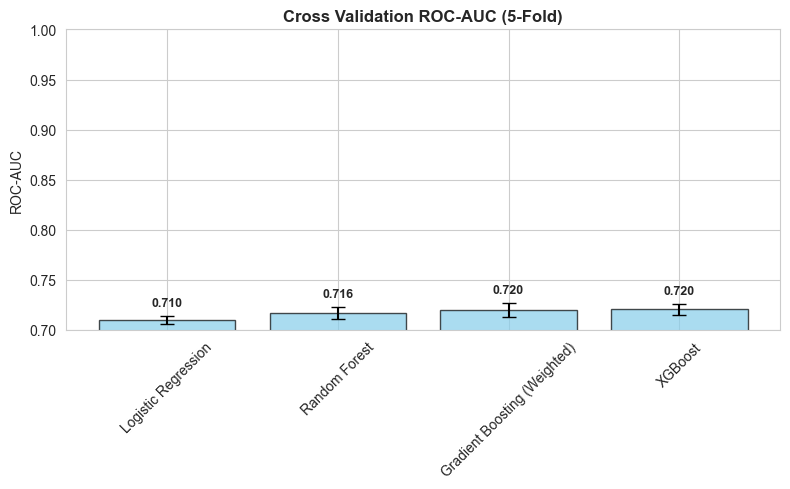

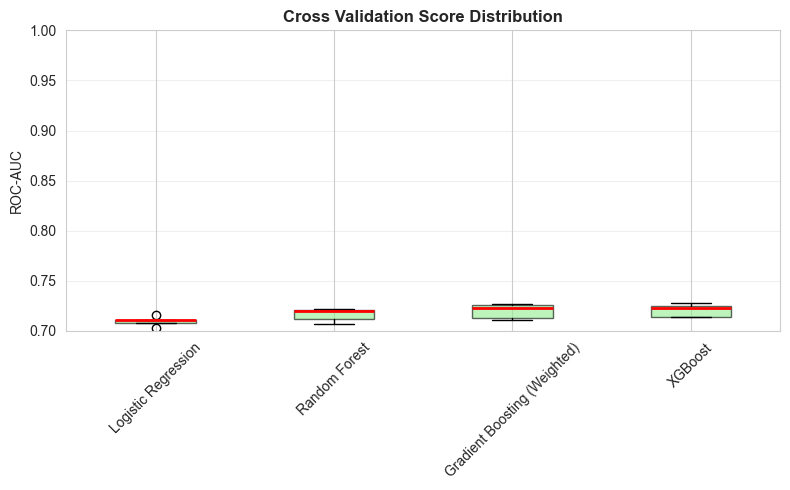

In [181]:
# DIAGRAM BATANG CV (CV BARPLOT)

# Membuat figure dan axis untuk plot diagram batang dengan ukuran 8x5 inci
fig1, ax1 = plt.subplots(figsize=(8, 5))

# Mengambil daftar nama model dari kamus cv_results
names = list(cv_results.keys())

# Membuat list rata-rata skor (mean) untuk setiap model
means = [cv_results[n] ["mean"] for n in names]

# Membuat list standar deviasi (std) untuk setiap model (digunakan sebagai error bar)
stds = [cv_results[n] ["std"] for n in names]
 
'''
# Membuat diagram batang:
# - x: nama model, y: rata-rata skor
# - yerr=stds: menambahkan error bar yang menunjukkan standar deviasi
# - capsize=5: memberikan garis horizontal di ujung error bar agar lebih jelas
# - alpha=0.7: transparansi 70% agar tidak terlalu pekat
# - color="skyblue": warna batang biru langit
# - edgecolor="black": garis tepi hitam agar batang lebih tegas
'''
bars = ax1.bar(names, means, yerr=stds, capsize=5, alpha=0.7, color="skyblue", edgecolor="black")

# Menyiapkan judul dan label sumbu
ax1.set_title("Cross Validation ROC-AUC (5-Fold)", fontweight="bold")
ax1.set_ylabel("ROC-AUC")

# Mengatur batas bawah sumbu Y agar fokus pada rentang skor yang relevan (0.7 hingga 1.0)
# Ini membuat perbedaan antar model lebih terlihat jelas
ax1.set_ylim(0.7, 1.0)

# Memutar label sumbu X sebesar 45 derajat agar nama model tidak bertumpuk dan mudah dibaca
ax1.tick_params(axis='x', rotation=45)

# Menambahkan teks (nilai rata-rata) di atas setiap batang dan error bar
# Loop ini berjalan untuk setiap model (i) dengan rata-rata (m) dan standar deviasi (s)
for i, (m, s) in enumerate(zip(means, stds)):
    # Menempatkan teks di posisi Y = rata-rata + standar deviasi + sedikit jarak (0.01)
    # ha='center': teks rata tengah terhadap batang
    # fontsize=9, fontweight="bold": ukuran dan ketebalan teks
    ax1.text(i, m + s + 0.01, f"{m:.3f}", ha='center', fontsize=9, fontweight="bold")

# Menata layout agar elemen tidak terpotong (misalnya label miring di bawah)
plt.tight_layout()

# Menampilkan plot
plt.show()

# DIAGRAM KOTAK CV (CV BOXPLOT)

# Membuat figure dan axis baru untuk plot diagram kotak (boxplot)
fig2, ax2 = plt.subplots(figsize=(8, 5))

# Membangun DataFrame dari cv_results dan mentransposenya (baris jadi kolom, kolom jadi baris)
# Ini memudahkan akses data skor per model
cv_data = pd.DataFrame(cv_results).T

# Mengambil daftar skor individual (bukan hanya rata-rata) dari setiap model untuk digambar sebagai boxplot
# Ini menunjukkan distribusi sebaran skor di setiap lipatan (fold)
cv_scores_list = [cv_results[n] ["scores"] for n in names]

'''
Membuat diagram kotak (boxplot):
- data: daftar skor per model
- labels: nama model di sumbu X
- patch_artist=True: mengisi warna pada kotak
- boxprops: mengatur warna kotak menjadi hijau muda dengan transparansi
- medianprops: mengatur warna garis median (tengah kotak) menjadi merah dan tebal
'''
ax2.boxplot(cv_scores_list, labels=names, patch_artist=True,
            boxprops=dict(facecolor="lightgreen", alpha=0.6),
            medianprops=dict(color="red", linewidth=2))

# Menyiapkan judul dan label sumbu
ax2.set_title("Cross Validation Score Distribution", fontweight="bold")
ax2.set_ylabel("ROC-AUC")

# Mengatur batas Y sama seperti plot batang sebelumnya untuk konsistensi
ax2.set_ylim(0.7, 1.0)

# Memutar label sumbu X agar mudah dibaca
ax2.tick_params(axis='x', rotation=45)

# Menambahkan garis grid horizontal tipis untuk memudahkan pembacaan nilai
ax2.grid(axis='y', alpha=0.3)

# Menata layout
plt.tight_layout()

# Menampilkan plot
plt.show()

## 4.2. Evaluasi Test Set & Threshold Tuning

In [182]:
# EVALUASI DATA UJI (TEST SET EVALUATION)

# Mencetak judul bagian untuk output konsol
print("\n=== TEST SET EVALUATION ===")

# Membuat kamus kosong untuk menyimpan hasil evaluasi setiap model
test_results = {}

# MemLoopi setiap model dalam kamus 'models'
for name, model in models.items():
    '''
    Kondisi khusus untuk model Gradient Boosting
    Menggunakan bobot sampel (sample_weights) yang sudah dihitung sebelumnya
    ini penting karena GradientBoostingClassifier tidak punya parameter class_weight otomatis
    '''
    if "Gradient Boosting" in name:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        # Model lain (Logistic, Random Forest, XGBoost) sudah dikonfigurasi dengan class_weight 
        # atau scale_pos_weight di definisi sebelumnya, jadi cukup fit biasa
        model.fit(X_train, y_train)

    # Membuat prediksi probabilitas untuk kelas positif (1) pada data uji
    # [:, 1] mengambil kolom probabilitas kelas 1
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Mengonversi probabilitas menjadi label biner (0 atau 1)
    # Jika probabilitas >= 0.5, maka diprediksi sebagai 1 (Risiko), selain itu 0
    y_pred = (y_prob >= 0.5).astype(int)

    # Menghitung skor ROC-AUC untuk mengukur kemampuan model membedakan kelas
    auc = roc_auc_score(y_test, y_prob)
    
    # Menghasilkan laporan klasifikasi lengkap (Precision, Recall, F1-Score)
    # output_dict=True agar hasilnya bisa disimpan sebagai dictionary untuk analisis lebih lanjut
    report = classification_report(y_test, y_pred, output_dict=True)

    # Menyimpan hasil evaluasi kunci ke dalam kamus test_results
    test_results[name] = {
        "auc": auc,                 # Skor AUC
        "y_prob": y_prob,           # Probabilitas prediksi (untuk plot kurva nanti jika perlu)
        "y_pred": y_pred,           # Label prediksi biner
        "recall_1": report["1"] ["recall"],          # Recall khusus kelas 1 (sensitivitas deteksi risiko)
        "precision_1": report["1"] ["precision"],    # Presisi khusus kelas 1
        "f1_macro": report["macro avg"] ["f1-score"] # Rata-rata F1 dari semua kelas (unweighted)
    }

    # Mencetak ringkasan hasil untuk model saat ini ke konsol
    print(f"\n--- {name} ---")
    print(f"ROC-AUC: {auc:.4f}")
    # Mencetak laporan klasifikasi lengkap dalam format tabel teks
    print(classification_report(y_test, y_pred))


=== TEST SET EVALUATION ===

--- Logistic Regression ---
ROC-AUC: 0.7118
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      3028
           1       0.63      0.63      0.63      2531

    accuracy                           0.66      5559
   macro avg       0.66      0.66      0.66      5559
weighted avg       0.66      0.66      0.66      5559


--- Random Forest ---
ROC-AUC: 0.7159
              precision    recall  f1-score   support

           0       0.68      0.68      0.68      3028
           1       0.62      0.62      0.62      2531

    accuracy                           0.65      5559
   macro avg       0.65      0.65      0.65      5559
weighted avg       0.65      0.65      0.65      5559


--- Gradient Boosting (Weighted) ---
ROC-AUC: 0.7212
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      3028
           1       0.63      0.63      0.63      2531

    accuracy   

In [183]:
# PENYESUAIAN AMBANG BATAS (THRESHOLD TUNING)
# Mencari nama model yang memiliki skor ROC-AUC tertinggi dari hasil evaluasi data uji sebelumnya
# max() mencari kunci (nama model) dengan nilai 'auc' terbesar
best_name = max(test_results, key=lambda k: test_results[k] ["auc"])

# Mengambil probabilitas prediksi dari model terbaik tersebut untuk proses tuning
best_prob = test_results[best_name] ["y_prob"]

# Mencetak judul dengan nama model terbaik
print(f"\n=== THRESHOLD TUNING ({best_name}) ===")
'''
Membuat rentang nilai ambang batas (threshold) untuk dicoba
np.arange(0.3, 0.7, 0.05) menghasilkan array: [0.30, 0.35, ..., 0.65]
Rentang ini dipilih karena biasanya probabilitas risiko berada di area ini
'''
thresholds = np.arange(0.3, 0.7, 0.05)

# List kosong untuk menyimpan hasil metrik pada setiap threshold
results = []

# MemLoopi setiap threshold yang ditentukan
for t in thresholds:
    # Mengonversi probabilitas menjadi label biner menggunakan threshold saat ini (t)
    # Jika probabilitas >= t, maka prediksi 1, selain itu 0
    y_pred_t = (best_prob >= t).astype(int)
    
    # Menghitung laporan klasifikasi lengkap untuk threshold ini
    # output_dict=True agar bisa mengambil nilai spesifik (recall, precision) secara programatis
    report = classification_report(y_test, y_pred_t, output_dict=True)

    # Menyimpan hasil metrik kunci ke dalam list
    results.append({
        "threshold": t,
        "recall_1": report["1"] ["recall"],       # Kemampuan mendeteksi kelas 1 (penting untuk risiko)
        "precision_1": report["1"] ["precision"], # Akurasi prediksi kelas 1
        "f1_macro": report["macro avg"] ["f1-score"] # Keseimbangan umum F1-score
    })

# Mengubah list hasil menjadi DataFrame pandas agar mudah dianalisis dan dicetak
thresh_df = pd.DataFrame(results)

# Mencetak tabel hasil tuning threshold
print(thresh_df)

'''
Menemukan threshold yang menghasilkan F1-Macro tertinggi
.idxmax() mencari indeks baris dengan nilai maksimum pada kolom "f1_macro"
.loc[...] mengambil nilai threshold pada baris tersebut
'''
best_thresh = thresh_df.loc[thresh_df["f1_macro"].idxmax(), "threshold"]

# Mencetak threshold terbaik yang ditemukan
print(f"\nBest threshold: {best_thresh}")


=== THRESHOLD TUNING (Gradient Boosting (Weighted)) ===
   threshold  recall_1  precision_1  f1_macro
0       0.30  0.907546     0.514100  0.536250
1       0.35  0.846306     0.539819  0.589819
2       0.40  0.781114     0.569741  0.629426
3       0.45  0.698538     0.591107  0.642726
4       0.50  0.625444     0.625939  0.656524
5       0.55  0.544844     0.668768  0.659626
6       0.60  0.460292     0.706917  0.645542
7       0.65  0.369024     0.744817  0.616053

Best threshold: 0.5499999999999999


In [184]:
# EVALUASI DAN RINGKASAN FINAL
# Mencetak judul bagian ringkasan
print("\n=== RINGKASAN PERBANDINGAN MODEL ===")

# Membuat DataFrame ringkasan dari hasil evaluasi semua model (test_results)
# Struktur data diubah agar Baris = Model, Kolom = Metrik
summary = pd.DataFrame({
    name: {
        "ROC-AUC"     : round(res["auc"], 4),           # Skor AUC dibulatkan 4 desimal
        "F1 Macro"    : round(res["f1_macro"], 4),      # Skor F1 Macro rata-rata
        "Recall (1)"  : round(res["recall_1"], 4),      # Kemampuan mendeteksi kelas 1 (Risiko)
        "Precision (1)": round(res["precision_1"], 4)   # Akurasi prediksi kelas 1
    }
    for name, res in test_results.items()
}).T  # .T mentranspos agar model menjadi baris

# Mencetak tabel ringkasan yang sudah diurutkan berdasarkan skor ROC-AUC dari tertinggi ke terendah
# .to_string() memastikan semua baris dicetak lengkap di konsol (tidak dipotong)
print(summary.sort_values("ROC-AUC", ascending=False).to_string())

# Mencetak nama model terbaik berdasarkan skor AUC tertinggi
print(f"\nModel terbaik: {best_name} (AUC={test_results[best_name] ['auc']:.4f})")

# Mencetak nilai ambang batas (threshold) optimal yang ditemukan sebelumnya
print(f"Optimal threshold: {best_thresh}")


=== RINGKASAN PERBANDINGAN MODEL ===
                              ROC-AUC  F1 Macro  Recall (1)  Precision (1)
Gradient Boosting (Weighted)   0.7212    0.6565      0.6254         0.6259
XGBoost                        0.7204    0.6591      0.6250         0.6298
Random Forest                  0.7159    0.6473      0.6160         0.6157
Logistic Regression            0.7118    0.6590      0.6326         0.6271

Model terbaik: Gradient Boosting (Weighted) (AUC=0.7212)
Optimal threshold: 0.5499999999999999


## 4.3. Evaluasi Final & Interpretasi

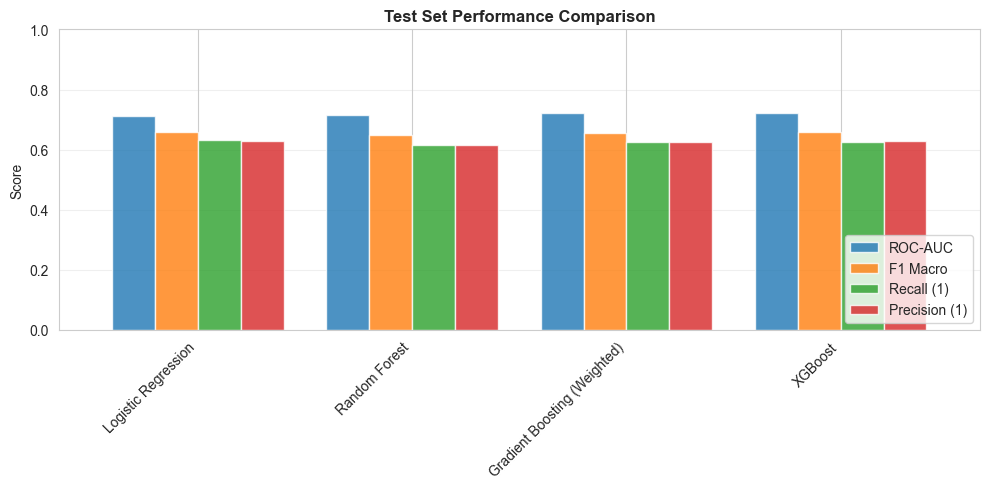

In [185]:
# VISUALISASI 3: PERBANDINGAN BATANG TEST (TEST COMPARISON BARPLOT)
# Membuat figure dan axis baru untuk plot perbandingan
fig3, ax3 = plt.subplots(figsize=(10, 5))
'''
Membangun DataFrame baru dari hasil test_results
Tujuannya: Mengubah struktur data dari dictionary of dicts menjadi DataFrame agar mudah diplot
Baris = Model, Kolom = Metrik (ROC-AUC, F1 Macro, Recall, Precision)
'''
metrics_df = pd.DataFrame({
    name: {
        "ROC-AUC": res["auc"],
        "F1 Macro": res["f1_macro"],
        "Recall (1)": res["recall_1"],
        "Precision (1)": res["precision_1"]
    }
    for name, res in test_results.items()
}).T  # .T mentranspos DataFrame agar model jadi baris dan metrik jadi kolom (format standar plot pandas)

'''
Menggambar diagram batang menggunakan fitur bawaan pandas DataFrame.plot
kind='bar': diagram batang vertikal
width=0.8: lebar batang
alpha=0.8: transparansi
'''
metrics_df.plot(kind='bar', ax=ax3, width=0.8, alpha=0.8)

# Mengatur judul dan label sumbu
ax3.set_title("Test Set Performance Comparison", fontweight="bold")
ax3.set_ylabel("Score")

# Mengatur batas Y dari 0 hingga 1.0 karena semua metrik ini berada di rentang tersebut
ax3.set_ylim(0, 1.0)

# Memutar label sumbu X (nama model) 45 derajat ke kanan agar tidak bertumpuk
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

# Menambahkan legenda di pojok kanan bawah
ax3.legend(loc='lower right')

# Menambahkan grid horizontal tipis untuk memudahkan pembacaan nilai
ax3.grid(axis='y', alpha=0.3)

# Menata layout agar rapi
plt.tight_layout()

# Menampilkan plot
plt.show()

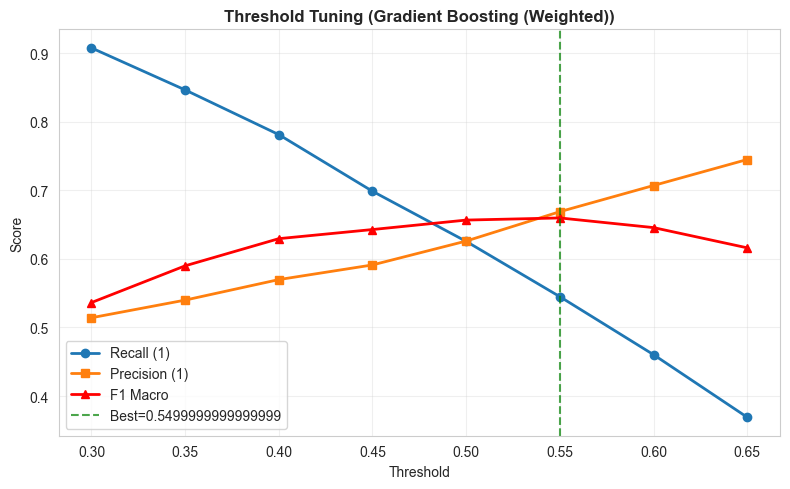

In [186]:
# KURVA PENYESUAIAN THRESHOLD (THRESHOLD TUNING CURVES)
# Membuat figure dan axis baru untuk plot kurva
fig4, ax4 = plt.subplots(figsize=(8, 5))

# Menggambar garis untuk Recall (Kelas 1)
# marker='o': titik bulat, label untuk legenda, linewidth=2 agar tebal
ax4.plot(thresh_df["threshold"], thresh_df["recall_1"], marker='o', label="Recall (1)", linewidth=2)

# Menggambar garis untuk Precision (Kelas 1)
# marker='s': titik kotak
ax4.plot(thresh_df["threshold"], thresh_df["precision_1"], marker='s', label="Precision (1)", linewidth=2)

# Menggambar garis untuk F1 Macro
# marker='^': titik segitiga, warna merah agar menonjol
ax4.plot(thresh_df["threshold"], thresh_df["f1_macro"], marker='^', label="F1 Macro", linewidth=2, color='red')

'''
Menambahkan garis vertikal putus-putus pada posisi threshold terbaik
linestyle='--': garis putus-putus, color='green': hijau, alpha=0.7: transparan
label menunjukkan nilai threshold terbaik
'''
ax4.axvline(x=best_thresh, linestyle='--', color='green', alpha=0.7, label=f'Best={best_thresh}')

# Mengatur judul, label sumbu, dan legenda
ax4.set_title(f"Threshold Tuning ({best_name})", fontweight="bold")
ax4.set_xlabel("Threshold")
ax4.set_ylabel("Score")
ax4.legend()

# Menambahkan grid untuk memudahkan pembacaan nilai
ax4.grid(True, alpha=0.3)

# Menata layout
plt.tight_layout()

# Menampilkan plot
plt.show()

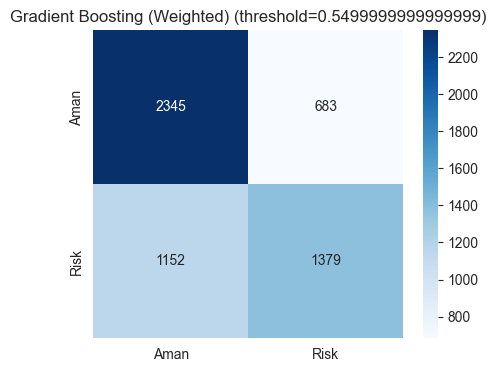

In [187]:
# FINAL CONFUSION MATRIX
'''
Membuat prediksi akhir menggunakan threshold terbaik yang telah ditemukan sebelumnya
best_prob: probabilitas prediksi dari model terbaik
best_thresh: ambang batas optimal yang memberikan F1-Macro tertinggi
.astype(int): mengubah hasil perbandingan boolean (True/False) menjadi integer (1/0)
'''
y_pred_best = (best_prob >= best_thresh).astype(int)

'''
Menghitung matriks kebingungan (confusion matrix)
Membandingkan label asli (y_test) dengan prediksi akhir (y_pred_best)
Hasilnya adalah array 2x2: [True Negative, False Positive; False Negative, True Positive]
'''
cm = confusion_matrix(y_test, y_pred_best)

# Menyiapkan figure untuk plot heatmap dengan ukuran 5x4 inci
plt.figure(figsize=(5,4))

'''
Menggambar heatmap matriks kebingungan menggunakan Seaborn
cm: data matriks
annot=True: menampilkan angka di dalam setiap kotak
fmt="d": memformat angka sebagai integer (desimal tanpa titik)
cmap="Blues": menggunakan skema warna biru untuk visualisasi yang menarik
xticklabels: label sumbu X (kolom) -> ["Aman", "Risk"]
yticklabels: label sumbu Y (baris) -> ["Aman", "Risk"]
'''
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Aman","Risk"],
            yticklabels=["Aman","Risk"])

# Menambahkan judul yang menampilkan nama model dan threshold yang digunakan
plt.title(f"{best_name} (threshold={best_thresh})")

# Menampilkan plot heatmap
plt.show()

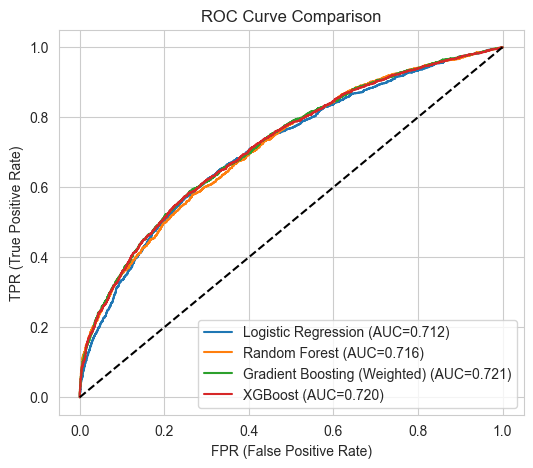

In [188]:
# KURVA ROC (ROC CURVE)
# Membuat figure baru untuk plot Kurva ROC dengan ukuran 6x5 inci
plt.figure(figsize=(6,5))

# MemLoopi setiap model dan hasil evaluasinya dari kamus 'test_results'
# name: nama model, res: dictionary hasil evaluasi model tersebut
for name, res in test_results.items():
    '''
    Menghitung False Positive Rate (FPR) dan True Positive Rate (TPR)
    y_test: label asli, res["y_prob"]: probabilitas prediksi model
    _ (underscore): menerima nilai threshold yang dihasilkan (tidak digunakan di sini)
    '''
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    
    # Menggambar garis kurva ROC untuk model tersebut
    # label: menampilkan nama model dan skor AUC-nya (dibulatkan 3 desimal) di legenda
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

'''
Menggambar garis diagonal putus-putus hitam sebagai referensi (model acak/no-skill)
Koordinat [0,1] untuk sumbu X dan Y membentuk garis dari kiri bawah ke kanan atas
Model yang baik harus berada di atas garis ini
'''
plt.plot([0,1],[0,1],"k--")

# Menampilkan legenda untuk membedakan kurva setiap model
plt.legend()

# Menambahkan judul dan label sumbu
plt.title("ROC Curve Comparison")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")

# Menambahkan grid agar pembacaan nilai lebih mudah
plt.grid(True)

# Menampilkan plot
plt.show()


=== TOP 15 FEATURE IMPORTANCE (Random Forest) ===
click_w4                                0.1324
total_clicks                            0.1143
click_w2                                0.1112
active_weeks                            0.0924
avg_clicks                              0.0780
click_w3                                0.0729
click_w1                                0.0694
highest_education_Lower_Than_A_Level    0.0588
click_growth_rate                       0.0503
click_trend                             0.0426
is_late                                 0.0411
gender_M                                0.0372
is_submitted                            0.0314
age_band_35-55                          0.0125
disability_Y                            0.0104


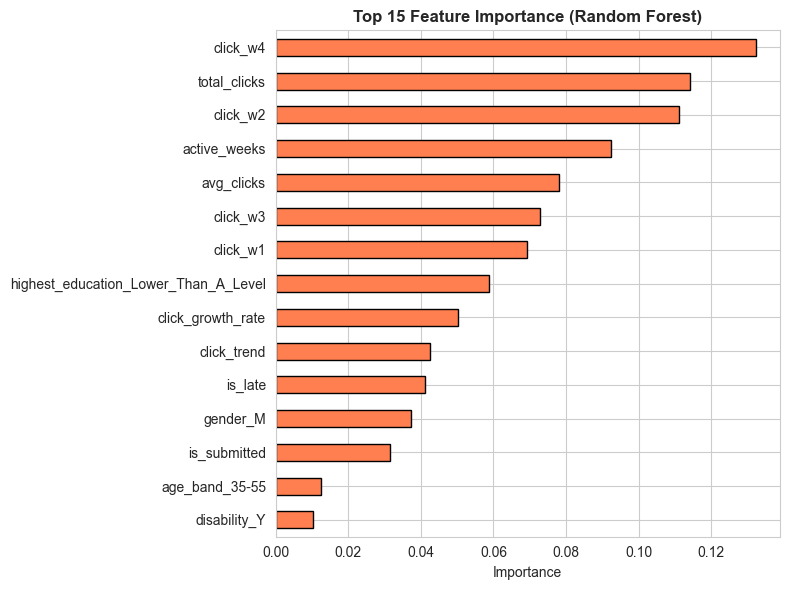

In [189]:
# TOP 15 FEATURE IMPORTANCE - RANDOM FOREST)
# Mencetak judul bagian pentingnya fitur
print("\n=== TOP 15 FEATURE IMPORTANCE (Random Forest) ===")

# Mengambil objek model Random Forest dari kamus 'models'
# Kita menggunakan Random Forest karena model ini memiliki atribut 'feature_importances_' yang mudah diakses
rf_model = models["Random Forest"]

'''
Membuat Series pandas untuk menyimpan tingkat kepentingan setiap fitur
rf_model.feature_importances_: nilai kepentingan dari model Random Forest
index=X.columns: menggunakan nama kolom fitur asli sebagai label
.sort_values(ascending=False): mengurutkan dari yang paling penting
.head(15): hanya mengambil 15 fitur teratas
'''

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

# Mencetak daftar 15 fitur teratas beserta nilainya (dibulatkan 4 desimal)
print(feat_imp.round(4).to_string())

# Membuat figure dan axis untuk plot batang horizontal
fig7, ax7 = plt.subplots(figsize=(8, 6))

'''
Menggambar diagram batang horizontal (horizontal bar plot)
kind='barh': batang horizontal
color='coral': warna batang coral
edgecolor='black': garis tepi hitam agar batas batang jelas
'''
feat_imp.plot(kind='barh', ax=ax7, color='coral', edgecolor='black')

# Mengatur judul dan label sumbu
ax7.set_title("Top 15 Feature Importance (Random Forest)", fontweight="bold")
ax7.set_xlabel("Importance")

# Membalik sumbu Y agar fitur paling penting muncul di bagian paling atas
ax7.invert_yaxis()

# Menata layout
plt.tight_layout()

# Menampilkan plot
plt.show()

In [190]:
'''
# FINAL TRAIN (FULL DATA)
# Catatan: model di-fit ulang dengan seluruh data (X, y)
# untuk memaksimalkan performa production.
# Estimasi performa tetap mengacu pada hasil CV: AUC ≈ 0.72
'''
final_model = models["XGBoost"]
final_model.fit(X, y)

# SAVE ARTIFACTS
print("Menyimpan Artifacts...\n")

# Membuat direktori jika belum ada
output_dir = "../data/processed/machineLearning"  # Direktori output
os.makedirs(output_dir, exist_ok=True)  # Membuat direktori jika belum ada

print("Menyimpan model_xgboost..")
joblib.dump(final_model, "../data/processed/machineLearning/model_xgboost.pkl")
print(f"Model        : model_xgboost.pkl")
print("Selesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/machineLearning/model_xgboost.pkl')}")

print("\nMenyimpan threshold..")
joblib.dump(best_thresh, "../data/processed/machineLearning/threshold.pkl")
print(f"Threshold    : {best_thresh}")
print("Selesai disimpan!")
print(f"Lokasi file: {os.path.abspath('../data/processed/machineLearning/threshold.pk')}")


print("\nMenyimpan feature_names..")
joblib.dump(X.columns.tolist(), "../data/processed/machineLearning/feature_names.pkl")
print(f"Num features : {len(X.columns)}")
print("Selesai disimpan!")
print(f"Lokasi file: {os.path.abspath('.../data/processed/machineLearning/feature_names.pkl')}")


Menyimpan Artifacts...

Menyimpan model_xgboost..
Model        : model_xgboost.pkl
Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\machineLearning\model_xgboost.pkl

Menyimpan threshold..
Threshold    : 0.5499999999999999
Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\data\processed\machineLearning\threshold.pk

Menyimpan feature_names..
Num features : 31
Selesai disimpan!
Lokasi file: c:\Users\melvi\Documents\CapstoneCC26-PSU030\CDC\code\...\data\processed\machineLearning\feature_names.pkl


## 4.4 Insight

Hasil pemodelan Anda sudah sangat baik dan lengkap! Berikut adalah **analisis mendalam** dan **insight bisnis** dari hasil *Machine Learning* yang telah Anda jalankan:

1. Performa Model (Evaluation Summary)
Secara keseluruhan, model memiliki performa yang **solid untuk data pendidikan** (AUC ~0.72).

*   **Pemenang:** **`Gradient Boosting (Weighted)`** menjadi juara dengan **AUC 0.7212**.
    *   Meskipun perbedaannya tipis dengan XGBoost (0.7204), Gradient Boosting berhasil sedikit unggul dalam membedakan siswa berisiko vs aman.
*   **Konsistensi:** Semua 4 model (Logistic, RF, GB, XGBoost) memberikan hasil yang sangat mirip (AUC berkisar 0.71 - 0.72). Ini menunjukkan bahwa **fitur-fitur yang Anda buat (`click_w1`-`4`, `is_late`, dll) sangat kuat dan informatif**. Tidak ada model yang "gagal" di sini.
*   **Metrik Klasifikasi:**
    *   **Recall (0.625):** Model berhasil mendeteksi sekitar **62.5%** dari total siswa yang benar-benar berisiko (Fail/Withdrawn). Sisanya (~37.5%) terlewat (False Negative).
    *   **Precision (0.626):** Dari semua siswa yang diprediksi berisiko, sekitar **62.6%** memang benar-benar berisiko.
    *   **Accuracy (0.66):** Secara umum, model benar 66% dari total prediksi.

2. Analisis Threshold Tuning (Penting untuk Bisnis)
Hasil *Threshold Tuning* memberikan wawasan krusial:
*   **Threshold Optimal: 0.55** (sedikit lebih tinggi dari default 0.5).
*   **Trade-off:**
    *   Jika kita turunkan threshold ke **0.30**, **Recall melonjak ke 0.90** (Model mendeteksi 90% siswa berisiko!).
    *   **Dampaknya:** **Precision turun drastis ke 0.51**. Artinya, kita akan "menggebar" banyak siswa yang sebenarnya aman (False Positive) untuk diberi intervensi.
*   **Rekomendasi:**
    *   Gunakan **Threshold 0.55 (Default)** jika biaya intervensi mahal (misal: konselor pribadi).
    *   Gunakan **Threshold 0.30 - 0.40** jika tujuannya **keselamatan siswa** (misal: peringatan email otomatis murah). Lebih baik salah menebak "berisiko" pada siswa aman, daripada melewatkan siswa yang akan gagal.

3. Insight Fitur Terpenting (Feature Importance)
Ini adalah bagian paling menarik dari analisis Anda. Fitur perilaku mendominasi fitur demografi:

**Top 1. Aktivitas Klik adalah Raja:**
*   `click_w4` (13.2%), `total_clicks` (11.4%), `click_w2` (11.1%) adalah fitur teratas.
*   **Insight:** Aktivitas siswa di **Minggu 4** (`click_w4`) adalah prediktor tunggal terkuat. Ini mengonfirmasi hipotesis sebelumnya: siswa yang aktivitasnya anjlok di akhir periode adalah mereka yang berisiko gagal.
*   **Trend & Growth:** `click_growth_rate` (5.0%) dan `click_trend` (4.2%) juga masuk top 10, membuktikan bahwa **pola perubahan** aktivitas lebih penting daripada sekadar jumlah total klik.

**Top 2. Keterlambatan Tugas:**
*   `is_late` (4.1%) berada di posisi penting.
*   **Insight:** Menyerahkan tugas pertama terlambat adalah sinyal bahaya dini yang valid.

**Top 3. Demografi (Pendidikan & Disabilitas):**
*   `highest_education_Lower_Than_A_Level` (5.8%) adalah fitur demografi teratas.
*   **Kejutan:** `disability_Y` hanya menduduki posisi ke-14 (1.0%).
*   **Analisis:** Meskipun secara statistik awal (di data mentah) disabilitas memiliki korelasi risiko tinggi (55%), dalam model *ensemble* (Random Forest), **perilaku aktif (`clicks`) ternyata jauh lebih prediktif daripada status disabilitas**. Model lebih "percaya" pada apa yang *dilakukan* siswa daripada *siapa* mereka. Ini sangat positif karena artinya siswa dengan disabilitas yang aktif tetap akan diprediksi aman.

4. Kesimpulan & Rekomendasi Strategis

1.  **Model Siap Deploy:** Model **Gradient Boosting** dengan threshold 0.55 sudah cukup baik untuk digunakan sebagai sistem peringatan dini.
2.  **Fokus Intervensi pada Minggu 4:** Karena `click_w4` adalah fitur terpenting, sistem monitoring harus lebih agresif memperingatkan jika aktivitas siswa turun drastis di minggu ke-4.
3.  **Intervensi Dini pada Tugas Pertama:** Siswa yang terlambat mengumpulkan tugas pertama (`is_late`) harus langsung masuk dalam daftar pemantauan.
4.  **Evaluasi Fitur Demografi:** Meskipun `disability` tidak terlalu berpengaruh di model akhir, `highest_education` (terutama yang di bawah A-Level) tetap penting. Pertimbangkan program khusus atau *bridging course* untuk siswa dengan kualifikasi pendidikan rendah di awal semester.

**Langkah Selanjutnya:**
Jika ingin meningkatkan AUC di atas 0.75, Anda bisa mencoba:
*   Menambahkan fitur interaksi (misal: `clicks` * `is_late`).
*   Mencoba *Hyperparameter Tuning* yang lebih agresif (GridSearchCV) pada `learning_rate` dan `max_depth`.
*   Menambahkan data eksternal (misal: riwayat nilai sebelumnya jika ada).

Secara keseluruhan, ini adalah hasil proyek *Machine Learning* yang sangat solid dan dapat ditindaklanjuti!

# 5. Kesimpulan

## 5.1 Data dictionary

 ### df_master_weekly_clean

| Nama Kolom | Tipe Data | Deskripsi | Nilai yang Mungkin | Bisa Kosong? |
|--------------|------------|--------------------------------------------------|------------------------|----------------|
| id_student | Integer | Identifier unik setiap siswa | - | Tidak |
| code_module | String | Kode modul/mata kuliah (misal: AAA, BBB) | - | Tidak |
| code_presentation | String | Kode semester/presentasi (misal: 2013J, 2014B) | - | Tidak |
| final_result | String | Hasil akhir siswa: Pass, Distinction, Fail, Withdrawn | - | Tidak |
| highest_education | String | Tingkat pendidikan tertinggi siswa sebelum mendaftar | - | Tidak |
| disability | String | Status disabilitas siswa: Y (Ya) atau N (Tidak) | Y / N | Tidak |
| gender | String | Jenis kelamin siswa | M / F | Tidak |
| age_band | String | Kelompok usia siswa | 0-35 / 35-55 / 55<= | Tidak |
| region | String | Wilayah asal siswa di UK | - | Tidak |
| week | Integer | Minggu ke berapa aktivitas terjadi (1–4) | 1, 2, 3, 4 | Tidak |
| total_clicks | Integer | Total klik siswa pada VLE di minggu tersebut | >= 0 | Tidak |
| days_diff | Float | Selisih hari submit vs deadline (negatif=lebih awal, positif=terlambat) | - | Ya (jika tidak ada assessment) |
| score | Float | Skor assessment pertama siswa (0–100) | 0–100 | Ya (jika tidak ada assessment) |
| is_submitted | Integer | Apakah siswa mengumpulkan tugas pertama: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_late | Integer | Apakah siswa terlambat submit: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_high_activity | Integer | Apakah total_clicks melebihi batas atas IQR: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| risk_label | Integer | Target ML: 0=Aman (Pass/Distinction), 1=Berisiko (Fail/Withdrawn) | 0 / 1 | Tidak |

### df_final

| Nama Kolom | Tipe Data | Deskripsi | Nilai yang Mungkin | Bisa Kosong? |
|--------------|------------|--------------------------------------------------|------------------------|----------------|
| id_student | Integer | Identifier unik setiap siswa | - | Tidak |
| code_module | String | Kode modul/mata kuliah | - | Tidak |
| code_presentation | String | Kode semester/presentasi | - | Tidak |
| avg_clicks | Float | Rata-rata klik per minggu selama 4 minggu pertama | >= 0 | Tidak |
| total_clicks | Integer | Total klik selama 4 minggu pertama | >= 0 | Tidak |
| active_weeks | Integer | Jumlah minggu siswa aktif berinteraksi dengan VLE | 1–4 | Tidak |
| days_diff | Float | Rata-rata selisih hari submit vs deadline | - | Ya |
| score | Float | Rata-rata skor assessment | 0–100 | Ya |
| is_submitted | Integer | Apakah siswa pernah submit tugas: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_late | Integer | Apakah siswa pernah terlambat submit: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_high_activity | Integer | Apakah siswa termasuk aktivitas tinggi: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| risk_label | Integer | Target ML: 0=Aman, 1=Berisiko | 0 / 1 | Tidak |
| final_result | String | Hasil akhir siswa: Pass, Distinction, Fail, Withdrawn | - | Tidak |
| highest_education | String | Tingkat pendidikan tertinggi | - | Tidak |
| disability | String | Status disabilitas: Y atau N | Y / N | Tidak |
| gender | String | Jenis kelamin siswa | M / F | Tidak |
| age_band | String | Kelompok usia siswa | 0-35 / 35-55 / 55<= | Tidak |
| region | String | Wilayah asal siswa di UK | - | Tidak |

### df_model

| Nama Kolom | Tipe Data | Deskripsi | Nilai yang Mungkin | Bisa Kosong? |
|--------------|------------|--------------------------------------------------|------------------------|----------------|
| id_student | Integer | Identifier unik setiap siswa (tidak dipakai model, hanya referensi) | - | Tidak |
| code_module | String | Kode modul (tidak dipakai model, hanya referensi) | - | Tidak |
| code_presentation | String | Kode semester (tidak dipakai model, hanya referensi) | - | Tidak |
| avg_clicks | Float | Rata-rata klik per minggu (fitur utama) | >= 0 | Tidak |
| total_clicks | Integer | Total klik 4 minggu pertama (fitur utama) | >= 0 | Tidak |
| active_weeks | Integer | Jumlah minggu siswa aktif berinteraksi dengan VLE | 1–4 | Tidak |
| days_diff | Float | Rata-rata selisih hari submit vs deadline | - | Ya |
| score | Float | Rata-rata skor assessment | 0–100 | Ya |
| is_submitted | Integer | Apakah siswa pernah submit tugas: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_late | Integer | Apakah siswa pernah terlambat submit: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| is_high_activity | Integer | Apakah siswa termasuk aktivitas tinggi: 1=Ya, 0=Tidak | 0 / 1 | Tidak |
| risk_label | Integer | Target MODEL: 0=Aman, 1=Berisiko | 0 / 1 | Tidak |
| click_w1 | Integer | Total klik di minggu 1 | >= 0 | Tidak |
| click_w2 | Integer | Total klik di minggu 2 | >= 0 | Tidak |
| click_w3 | Integer | Total klik di minggu 3 | >= 0 | Tidak |
| click_w4 | Integer | Total klik di minggu 4 | >= 0 | Tidak |
| click_trend | Float | Selisih klik minggu 4 vs minggu 1 (postif=meningkat) | - | Tidak |
| highest_education_ratio | Float | Rasio pertumbuhan klik minggu 1 ke 4: (w4-w1)/(w1+1) | - | Tidak |
| highest_education_HE_Qualification | Integer | Dummy: 1 jika HE Qualification, 0 lainnya | 0 / 1 | Tidak |
| highest_education_Lower_Than_A_Level | Integer | Dummy: 1 jika Lower Than A Level, 0 lainnya | 0 / 1 | Tidak |
| highest_education_No_Formal_quals | Integer | Dummy: 1 jika No Formal Quals, 0 lainnya | 0 / 1 | Tidak |
| highest_education_Post_Graduate_Qualification | Integer | Dummy: 1 jika Post Graduate, 0 lainnya | 0 / 1 | Tidak |
| gender_M | Integer | Dummy: 1 jika laki-laki, 0 jika perempuan | 0 / 1 | Tidak |
| age_band_35-55 | Integer | Dummy: 1 jika usia 35-55, 0 lainnya | 0 / 1 | Tidak |
| age_band_55<= | Integer | Dummy: 1 jika usia 55+, 0 lainnya | 0 / 1 | Tidak |
| disability_Y | Integer | Dummy: 1 jika punya disabilitas, 0 lainnya | 0 / 1 | Tidak |
| region_* | Integer | Dummy: encoding wilayah asal siswa (satu kolom per region) | 0 / 1 | Tidak |
